Ανάγνωση ετήσιων αρχείων της πυροσβεστικής (2012–2025)
Η συλλογή των δεδομένων έγινε από εδώ https://www.fireservice.gr/el/synola-dedomenon

Τα δεδομένα του Πυροσβεστικού Σώματος παρέχονται σε ξεχωριστά αρχεία Excel ανά έτος,
με ασυνεπή μορφή μεταξύ τους: διαφορετική θέση κεφαλίδας, διαφορετική ορθογραφία και τονισμός
στα ονόματα στηλών, και διαφορετικές στήλες από έτος σε έτος.

Για να αντιμετωπιστεί αυτή η ανομοιογένεια, κάθε ετήσιο αρχείο περνά από μια διαδικασία
ανθεκτικής ανάγνωσης τεσσάρων βημάτων:

1. Αυτόματος εντοπισμός κεφαλίδας: σαρώνουμε τις πρώτες 20 γραμμές και βρίσκουμε τη
σειρά που περιέχει τις λέξεις-κλειδιά «ΥΠΗΡΕΣΙΑ» και «ΝΟΜΟΣ» — αντί να υποθέσουμε σταθερή θέση.
2. Κανονικοποίηση ονομάτων στηλών: η συνάρτηση normalize_string αφαιρεί τόνους,
σημεία στίξης και κενά, ώστε στήλες με διαφορετική γραφή να αναγνωρίζονται ως ίδιες.
3. Αντιστοίχιση σε ενιαίο σχήμα master_columns ώστε κάθε αρχείο να ευθυγραμμίζεται σε ένα
κοινό σύνολο 40 στηλών· όσες λείπουν συμπληρώνονται με κενά.
4. Μετατροπή ημερομηνιών με dayfirst=True (ΗΗ/ΜΜ/ΕΕΕΕ).

ένα cell για κάθε έτος πάνω στην ίδια λογική ώστε να φτιάξουμε ένα ομοιογενονποιημένο dataset


In [1]:
import pandas as pd
import unicodedata
import os

master_columns = [
    'A/A ΕΓΓΡΑΦΗΣ', 'A/A ENGAGE', 'X-ENGAGE', 'Y-ENGAGE', 
    'Υπηρεσία', 'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 
    'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος', 
    'Περιοχή', 'Κατηγορία Συμβάντος', 'Διεύθυνση', 'Δάση', 'Δασική Έκταση', 
    'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 
    'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ', 
    'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 
    'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ', 'ΒΥΤΙΟΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ', 
    'ΕΛΙΚΟΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.',
    'ΜΙΣΘ. ΕΛΙΚΟΠΤ.', 'ΜΙΣΘ. ΑΕΡΟΣΚ.', 'ΑΛΛΩΝ ΦΟΡΕΩΝ'
]

file_name = "2025.xls"

def normalize_string(s):
    if pd.isna(s): return ""
    s = str(s).upper()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.replace('-', '').replace('/', '').replace('.', '').replace('_', '').replace('\n', '')
    return ''.join(s.split())

print(" Ψάχνω το αρχείο")
if not os.path.exists(file_name):
    print(f"ΣΦΑΛΜΑ")
else:
    print(" Το αρχείο βρέθηκε!")
    
    try:
        print(" Ψάχνω την κεφαλίδα")
        temp_df = pd.read_excel(file_name, header=None, nrows=20)
        header_idx = -1
        for idx, row in temp_df.iterrows():
            row_str = "".join([normalize_string(val) for val in row.values])
            if "ΥΠΗΡΕΣΙΑ" in row_str and "ΝΟΜΟΣ" in row_str:
                header_idx = idx
                break
                
        if header_idx == -1:
            print("ΣΦΑΛΜΑ")
        else:
            print(f"Η κεφαλίδα βρέθηκε στη γραμμή {header_idx}!")
            
            print("Διαβάζω τα δεδομένα και φτιάχνω τις στήλες")
            df = pd.read_excel(file_name, header=header_idx)
            
            target_norm = {normalize_string(col): col for col in master_columns}
            target_norm['ΟΧΗΜΟΤΑ'] = 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ' 
            
            new_columns = []
            for c in df.columns:
                norm_c = normalize_string(c)
                new_columns.append(target_norm.get(norm_c, c))
            df.columns = new_columns
            
            for col in master_columns:
                if col not in df.columns:
                    df[col] = pd.NA
                    
            print("4: Δημιουργώ το df_2025!")
            global df_2025 
            df_2025 = df[master_columns].copy()
            
            df_2025['Ημερ/νία Έναρξης'] = pd.to_datetime(df_2025['Ημερ/νία Έναρξης'], dayfirst=True, errors='coerce').dt.date
            df_2025['Ημερ/νία Κατασβεσης'] = pd.to_datetime(df_2025['Ημερ/νία Κατασβεσης'], dayfirst=True, errors='coerce').dt.date
            
            print("DONE")
            display(df_2025.head(2))
            
    except Exception as e:
        print(f"ΣΦΑΛΜΑ")

 Ψάχνω το αρχείο
 Το αρχείο βρέθηκε!
 Ψάχνω την κεφαλίδα
Η κεφαλίδα βρέθηκε στη γραμμή 3!
Διαβάζω τα δεδομένα και φτιάχνω τις στήλες
4: Δημιουργώ το df_2025!
DONE


,A/A ΕΓΓΡΑΦΗΣ,A/A ENGAGE,X-ENGAGE,Y-ENGAGE,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,Ώρα Κατάσβεσης,...,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.,ΜΙΣΘ. ΕΛΙΚΟΠΤ.,ΜΙΣΘ. ΑΕΡΟΣΚ.,ΑΛΛΩΝ ΦΟΡΕΩΝ
0,<NA>,1272497.0,23.733088,35.403909,Π.Κ. ΚΑΝΔΑΝΟΥ,ΧΑΝΙΩΝ,2025-03-12,11:23,2025-03-12,19:34,...,0,0,0,0,0,0,<NA>,0,0,0
1,<NA>,1255158.0,25.373726,41.004333,Π.Υ. ΚΟΜΟΤΗΝΗΣ,ΡΟΔΟΠΗΣ,2025-01-05,15:43,2025-01-05,15:56,...,0,0,0,0,0,0,<NA>,0,0,0


In [2]:
import pandas as pd
import unicodedata


master_columns = [
    'A/A ΕΓΓΡΑΦΗΣ', 'A/A ENGAGE', 'X-ENGAGE', 'Y-ENGAGE', 
    'Υπηρεσία', 'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 
    'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος', 
    'Περιοχή', 'Κατηγορία Συμβάντος', 'Διεύθυνση', 'Δάση', 'Δασική Έκταση', 
    'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 
    'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ', 
    'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 
    'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ', 'ΒΥΤΙΟΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ', 
    'ΕΛΙΚΟΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.',
    'ΜΙΣΘ. ΕΛΙΚΟΠΤ.', 'ΜΙΣΘ. ΑΕΡΟΣΚ.', 'ΑΛΛΩΝ ΦΟΡΕΩΝ'
]

file_name = "2024.xls" 

def normalize_string(s):
    if pd.isna(s): return ""
    s = str(s).upper()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.replace('-', '').replace('/', '').replace('.', '').replace('_', '').replace('\n', '')
    return ''.join(s.split())

print(f"Διαβάζω το: {file_name} ...")

try:
    temp_df = pd.read_excel(file_name, header=None, nrows=20)
    header_idx = -1
    for idx, row in temp_df.iterrows():
        row_str = "".join([normalize_string(val) for val in row.values])
        if "ΥΠΗΡΕΣΙΑ" in row_str and "ΔΑΣΗ" in row_str:
            header_idx = idx
            break
            
    if header_idx == -1:
        print("Δεν βρέθηκε σωστή κεφαλίδα στο αρχείο.")
    else:
        df = pd.read_excel(file_name, header=header_idx)
        
        target_norm = {normalize_string(col): col for col in master_columns}
        target_norm['ΗΜΕΡΝΙΑΕΝΑΡΞΗΣ'] = 'Ημερ/νία Έναρξης'
        target_norm['ΣΚΟΥΠΙΔΟΤΟΠΟΙ'] = 'Σκουπιδότοποι' 
        
        new_columns = []
        for c in df.columns:
            norm_c = normalize_string(c)
            if norm_c in target_norm:
                new_columns.append(target_norm[norm_c])
            else:
                new_columns.append(c)
                
        df.columns = new_columns
        
        for col in master_columns:
            if col not in df.columns:
                df[col] = pd.NA
                
        df_2024 = df[master_columns]
        
        
        df_2024['Ημερ/νία Έναρξης'] = pd.to_datetime(df_2024['Ημερ/νία Έναρξης'], errors='coerce').dt.date
        df_2024['Ημερ/νία Κατασβεσης'] = pd.to_datetime(df_2024['Ημερ/νία Κατασβεσης'], errors='coerce').dt.date
        
        print(" Το 00:00:00 αφαιρέθηκε.")
        display(df_2024.head())
        
except Exception as e:
    print(f" Σφάλμα: {e}")

Διαβάζω το: 2024.xls ...
 Το 00:00:00 αφαιρέθηκε.


,A/A ΕΓΓΡΑΦΗΣ,A/A ENGAGE,X-ENGAGE,Y-ENGAGE,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,Ώρα Κατάσβεσης,...,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.,ΜΙΣΘ. ΕΛΙΚΟΠΤ.,ΜΙΣΘ. ΑΕΡΟΣΚ.,ΑΛΛΩΝ ΦΟΡΕΩΝ
0,<NA>,<NA>,23.904632,38.182833,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2024-05-07,10:57,2024-05-07,13:54,...,0,0,0,0,0,0,0,0.0,0.0,<NA>
1,<NA>,<NA>,23.838728,38.155055,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2024-06-05,11:15,NaT,NaN,...,3,0,0,2,0,0,0,2.0,0.0,<NA>
2,<NA>,<NA>,23.835675,38.171803,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2024-06-26,12:58,2024-06-26,13:58,...,0,0,0,0,0,0,0,0.0,0.0,<NA>
3,<NA>,<NA>,23.792774,38.182886,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2024-06-29,14:50,NaT,NaN,...,0,0,0,0,0,0,0,4.0,0.0,<NA>
4,<NA>,<NA>,23.891138,38.279783,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2024-11-24,11:36,2024-11-24,18:00,...,0,0,0,0,0,0,0,0.0,0.0,<NA>


In [3]:
import pandas as pd
import unicodedata

master_columns = [
    'A/A ΕΓΓΡΑΦΗΣ', 'A/A ENGAGE', 'X-ENGAGE', 'Y-ENGAGE', 
    'Υπηρεσία', 'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 
    'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος', 
    'Περιοχή', 'Κατηγορία Συμβάντος', 'Διεύθυνση', 'Δάση', 'Δασική Έκταση', 
    'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 
    'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ', 
    'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 
    'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ', 'ΒΥΤΙΟΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ', 
    'ΕΛΙΚΟΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.',
    'ΜΙΣΘ. ΕΛΙΚΟΠΤ.', 'ΜΙΣΘ. ΑΕΡΟΣΚ.', 'ΑΛΛΩΝ ΦΟΡΕΩΝ'
]

file_name = "2023.xls" 

def normalize_string(s):
    if pd.isna(s): return ""
    s = str(s).upper()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.replace('-', '').replace('/', '').replace('.', '').replace('_', '').replace('\n', '')
    return ''.join(s.split()) 

print(f"Διαβάζω το: {file_name} ...")

try:
    temp_df = pd.read_excel(file_name, header=None, nrows=20)
    header_idx = -1
    for idx, row in temp_df.iterrows():
        row_str = "".join([normalize_string(val) for val in row.values])
        if "ΥΠΗΡΕΣΙΑ" in row_str and "ΔΑΣΗ" in row_str:
            header_idx = idx
            break
            
    if header_idx == -1:
        print("Δεν βρέθηκε σωστή κεφαλίδα στο αρχείο.")
    else:
        df = pd.read_excel(file_name, header=header_idx)
        
        target_norm = {normalize_string(col): col for col in master_columns}
        target_norm['ΗΜΕΡΝΙΑΕΝΑΡΞΗΣ'] = 'Ημερ/νία Έναρξης'
        target_norm['ΣΚΟΥΠΙΔΟΤΟΠΟΙ'] = 'Σκουπιδότοποι' 
        
        new_columns = []
        for c in df.columns:
            norm_c = normalize_string(c)
            if norm_c in target_norm:
                new_columns.append(target_norm[norm_c])
            else:
                new_columns.append(c)
                
        df.columns = new_columns
        
        for col in master_columns:
            if col not in df.columns:
                df[col] = pd.NA
                
        df_2023 = df[master_columns]
        
        # Καθαρισμός των ημερομηνιών από τα 00:00:00
        df_2023['Ημερ/νία Έναρξης'] = pd.to_datetime(df_2023['Ημερ/νία Έναρξης'], errors='coerce').dt.date
        df_2023['Ημερ/νία Κατασβεσης'] = pd.to_datetime(df_2023['Ημερ/νία Κατασβεσης'], errors='coerce').dt.date
        
        print("DONE")
        display(df_2023.head())
        
except Exception as e:
    print(f" Σφάλμα: {e}")

Διαβάζω το: 2023.xls ...
DONE


,A/A ΕΓΓΡΑΦΗΣ,A/A ENGAGE,X-ENGAGE,Y-ENGAGE,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,Ώρα Κατάσβεσης,...,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.,ΜΙΣΘ. ΕΛΙΚΟΠΤ.,ΜΙΣΘ. ΑΕΡΟΣΚ.,ΑΛΛΩΝ ΦΟΡΕΩΝ
0,<NA>,<NA>,23.842231,38.306454,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2023-03-14,16:28,2023-03-14,17:00,...,1,0,0,0,0,0,0,0.0,0.0,<NA>
1,<NA>,<NA>,23.832525,38.253734,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2023-07-06,13:43,2023-07-12,18:00,...,5,0,0,0,0,0,0,0.0,0.0,<NA>
2,<NA>,<NA>,0.000000,0.000000,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2023-11-05,09:38,2023-11-05,11:45,...,0,0,0,0,0,0,0,0.0,0.0,<NA>
3,<NA>,<NA>,23.629634,38.013060,2ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2023-07-18,15:12,NaT,NaN,...,2,0,3,0,0,0,0,0.0,0.0,<NA>
4,<NA>,<NA>,23.753637,38.070740,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2023-07-11,22:56,2023-07-12,02:40,...,0,0,0,0,0,0,0,0.0,0.0,<NA>


In [4]:
import pandas as pd
import unicodedata

master_columns = [
    'A/A ΕΓΓΡΑΦΗΣ', 'A/A ENGAGE', 'X-ENGAGE', 'Y-ENGAGE', 
    'Υπηρεσία', 'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 
    'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος', 
    'Περιοχή', 'Κατηγορία Συμβάντος', 'Διεύθυνση', 'Δάση', 'Δασική Έκταση', 
    'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 
    'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ', 
    'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 
    'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ', 'ΒΥΤΙΟΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ', 
    'ΕΛΙΚΟΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.',
    'ΜΙΣΘ. ΕΛΙΚΟΠΤ.', 'ΜΙΣΘ. ΑΕΡΟΣΚ.', 'ΑΛΛΩΝ ΦΟΡΕΩΝ'
]


file_name = "2022.xls" 


def normalize_string(s):
    if pd.isna(s): return ""
    s = str(s).upper()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.replace('-', '').replace('/', '').replace('.', '').replace('_', '').replace('\n', '')
    return ''.join(s.split()) 

print(f"Διαβάζω το: {file_name} ...")

try:
    temp_df = pd.read_excel(file_name, header=None, nrows=20)
    header_idx = -1
    for idx, row in temp_df.iterrows():
        row_str = "".join([normalize_string(val) for val in row.values])
        if "ΥΠΗΡΕΣΙΑ" in row_str and "ΔΑΣΗ" in row_str:
            header_idx = idx
            break
            
    if header_idx == -1:
        print("Δεν βρέθηκε σωστή κεφαλίδα στο αρχείο.")
    else:
        df = pd.read_excel(file_name, header=header_idx)
        
        target_norm = {normalize_string(col): col for col in master_columns}
        target_norm['ΗΜΕΡΝΙΑΕΝΑΡΞΗΣ'] = 'Ημερ/νία Έναρξης'
        target_norm['ΣΚΟΥΠΙΔΟΤΟΠΟΙ'] = 'Σκουπιδότοποι' 
        
        new_columns = []
        for c in df.columns:
            norm_c = normalize_string(c)
            if norm_c in target_norm:
                new_columns.append(target_norm[norm_c])
            else:
                new_columns.append(c)
                
        df.columns = new_columns
        
        for col in master_columns:
            if col not in df.columns:
                df[col] = pd.NA
                
        df_2022 = df[master_columns]
        
        # Καθαρισμός των ημερομηνιών από τα 00:00:00
        df_2022['Ημερ/νία Έναρξης'] = pd.to_datetime(df_2022['Ημερ/νία Έναρξης'], errors='coerce').dt.date
        df_2022['Ημερ/νία Κατασβεσης'] = pd.to_datetime(df_2022['Ημερ/νία Κατασβεσης'], errors='coerce').dt.date
        
        print("DONE")
        display(df_2022.head())
        
except Exception as e:
    print(f"Σφάλμα: {e}")

Διαβάζω το: 2022.xls ...
DONE


,A/A ΕΓΓΡΑΦΗΣ,A/A ENGAGE,X-ENGAGE,Y-ENGAGE,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,Ώρα Κατάσβεσης,...,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.,ΜΙΣΘ. ΕΛΙΚΟΠΤ.,ΜΙΣΘ. ΑΕΡΟΣΚ.,ΑΛΛΩΝ ΦΟΡΕΩΝ
0,<NA>,<NA>,23.917434,38.281027,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2022-06-14,13:24,2022-06-16,20:59,...,2,1,0,0,0,0,0,2.0,0.0,<NA>
1,<NA>,<NA>,23.879325,38.192702,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2022-11-02,15:25,2022-11-04,18:30,...,0,0,0,0,0,0,0,0.0,0.0,<NA>
2,<NA>,<NA>,23.649008,38.004024,2ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2022-07-26,15:27,2022-07-28,16:20,...,2,0,3,0,2,0,0,0.0,0.0,<NA>
3,<NA>,<NA>,0,0,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2022-02-10,15:23,2022-02-10,19:28,...,0,0,0,0,0,0,0,0.0,0.0,<NA>
4,<NA>,<NA>,23.721136,38.121533,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2022-02-11,15:08,2022-02-11,16:29,...,0,0,0,0,0,0,0,0.0,0.0,<NA>


In [5]:

import pandas as pd
import unicodedata
import os


master_columns = [
    'A/A ΕΓΓΡΑΦΗΣ', 'A/A ENGAGE', 'X-ENGAGE', 'Y-ENGAGE', 
    'Υπηρεσία', 'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 
    'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος', 
    'Περιοχή', 'Κατηγορία Συμβάντος', 'Διεύθυνση', 'Δάση', 'Δασική Έκταση', 
    'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 
    'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ', 
    'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 
    'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ', 'ΒΥΤΙΟΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ', 
    'ΕΛΙΚΟΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.',
    'ΜΙΣΘ. ΕΛΙΚΟΠΤ.', 'ΜΙΣΘ. ΑΕΡΟΣΚ.', 'ΑΛΛΩΝ ΦΟΡΕΩΝ'
]


file_name = "2021.xls" 


def normalize_string(s):
    if pd.isna(s): return ""
    s = str(s).upper()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.replace('-', '').replace('/', '').replace('.', '').replace('_', '').replace('\n', '')
    return ''.join(s.split()) 

print(f"Διαβάζω το: {file_name} ...")


if not os.path.exists(file_name):
    print(f" Το αρχείο {file_name} δεν βρέθηκε.")
else:
    try:
        temp_df = pd.read_excel(file_name, header=None, nrows=20)
        
        header_idx = -1
        
        for idx, row in temp_df.iterrows():
            row_str = "".join([normalize_string(val) for val in row.values])
            
            if "ΥΠΗΡΕΣΙΑ" in row_str and "ΔΑΣΗ" in row_str:
                header_idx = idx # Κρατάμε τον αριθμό της γραμμής
                break # Σταματάμε το ψάξιμο
                
        if header_idx != -1:
            
            df = pd.read_excel(file_name, header=header_idx)
            
            target_norm = {normalize_string(col): col for col in master_columns}
            
            target_norm['ΗΜΕΡΝΙΑΕΝΑΡΞΗΣ'] = 'Ημερ/νία Έναρξης'
            target_norm['ΣΚΟΥΠΙΔΟΤΟΠΟΙ'] = 'Σκουπιδότοποι' 
            
            target_norm['ΟΧΗΜΟΤΑ'] = 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ' 
            
            new_columns = []
            
            for c in df.columns:
                norm_c = normalize_string(c)
                if norm_c in target_norm:
                    new_columns.append(target_norm[norm_c])
                else:
                    new_columns.append(c) 
                    
            df.columns = new_columns
            
            for col in master_columns:
                if col not in df.columns:
                    df[col] = pd.NA
                    
            df_2021 = df[master_columns].copy()
            
            df_2021['Ημερ/νία Έναρξης'] = pd.to_datetime(df_2021['Ημερ/νία Έναρξης'], errors='coerce').dt.date
            df_2021['Ημερ/νία Κατασβεσης'] = pd.to_datetime(df_2021['Ημερ/νία Κατασβεσης'], errors='coerce').dt.date
            
            print("DONE")
            
            display(df_2021.head())
            
        else:
            print("Δεν βρέθηκε σωστή κεφαλίδα στο αρχείο.")
            
    except Exception as e:
        print(f"Σφάλμα κατά την επεξεργασία: {e}")

Διαβάζω το: 2021.xls ...
DONE


,A/A ΕΓΓΡΑΦΗΣ,A/A ENGAGE,X-ENGAGE,Y-ENGAGE,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,Ώρα Κατάσβεσης,...,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.,ΜΙΣΘ. ΕΛΙΚΟΠΤ.,ΜΙΣΘ. ΑΕΡΟΣΚ.,ΑΛΛΩΝ ΦΟΡΕΩΝ
0,<NA>,<NA>,23.847244,38.27719,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2021-03-06,14:31,2021-03-08,17:22,...,1,1,1,0,1,0,0,NaN,NaN,<NA>
1,<NA>,<NA>,NaN,NaN,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2021-03-22,15:51,2021-03-22,18:15,...,0,0,0,0,0,0,0,NaN,NaN,<NA>
2,<NA>,<NA>,NaN,NaN,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2021-04-02,14:47,2021-04-02,18:50,...,0,0,0,0,0,0,0,NaN,NaN,<NA>
3,<NA>,<NA>,NaN,NaN,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2021-04-08,14:29,NaT,NaN,...,0,0,0,0,0,0,0,NaN,NaN,<NA>
4,<NA>,<NA>,NaN,NaN,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2021-06-07,16:39,2021-06-07,18:00,...,0,0,0,0,0,0,0,NaN,NaN,<NA>


In [6]:

import pandas as pd
import unicodedata
import os


master_columns = [
    'A/A ΕΓΓΡΑΦΗΣ', 'A/A ENGAGE', 'X-ENGAGE', 'Y-ENGAGE', 
    'Υπηρεσία', 'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 
    'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος', 
    'Περιοχή', 'Κατηγορία Συμβάντος', 'Διεύθυνση', 'Δάση', 'Δασική Έκταση', 
    'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 
    'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ', 
    'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 
    'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ', 'ΒΥΤΙΟΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ', 
    'ΕΛΙΚΟΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.',
    'ΜΙΣΘ. ΕΛΙΚΟΠΤ.', 'ΜΙΣΘ. ΑΕΡΟΣΚ.', 'ΑΛΛΩΝ ΦΟΡΕΩΝ'
]

file_name = "2020.xls" 


def normalize_string(s):
    
    if pd.isna(s): return ""
    s = str(s).upper() 
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.replace('-', '').replace('/', '').replace('.', '').replace('_', '').replace('\n', '')
    return ''.join(s.split()) 

print(f"Διαβάζω το: {file_name} ...")

if not os.path.exists(file_name):
    print(f" Το αρχείο {file_name} δεν βρέθηκε.")
else:
    try:
        
        temp_df = pd.read_excel(file_name, header=None, nrows=20)
        
        
        header_idx = -1
        
        
        for idx, row in temp_df.iterrows():
            row_str = "".join([normalize_string(val) for val in row.values])
            
            
            if "ΥΠΗΡΕΣΙΑ" in row_str and "ΔΑΣΗ" in row_str:
                header_idx = idx 
                break 
                
        if header_idx != -1:
            
            
            df = pd.read_excel(file_name, header=header_idx)
            
           
            target_norm = {normalize_string(col): col for col in master_columns}
            target_norm['ΗΜΕΡΝΙΑΕΝΑΡΞΗΣ'] = 'Ημερ/νία Έναρξης'
            target_norm['ΣΚΟΥΠΙΔΟΤΟΠΟΙ'] = 'Σκουπιδότοποι' 
            
            
            target_norm['ΟΧΗΜΟΤΑ'] = 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ' 
            
            
            new_columns = []
            
            for c in df.columns:
                norm_c = normalize_string(c)
                if norm_c in target_norm:
                    new_columns.append(target_norm[norm_c])
                else:
                    new_columns.append(c) 
                    
            df.columns = new_columns
            
            for col in master_columns:
                if col not in df.columns:
                    df[col] = pd.NA
                    
            df_2020 = df[master_columns].copy()
            
            df_2020['Ημερ/νία Έναρξης'] = pd.to_datetime(df_2020['Ημερ/νία Έναρξης'], errors='coerce').dt.date
            df_2020['Ημερ/νία Κατασβεσης'] = pd.to_datetime(df_2020['Ημερ/νία Κατασβεσης'], errors='coerce').dt.date
            
            print("DONE")
            
            display(df_2020.head())
            
        else:
            print("Δεν βρέθηκε σωστή κεφαλίδα στο αρχείο.")
            
    except Exception as e:
        print(f"Σφάλμα κατά την επεξεργασία: {e}")

Διαβάζω το: 2020.xls ...
DONE


,A/A ΕΓΓΡΑΦΗΣ,A/A ENGAGE,X-ENGAGE,Y-ENGAGE,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,Ώρα Κατάσβεσης,...,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.,ΜΙΣΘ. ΕΛΙΚΟΠΤ.,ΜΙΣΘ. ΑΕΡΟΣΚ.,ΑΛΛΩΝ ΦΟΡΕΩΝ
0,<NA>,<NA>,0.0,0.0,Π.Υ. ΒΙ.ΠΕ. ΚΟΜΟΤΗΝΗΣ,ΡΟΔΟΠΗΣ,2020-01-01,14:33,2020-01-01,15:15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,<NA>,<NA>
1,<NA>,<NA>,0.0,0.0,Π.Υ. ΑΛΕΞΑΝΔΡΟΥΠΟΛΗΣ,ΕΒΡΟΥ,2020-01-01,17:10,NaT,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,<NA>,<NA>
2,<NA>,<NA>,0.0,0.0,1ος Π.Σ. ΙΩΑΝΝΙΝΩΝ,ΙΩΑΝΝΙΝΩΝ,2020-01-01,17:25,2020-01-01,17:25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,<NA>,<NA>
3,<NA>,<NA>,0.0,0.0,1ος Π.Σ. ΙΩΑΝΝΙΝΩΝ,ΙΩΑΝΝΙΝΩΝ,2020-01-01,17:45,2020-01-01,19:30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,<NA>,<NA>
4,<NA>,<NA>,0.0,0.0,Π.Υ. ΑΙΓΙΟΥ,ΑΧΑΙΑΣ,2020-01-01,13:12,NaT,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,<NA>,<NA>


In [7]:
import pandas as pd
import unicodedata
import os

master_columns = [
    'A/A ΕΓΓΡΑΦΗΣ', 'A/A ENGAGE', 'X-ENGAGE', 'Y-ENGAGE', 
    'Υπηρεσία', 'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 
    'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος', 
    'Περιοχή', 'Κατηγορία Συμβάντος', 'Διεύθυνση', 'Δάση', 'Δασική Έκταση', 
    'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 
    'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ', 
    'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 
    'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ', 'ΒΥΤΙΟΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ', 
    'ΕΛΙΚΟΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.',
    'ΜΙΣΘ. ΕΛΙΚΟΠΤ.', 'ΜΙΣΘ. ΑΕΡΟΣΚ.', 'ΑΛΛΩΝ ΦΟΡΕΩΝ'
]

file_name = "2019.xls" 
def normalize_string(s):
    if pd.isna(s): return ""
    s = str(s).upper()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.replace('-', '').replace('/', '').replace('.', '').replace('_', '').replace('\n', '')
    return ''.join(s.split()) 

print(f"Διαβάζω το: {file_name} ...")

if not os.path.exists(file_name):
    print(f" Το αρχείο {file_name} δεν βρέθηκε.")
else:
    try:
        temp_df = pd.read_excel(file_name, header=None, nrows=20)
        
        header_idx = -1
        
        for idx, row in temp_df.iterrows():
            row_str = "".join([normalize_string(val) for val in row.values])
            
            if "ΥΠΗΡΕΣΙΑ" in row_str and "ΔΑΣΗ" in row_str:
                header_idx = idx 
                break 
                
        if header_idx != -1:
            
            df = pd.read_excel(file_name, header=header_idx)
            
            target_norm = {normalize_string(col): col for col in master_columns}
            
            target_norm['ΗΜΕΡΝΙΑΕΝΑΡΞΗΣ'] = 'Ημερ/νία Έναρξης'
            target_norm['ΣΚΟΥΠΙΔΟΤΟΠΟΙ'] = 'Σκουπιδότοποι' 
            
            target_norm['ΟΧΗΜΟΤΑ'] = 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ' 
            
            new_columns = []
            
            for c in df.columns:
                norm_c = normalize_string(c)
                if norm_c in target_norm:
                    new_columns.append(target_norm[norm_c])
                else:
                    new_columns.append(c) 
                    
            df.columns = new_columns
            
            for col in master_columns:
                if col not in df.columns:
                    df[col] = pd.NA
                    
            df_2019 = df[master_columns].copy()
            
            df_2019['Ημερ/νία Έναρξης'] = pd.to_datetime(df_2019['Ημερ/νία Έναρξης'], errors='coerce').dt.date
            df_2019['Ημερ/νία Κατασβεσης'] = pd.to_datetime(df_2019['Ημερ/νία Κατασβεσης'], errors='coerce').dt.date
            
            print("DONE")
            
            display(df_2019.head())
            
        else:
            print("Δεν βρέθηκε σωστή κεφαλίδα στο αρχείο.")
            
    except Exception as e:
        print(f"Σφάλμα κατά την επεξεργασία: {e}")

Διαβάζω το: 2019.xls ...
DONE


,A/A ΕΓΓΡΑΦΗΣ,A/A ENGAGE,X-ENGAGE,Y-ENGAGE,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,Ώρα Κατάσβεσης,...,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.,ΜΙΣΘ. ΕΛΙΚΟΠΤ.,ΜΙΣΘ. ΑΕΡΟΣΚ.,ΑΛΛΩΝ ΦΟΡΕΩΝ
0,<NA>,<NA>,<NA>,<NA>,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2019-04-22,13:00,2019-04-22,20:00,...,0,1,0,0,0,0,0,<NA>,<NA>,<NA>
1,<NA>,<NA>,<NA>,<NA>,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2019-06-02,21:00,2019-06-03,00:15,...,1,0,0,0,0,0,0,<NA>,<NA>,<NA>
2,<NA>,<NA>,<NA>,<NA>,1ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2019-09-08,02:42,NaT,NaN,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>
3,<NA>,<NA>,<NA>,<NA>,4ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2019-06-12,11:19,NaT,NaN,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>
4,<NA>,<NA>,<NA>,<NA>,4ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2019-10-03,16:29,NaT,NaN,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>


In [8]:
import pandas as pd
import unicodedata
import os

master_columns = [
    'A/A ΕΓΓΡΑΦΗΣ', 'A/A ENGAGE', 'X-ENGAGE', 'Y-ENGAGE', 
    'Υπηρεσία', 'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 
    'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος', 
    'Περιοχή', 'Κατηγορία Συμβάντος', 'Διεύθυνση', 'Δάση', 'Δασική Έκταση', 
    'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 
    'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ', 
    'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 
    'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ', 'ΒΥΤΙΟΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ', 
    'ΕΛΙΚΟΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.',
    'ΜΙΣΘ. ΕΛΙΚΟΠΤ.', 'ΜΙΣΘ. ΑΕΡΟΣΚ.', 'ΑΛΛΩΝ ΦΟΡΕΩΝ'
]

file_name = "2018.xls" 

def normalize_string(s):
    if pd.isna(s): return ""
    s = str(s).upper()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.replace('-', '').replace('/', '').replace('.', '').replace('_', '').replace('\n', '')
    return ''.join(s.split()) 

print(f"Διαβάζω το: {file_name} ...")

if not os.path.exists(file_name):
    print(f" Το αρχείο {file_name} δεν βρέθηκε.")
else:
    try:
        temp_df = pd.read_excel(file_name, header=None, nrows=20)
        
        header_idx = -1
        
        for idx, row in temp_df.iterrows():
            row_str = "".join([normalize_string(val) for val in row.values])
            
            if "ΥΠΗΡΕΣΙΑ" in row_str and "ΔΑΣΗ" in row_str:
                header_idx = idx 
                break 
                
        if header_idx != -1:
            
            df = pd.read_excel(file_name, header=header_idx)
            
            target_norm = {normalize_string(col): col for col in master_columns}
            
            target_norm['ΗΜΕΡΝΙΑΕΝΑΡΞΗΣ'] = 'Ημερ/νία Έναρξης'
            target_norm['ΣΚΟΥΠΙΔΟΤΟΠΟΙ'] = 'Σκουπιδότοποι' 
            
            target_norm['ΟΧΗΜΟΤΑ'] = 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ' 
        
            new_columns = []
            
            for c in df.columns:
                norm_c = normalize_string(c)
                if norm_c in target_norm:
                    new_columns.append(target_norm[norm_c])
                else:
                    new_columns.append(c) 
                    
            df.columns = new_columns
            
            
            for col in master_columns:
                if col not in df.columns:
                    df[col] = pd.NA
                    
            df_2018 = df[master_columns].copy()
            
            df_2018['Ημερ/νία Έναρξης'] = pd.to_datetime(df_2018['Ημερ/νία Έναρξης'], errors='coerce').dt.date
            df_2018['Ημερ/νία Κατασβεσης'] = pd.to_datetime(df_2018['Ημερ/νία Κατασβεσης'], errors='coerce').dt.date
            
            print("DONE")
            
            display(df_2018.head())
            
        else:
            print("Δεν βρέθηκε σωστή κεφαλίδα στο αρχείο.")
            
    except Exception as e:
        print(f"Σφάλμα κατά την επεξεργασία: {e}")

Διαβάζω το: 2018.xls ...
DONE


,A/A ΕΓΓΡΑΦΗΣ,A/A ENGAGE,X-ENGAGE,Y-ENGAGE,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,Ώρα Κατάσβεσης,...,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.,ΜΙΣΘ. ΕΛΙΚΟΠΤ.,ΜΙΣΘ. ΑΕΡΟΣΚ.,ΑΛΛΩΝ ΦΟΡΕΩΝ
0,<NA>,<NA>,<NA>,<NA>,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2018-05-29,12:06,2018-05-29,18:30,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>
1,<NA>,<NA>,<NA>,<NA>,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2018-07-23,19:00,2018-07-31,10:18,...,2,0,0,1,0,0,0,<NA>,<NA>,<NA>
2,<NA>,<NA>,<NA>,<NA>,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2018-08-26,15:30,2018-08-27,07:55,...,0,0,0,1,0,0,0,<NA>,<NA>,<NA>
3,<NA>,<NA>,<NA>,<NA>,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2018-11-07,20:10,2018-11-08,21:10,...,1,2,0,0,0,0,0,<NA>,<NA>,<NA>
4,<NA>,<NA>,<NA>,<NA>,1ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2018-05-23,17:36,2018-05-23,18:10,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>


In [9]:
import pandas as pd
import unicodedata
import os

master_columns = [
    'A/A ΕΓΓΡΑΦΗΣ', 'A/A ENGAGE', 'X-ENGAGE', 'Y-ENGAGE', 
    'Υπηρεσία', 'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 
    'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος', 
    'Περιοχή', 'Κατηγορία Συμβάντος', 'Διεύθυνση', 'Δάση', 'Δασική Έκταση', 
    'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 
    'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ', 
    'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 
    'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ', 'ΒΥΤΙΟΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ', 
    'ΕΛΙΚΟΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.',
    'ΜΙΣΘ. ΕΛΙΚΟΠΤ.', 'ΜΙΣΘ. ΑΕΡΟΣΚ.', 'ΑΛΛΩΝ ΦΟΡΕΩΝ'
]

file_name = "2017.xls" 

def normalize_string(s):
    if pd.isna(s): return ""
    s = str(s).upper()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.replace('-', '').replace('/', '').replace('.', '').replace('_', '').replace('\n', '')
    return ''.join(s.split()) 

print(f"Διαβάζω το: {file_name} ...")

if not os.path.exists(file_name):
    print(f" Το αρχείο {file_name} δεν βρέθηκε.")
else:
    try:
        temp_df = pd.read_excel(file_name, header=None, nrows=20)
        
        header_idx = -1
        
        for idx, row in temp_df.iterrows():
            row_str = "".join([normalize_string(val) for val in row.values])
            
            if "ΥΠΗΡΕΣΙΑ" in row_str and "ΔΑΣΗ" in row_str:
                header_idx = idx 
                break 
                
        if header_idx != -1:
            
            df = pd.read_excel(file_name, header=header_idx)
            
            target_norm = {normalize_string(col): col for col in master_columns}
            
            target_norm['ΗΜΕΡΝΙΑΕΝΑΡΞΗΣ'] = 'Ημερ/νία Έναρξης'
            target_norm['ΣΚΟΥΠΙΔΟΤΟΠΟΙ'] = 'Σκουπιδότοποι' 
            
            target_norm['ΟΧΗΜΟΤΑ'] = 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ' 
            
            new_columns = []
            
            for c in df.columns:
                norm_c = normalize_string(c)
                if norm_c in target_norm:
                    new_columns.append(target_norm[norm_c])
                else:
                    new_columns.append(c) 
                    
            df.columns = new_columns
            
            for col in master_columns:
                if col not in df.columns:
                    df[col] = pd.NA
                    
            df_2017 = df[master_columns].copy()
            
            df_2017['Ημερ/νία Έναρξης'] = pd.to_datetime(df_2017['Ημερ/νία Έναρξης'], errors='coerce').dt.date
            df_2017['Ημερ/νία Κατασβεσης'] = pd.to_datetime(df_2017['Ημερ/νία Κατασβεσης'], errors='coerce').dt.date
            
            print("DONE")
            
            display(df_2017.head())
            
        else:
            print("Δεν βρέθηκε σωστή κεφαλίδα στο αρχείο.")
            
    except Exception as e:
        print(f"Σφάλμα κατά την επεξεργασία: {e}")

Διαβάζω το: 2017.xls ...
DONE


,A/A ΕΓΓΡΑΦΗΣ,A/A ENGAGE,X-ENGAGE,Y-ENGAGE,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,Ώρα Κατάσβεσης,...,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.,ΜΙΣΘ. ΕΛΙΚΟΠΤ.,ΜΙΣΘ. ΑΕΡΟΣΚ.,ΑΛΛΩΝ ΦΟΡΕΩΝ
0,<NA>,<NA>,<NA>,<NA>,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2017-04-09,12:44,2017-04-09,16:31,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,<NA>,<NA>
1,<NA>,<NA>,<NA>,<NA>,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2017-07-05,17:16,2017-07-08,08:05,...,3.0,0.0,1.0,0.0,2.0,0.0,0.0,<NA>,<NA>,<NA>
2,<NA>,<NA>,<NA>,<NA>,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2017-08-13,16:16,2017-09-11,20:00,...,40.0,11.0,9.0,2.0,3.0,0.0,0.0,<NA>,<NA>,<NA>
3,<NA>,<NA>,<NA>,<NA>,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2017-10-24,05:17,2017-10-24,08:06,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,<NA>,<NA>
4,<NA>,<NA>,<NA>,<NA>,Π.Κ. ΚΑΛΑΜΟΥ,ΑΤΤΙΚΗΣ,2017-10-24,08:23,2017-10-24,19:30,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,<NA>,<NA>,<NA>


In [10]:
import pandas as pd
import unicodedata
import os

master_columns = [
    'A/A ΕΓΓΡΑΦΗΣ', 'A/A ENGAGE', 'X-ENGAGE', 'Y-ENGAGE', 
    'Υπηρεσία', 'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 
    'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος', 
    'Περιοχή', 'Κατηγορία Συμβάντος', 'Διεύθυνση', 'Δάση', 'Δασική Έκταση', 
    'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 
    'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ', 
    'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 
    'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ', 'ΒΥΤΙΟΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ', 
    'ΕΛΙΚΟΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.',
    'ΜΙΣΘ. ΕΛΙΚΟΠΤ.', 'ΜΙΣΘ. ΑΕΡΟΣΚ.', 'ΑΛΛΩΝ ΦΟΡΕΩΝ'
]

file_name = "2016.xls" 

def normalize_string(s):
    if pd.isna(s): return ""
    s = str(s).upper()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.replace('-', '').replace('/', '').replace('.', '').replace('_', '').replace('\n', '')
    return ''.join(s.split()) 

print(f"Διαβάζω το: {file_name} ...")

if not os.path.exists(file_name):
    print(f" Το αρχείο {file_name} δεν βρέθηκε.")
else:
    try:
        temp_df = pd.read_excel(file_name, header=None, nrows=20)
        
        header_idx = -1
        
        for idx, row in temp_df.iterrows():
            row_str = "".join([normalize_string(val) for val in row.values])
            
            if "ΥΠΗΡΕΣΙΑ" in row_str and "ΔΑΣΗ" in row_str:
                header_idx = idx 
                break 
                
        if header_idx != -1:
            
            df = pd.read_excel(file_name, header=header_idx)
            
            target_norm = {normalize_string(col): col for col in master_columns}
            
            target_norm['ΗΜΕΡΝΙΑΕΝΑΡΞΗΣ'] = 'Ημερ/νία Έναρξης'
            target_norm['ΣΚΟΥΠΙΔΟΤΟΠΟΙ'] = 'Σκουπιδότοποι' 
            
            target_norm['ΟΧΗΜΟΤΑ'] = 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ' 
            
            new_columns = []
            
            for c in df.columns:
                norm_c = normalize_string(c)
                if norm_c in target_norm:
                    new_columns.append(target_norm[norm_c])
                else:
                    new_columns.append(c) 
                    
            df.columns = new_columns
            
            for col in master_columns:
                if col not in df.columns:
                    df[col] = pd.NA
                    
            df_2016 = df[master_columns].copy()
            
            df_2016['Ημερ/νία Έναρξης'] = pd.to_datetime(df_2016['Ημερ/νία Έναρξης'], errors='coerce').dt.date
            df_2016['Ημερ/νία Κατασβεσης'] = pd.to_datetime(df_2016['Ημερ/νία Κατασβεσης'], errors='coerce').dt.date
            
            print("done")
            
            display(df_2016.head())
            
        else:
            print("Δεν βρέθηκε σωστή κεφαλίδα στο αρχείο.")
            
    except Exception as e:
        print(f"Σφάλμα κατά την επεξεργασία: {e}")

Διαβάζω το: 2016.xls ...
done


,A/A ΕΓΓΡΑΦΗΣ,A/A ENGAGE,X-ENGAGE,Y-ENGAGE,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,Ώρα Κατάσβεσης,...,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.,ΜΙΣΘ. ΕΛΙΚΟΠΤ.,ΜΙΣΘ. ΑΕΡΟΣΚ.,ΑΛΛΩΝ ΦΟΡΕΩΝ
0,<NA>,<NA>,<NA>,<NA>,1ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2016-06-05,13:10,NaT,NaN,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>
1,<NA>,<NA>,<NA>,<NA>,1ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2016-06-13,17:43,2016-06-13,18:21,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>
2,<NA>,<NA>,<NA>,<NA>,1ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2016-06-24,11:40,2016-06-24,13:00,...,1,0,0,0,0,0,0,<NA>,<NA>,<NA>
3,<NA>,<NA>,<NA>,<NA>,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2016-02-03,14:49,2016-02-03,16:00,...,1,0,0,0,0,0,0,<NA>,<NA>,<NA>
4,<NA>,<NA>,<NA>,<NA>,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2016-02-13,12:07,2016-02-13,NaN,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>


In [11]:
import pandas as pd
import unicodedata
import os

master_columns = [
    'A/A ΕΓΓΡΑΦΗΣ', 'A/A ENGAGE', 'X-ENGAGE', 'Y-ENGAGE', 
    'Υπηρεσία', 'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 
    'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος', 
    'Περιοχή', 'Κατηγορία Συμβάντος', 'Διεύθυνση', 'Δάση', 'Δασική Έκταση', 
    'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 
    'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ', 
    'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 
    'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ', 'ΒΥΤΙΟΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ', 
    'ΕΛΙΚΟΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.',
    'ΜΙΣΘ. ΕΛΙΚΟΠΤ.', 'ΜΙΣΘ. ΑΕΡΟΣΚ.', 'ΑΛΛΩΝ ΦΟΡΕΩΝ'
]

file_name = "2015.xls" 

def normalize_string(s):
    if pd.isna(s): return ""
    s = str(s).upper()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.replace('-', '').replace('/', '').replace('.', '').replace('_', '').replace('\n', '')
    return ''.join(s.split()) 

print(f"Διαβάζω το: {file_name} ...")

if not os.path.exists(file_name):
    print(f" Το αρχείο {file_name} δεν βρέθηκε. Βεβαιώσου για το όνομα.")
else:
    try:
        temp_df = pd.read_excel(file_name, header=None, nrows=20)
        
        header_idx = -1
        
        for idx, row in temp_df.iterrows():
            row_str = "".join([normalize_string(val) for val in row.values])
            
            if ("ΥΠΗΡΕΣΙΑ" in row_str or "ΔΗΜΟΣ" in row_str) and "ΔΑΣΗ" in row_str:
                header_idx = idx 
                break 
                
        if header_idx != -1:
            
            df = pd.read_excel(file_name, header=header_idx)
            
            target_norm = {normalize_string(col): col for col in master_columns}
            
            target_norm['ΗΜΕΡΝΙΑΕΝΑΡΞΗΣ'] = 'Ημερ/νία Έναρξης'
            target_norm['ΣΚΟΥΠΙΔΟΤΟΠΟΙ'] = 'Σκουπιδότοποι' 
            
            target_norm['ΟΧΗΜΟΤΑ'] = 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ' 
            
            new_columns = []
            
            for c in df.columns:
                norm_c = normalize_string(c)
                if norm_c in target_norm:
                    new_columns.append(target_norm[norm_c])
                else:
                    new_columns.append(c) 
                    
            df.columns = new_columns
            
            for col in master_columns:
                if col not in df.columns:
                    df[col] = pd.NA
                    
            df_2015 = df[master_columns].copy()
            
            df_2015['Ημερ/νία Έναρξης'] = pd.to_datetime(df_2015['Ημερ/νία Έναρξης'], errors='coerce').dt.date
            df_2015['Ημερ/νία Κατασβεσης'] = pd.to_datetime(df_2015['Ημερ/νία Κατασβεσης'], errors='coerce').dt.date
            
            print("DONE")
            
            display(df_2015.head())
            
        else:
            print(" Δεν βρέθηκε σωστή κεφαλίδα στο αρχείο.")
            
    except Exception as e:
        print(f" Σφάλμα κατά την επεξεργασία: {e}")

Διαβάζω το: 2015.xls ...
DONE


,A/A ΕΓΓΡΑΦΗΣ,A/A ENGAGE,X-ENGAGE,Y-ENGAGE,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,Ώρα Κατάσβεσης,...,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.,ΜΙΣΘ. ΕΛΙΚΟΠΤ.,ΜΙΣΘ. ΑΕΡΟΣΚ.,ΑΛΛΩΝ ΦΟΡΕΩΝ
0,<NA>,<NA>,<NA>,<NA>,1ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2015-05-20,19:55,2015-05-20,20:50,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>
1,<NA>,<NA>,<NA>,<NA>,1ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2015-05-22,13:38,2015-05-22,14:40,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>
2,<NA>,<NA>,<NA>,<NA>,1ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2015-06-05,13:57,2015-06-05,15:00,...,1,0,0,0,0,0,0,<NA>,<NA>,<NA>
3,<NA>,<NA>,<NA>,<NA>,1ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2015-07-17,12:29,2015-08-03,09:45,...,12,2,0,0,0,0,0,<NA>,<NA>,<NA>
4,<NA>,<NA>,<NA>,<NA>,1ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2015-09-18,10:07,2015-09-18,18:00,...,2,0,0,0,0,0,0,<NA>,<NA>,<NA>


In [12]:
import pandas as pd
import unicodedata
import os

master_columns = [
    'A/A ΕΓΓΡΑΦΗΣ', 'A/A ENGAGE', 'X-ENGAGE', 'Y-ENGAGE', 
    'Υπηρεσία', 'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 
    'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος', 
    'Περιοχή', 'Κατηγορία Συμβάντος', 'Διεύθυνση', 'Δάση', 'Δασική Έκταση', 
    'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 
    'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ', 
    'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 
    'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ', 'ΒΥΤΙΟΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ', 
    'ΕΛΙΚΟΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.',
    'ΜΙΣΘ. ΕΛΙΚΟΠΤ.', 'ΜΙΣΘ. ΑΕΡΟΣΚ.', 'ΑΛΛΩΝ ΦΟΡΕΩΝ'
]

file_name = "2014.xls" 

def normalize_string(s):
    if pd.isna(s): return ""
    s = str(s).upper()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.replace('-', '').replace('/', '').replace('.', '').replace('_', '').replace('\n', '')
    return ''.join(s.split()) 

print(f"Διαβάζω το: {file_name} ...")

if not os.path.exists(file_name):
    print(f" Το αρχείο {file_name} δεν βρέθηκε.")
else:
    try:
        temp_df = pd.read_excel(file_name, header=None, nrows=20)
        header_idx = -1
        
        for idx, row in temp_df.iterrows():
            row_str = "".join([normalize_string(val) for val in row.values])
            if ("ΥΠΗΡΕΣΙΑ" in row_str or "ΔΗΜΟΣ" in row_str) and "ΔΑΣΗ" in row_str:
                header_idx = idx 
                break 
                
        if header_idx != -1:
            df = pd.read_excel(file_name, header=header_idx)
            
            target_norm = {normalize_string(col): col for col in master_columns}
            target_norm['ΗΜΕΡΝΙΑΕΝΑΡΞΗΣ'] = 'Ημερ/νία Έναρξης'
            target_norm['ΣΚΟΥΠΙΔΟΤΟΠΟΙ'] = 'Σκουπιδότοποι' 
            target_norm['ΟΧΗΜΟΤΑ'] = 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ' 
            
            new_columns = []
            for c in df.columns:
                norm_c = normalize_string(c)
                if norm_c in target_norm:
                    new_columns.append(target_norm[norm_c])
                else:
                    new_columns.append(c) 
                    
            df.columns = new_columns
            
            for col in master_columns:
                if col not in df.columns:
                    df[col] = pd.NA
                    
            df_2014 = df[master_columns].copy()
            
            df_2014['Ημερ/νία Έναρξης'] = pd.to_datetime(df_2014['Ημερ/νία Έναρξης'], errors='coerce').dt.date
            df_2014['Ημερ/νία Κατασβεσης'] = pd.to_datetime(df_2014['Ημερ/νία Κατασβεσης'], errors='coerce').dt.date
            
            print("DONE")
            display(df_2014.head())
            
        else:
            print(" Δεν βρέθηκε σωστή κεφαλίδα στο αρχείο.")
    except Exception as e:
        print(f" Σφάλμα: {e}")

Διαβάζω το: 2014.xls ...
DONE


,A/A ΕΓΓΡΑΦΗΣ,A/A ENGAGE,X-ENGAGE,Y-ENGAGE,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,Ώρα Κατάσβεσης,...,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.,ΜΙΣΘ. ΕΛΙΚΟΠΤ.,ΜΙΣΘ. ΑΕΡΟΣΚ.,ΑΛΛΩΝ ΦΟΡΕΩΝ
0,<NA>,<NA>,<NA>,<NA>,1ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2014-06-19,21:26,2014-06-19,23:00,...,1,0,0,0,0,0,0,<NA>,<NA>,<NA>
1,<NA>,<NA>,<NA>,<NA>,1ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2014-07-06,15:43,2014-07-07,09:30,...,7,0,1,0,0,0,0,<NA>,<NA>,<NA>
2,<NA>,<NA>,<NA>,<NA>,1ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2014-07-11,17:03,2014-07-11,18:15,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>
3,<NA>,<NA>,<NA>,<NA>,1ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2014-08-30,12:32,2014-08-30,13:00,...,1,0,0,0,0,0,0,<NA>,<NA>,<NA>
4,<NA>,<NA>,<NA>,<NA>,4ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2014-05-29,16:45,2014-05-29,18:00,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>


In [13]:
import pandas as pd
import unicodedata
import os

master_columns = [
    'A/A ΕΓΓΡΑΦΗΣ', 'A/A ENGAGE', 'X-ENGAGE', 'Y-ENGAGE', 
    'Υπηρεσία', 'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 
    'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος', 
    'Περιοχή', 'Κατηγορία Συμβάντος', 'Διεύθυνση', 'Δάση', 'Δασική Έκταση', 
    'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 
    'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ', 
    'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 
    'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ', 'ΒΥΤΙΟΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ', 
    'ΕΛΙΚΟΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.',
    'ΜΙΣΘ. ΕΛΙΚΟΠΤ.', 'ΜΙΣΘ. ΑΕΡΟΣΚ.', 'ΑΛΛΩΝ ΦΟΡΕΩΝ'
]

file_name = "2013.xls" 

def normalize_string(s):
    if pd.isna(s): return ""
    s = str(s).upper()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.replace('-', '').replace('/', '').replace('.', '').replace('_', '').replace('\n', '')
    return ''.join(s.split()) 

print(f"Διαβάζω το: {file_name} ...")

if not os.path.exists(file_name):
    print(f" Το αρχείο {file_name} δεν βρέθηκε.")
else:
    try:
        temp_df = pd.read_excel(file_name, header=None, nrows=20)
        header_idx = -1
        
        for idx, row in temp_df.iterrows():
            row_str = "".join([normalize_string(val) for val in row.values])
            if ("ΥΠΗΡΕΣΙΑ" in row_str or "ΔΗΜΟΣ" in row_str) and "ΔΑΣΗ" in row_str:
                header_idx = idx 
                break 
                
        if header_idx != -1:
            df = pd.read_excel(file_name, header=header_idx)
            
            target_norm = {normalize_string(col): col for col in master_columns}
            target_norm['ΗΜΕΡΝΙΑΕΝΑΡΞΗΣ'] = 'Ημερ/νία Έναρξης'
            target_norm['ΣΚΟΥΠΙΔΟΤΟΠΟΙ'] = 'Σκουπιδότοποι' 
            target_norm['ΟΧΗΜΟΤΑ'] = 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ' 
            
            new_columns = []
            for c in df.columns:
                norm_c = normalize_string(c)
                if norm_c in target_norm:
                    new_columns.append(target_norm[norm_c])
                else:
                    new_columns.append(c) 
                    
            df.columns = new_columns
            
            for col in master_columns:
                if col not in df.columns:
                    df[col] = pd.NA
                    
            df_2013 = df[master_columns].copy()
            
            df_2013['Ημερ/νία Έναρξης'] = pd.to_datetime(df_2013['Ημερ/νία Έναρξης'], errors='coerce').dt.date
            df_2013['Ημερ/νία Κατασβεσης'] = pd.to_datetime(df_2013['Ημερ/νία Κατασβεσης'], errors='coerce').dt.date
            
            print("DONE")
            display(df_2013.head())
            
        else:
            print(" Δεν βρέθηκε σωστή κεφαλίδα στο αρχείο.")
    except Exception as e:
        print(f"Σφάλμα: {e}")

Διαβάζω το: 2013.xls ...
DONE


,A/A ΕΓΓΡΑΦΗΣ,A/A ENGAGE,X-ENGAGE,Y-ENGAGE,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,Ώρα Κατάσβεσης,...,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.,ΜΙΣΘ. ΕΛΙΚΟΠΤ.,ΜΙΣΘ. ΑΕΡΟΣΚ.,ΑΛΛΩΝ ΦΟΡΕΩΝ
0,<NA>,<NA>,<NA>,<NA>,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2013-04-01,12:20,2013-04-03,10:00,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>
1,<NA>,<NA>,<NA>,<NA>,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2013-04-16,19:00,2013-04-16,20:40,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>
2,<NA>,<NA>,<NA>,<NA>,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2013-05-31,19:00,2013-05-31,20:19,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>
3,<NA>,<NA>,<NA>,<NA>,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2013-05-31,19:19,2013-05-31,20:15,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>
4,<NA>,<NA>,<NA>,<NA>,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2013-06-24,15:42,2013-06-24,21:10,...,3,0,1,0,0,0,0,<NA>,<NA>,<NA>


In [14]:
import pandas as pd
import unicodedata
import os

master_columns = [
    'A/A ΕΓΓΡΑΦΗΣ', 'A/A ENGAGE', 'X-ENGAGE', 'Y-ENGAGE', 
    'Υπηρεσία', 'Νομός', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 
    'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Δασαρχείο', 'Δήμος', 
    'Περιοχή', 'Κατηγορία Συμβάντος', 'Διεύθυνση', 'Δάση', 'Δασική Έκταση', 
    'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 
    'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ', 
    'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 
    'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ', 'ΒΥΤΙΟΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ', 
    'ΕΛΙΚΟΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.',
    'ΜΙΣΘ. ΕΛΙΚΟΠΤ.', 'ΜΙΣΘ. ΑΕΡΟΣΚ.', 'ΑΛΛΩΝ ΦΟΡΕΩΝ'
]

file_name = "2012.xls" 

def normalize_string(s):
    if pd.isna(s): return ""
    s = str(s).upper()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.replace('-', '').replace('/', '').replace('.', '').replace('_', '').replace('\n', '')
    return ''.join(s.split()) 

print(f"Διαβάζω το: {file_name} ...")

if not os.path.exists(file_name):
    print(f" Το αρχείο {file_name} δεν βρέθηκε.")
else:
    try:
        temp_df = pd.read_excel(file_name, header=None, nrows=20)
        header_idx = -1
        
        for idx, row in temp_df.iterrows():
            row_str = "".join([normalize_string(val) for val in row.values])
            if ("ΥΠΗΡΕΣΙΑ" in row_str or "ΔΗΜΟΣ" in row_str) and "ΔΑΣΗ" in row_str:
                header_idx = idx 
                break 
                
        if header_idx != -1:
            df = pd.read_excel(file_name, header=header_idx)
            
            target_norm = {normalize_string(col): col for col in master_columns}
            target_norm['ΗΜΕΡΝΙΑΕΝΑΡΞΗΣ'] = 'Ημερ/νία Έναρξης'
            target_norm['ΣΚΟΥΠΙΔΟΤΟΠΟΙ'] = 'Σκουπιδότοποι' 
            target_norm['ΟΧΗΜΟΤΑ'] = 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ' 
            
            new_columns = []
            for c in df.columns:
                norm_c = normalize_string(c)
                if norm_c in target_norm:
                    new_columns.append(target_norm[norm_c])
                else:
                    new_columns.append(c) 
                    
            df.columns = new_columns
            
            for col in master_columns:
                if col not in df.columns:
                    df[col] = pd.NA
                    
            df_2012 = df[master_columns].copy()
            
            df_2012['Ημερ/νία Έναρξης'] = pd.to_datetime(df_2012['Ημερ/νία Έναρξης'], errors='coerce').dt.date
            df_2012['Ημερ/νία Κατασβεσης'] = pd.to_datetime(df_2012['Ημερ/νία Κατασβεσης'], errors='coerce').dt.date
            
            print("DONE")
            display(df_2012.head())
            
        else:
            print("Δεν βρέθηκε σωστή κεφαλίδα στο αρχείο.")
    except Exception as e:
        print(f" Σφάλμα: {e}")

Διαβάζω το: 2012.xls ...
DONE


,A/A ΕΓΓΡΑΦΗΣ,A/A ENGAGE,X-ENGAGE,Y-ENGAGE,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,Ώρα Κατάσβεσης,...,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.,ΜΙΣΘ. ΕΛΙΚΟΠΤ.,ΜΙΣΘ. ΑΕΡΟΣΚ.,ΑΛΛΩΝ ΦΟΡΕΩΝ
0,<NA>,<NA>,<NA>,<NA>,4ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2012-06-04,07:23,NaT,NaN,...,1,0,0,0,0,0,0,<NA>,<NA>,<NA>
1,<NA>,<NA>,<NA>,<NA>,4ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2012-07-14,13:35,2012-07-14,20:00,...,4,0,1,0,2,0,0,<NA>,<NA>,<NA>
2,<NA>,<NA>,<NA>,<NA>,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2012-01-23,11:18,2012-01-23,12:25,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>
3,<NA>,<NA>,<NA>,<NA>,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2012-06-16,17:00,2012-06-16,13:00,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>
4,<NA>,<NA>,<NA>,<NA>,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2012-06-18,21:17,2012-06-18,22:15,...,0,0,0,0,0,0,0,<NA>,<NA>,<NA>


Ενοποίηση σε ένα ενιαίο dataset

Τα 14 ετήσια DataFrames ενώνονται κάθετα στο ενιαίο dfjoin. Πριν την
ένωση, σε κάθε εγγραφή προστίθεται η στήλη ΕΤΟΣ 

Γραμμές που είναι εντελώς κενές αφαιρούνται. Το αποτέλεσμα αποθηκεύεται
ως ενιαίο αρχείο, ώστε τα επόμενα στάδια να μη χρειάζεται να ξαναδιαβάστουν τα Excel.

In [15]:
import pandas as pd

data_frames = [
    df_2012, df_2013, df_2014, df_2015, 
    df_2016, df_2017, df_2018, df_2019, df_2020, 
    df_2021, df_2022, df_2023, df_2024, df_2025
]

years = [
    2012, 2013, 2014, 2015, 
    2016, 2017, 2018, 2019, 2020, 
    2021, 2022, 2023, 2024, 2025
]

print(" ενοποίηση των αρχείων")

for i in range(len(data_frames)):
    data_frames[i]['ΕΤΟΣ'] = years[i]

dfjoin = pd.concat(data_frames, ignore_index=True)

dfjoin = dfjoin.dropna(how='all', subset=master_columns)

final_columns = ['ΕΤΟΣ'] + master_columns
dfjoin = dfjoin[final_columns]

output_filename = "dfjoin_fires_2011_2025.csv"
dfjoin.to_csv(output_filename, index=False, encoding='utf-8-sig')

print("\n" + "="*50)
print(" Το 'dfjoin' δημιουργήθηκε")
print(f" Συνολικό μέγεθος: {dfjoin.shape[0]} συμβάντα (γραμμές) x {dfjoin.shape[1]} μεταβλητές (στήλες).")
print(f"Αποθηκεύτηκε στο αρχείο: {output_filename}")
print("="*50 + "\n")

display(dfjoin.head(3))
display(dfjoin.tail(3))

 ενοποίηση των αρχείων

 Το 'dfjoin' δημιουργήθηκε
 Συνολικό μέγεθος: 131991 συμβάντα (γραμμές) x 41 μεταβλητές (στήλες).
Αποθηκεύτηκε στο αρχείο: dfjoin_fires_2011_2025.csv



,ΕΤΟΣ,A/A ΕΓΓΡΑΦΗΣ,A/A ENGAGE,X-ENGAGE,Y-ENGAGE,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,...,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.,ΜΙΣΘ. ΕΛΙΚΟΠΤ.,ΜΙΣΘ. ΑΕΡΟΣΚ.,ΑΛΛΩΝ ΦΟΡΕΩΝ
0,2012,<NA>,<NA>,<NA>,<NA>,4ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2012-06-04,07:23,NaT,...,1.0,0.0,0.0,0.0,0.0,0.0,0,<NA>,<NA>,<NA>
1,2012,<NA>,<NA>,<NA>,<NA>,4ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2012-07-14,13:35,2012-07-14,...,4.0,0.0,1.0,0.0,2.0,0.0,0,<NA>,<NA>,<NA>
2,2012,<NA>,<NA>,<NA>,<NA>,6ος Π.Σ. ΑΘΗΝΩΝ,ΑΤΤΙΚΗΣ,2012-01-23,11:18,2012-01-23,...,0.0,0.0,0.0,0.0,0.0,0.0,0,<NA>,<NA>,<NA>


,ΕΤΟΣ,A/A ΕΓΓΡΑΦΗΣ,A/A ENGAGE,X-ENGAGE,Y-ENGAGE,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,...,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.,ΜΙΣΘ. ΕΛΙΚΟΠΤ.,ΜΙΣΘ. ΑΕΡΟΣΚ.,ΑΛΛΩΝ ΦΟΡΕΩΝ
131988,2025,<NA>,1346377.0,22.699797,36.880612,Π.Υ. ΜΟΛΑΩΝ,ΛΑΚΩΝΙΑΣ,2025-11-01,19:11,2025-11-01,...,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,0,0,0
131989,2025,<NA>,1333414.0,23.701897,38.062994,10ος Π.Σ. ΑΘΗΝΩΝ,ΔΥΤΙΚΟΥ ΤΟΜΕΑ ΑΘΗΝΩΝ,2025-09-17,13:05,2025-09-17,...,2.0,0.0,0.0,0.0,0.0,0.0,<NA>,0,2,0
131990,2025,<NA>,1311712.0,23.898469,38.010868,12ος Π.Σ. ΑΘΗΝΩΝ,ΑΝΑΤΟΛΙΚΗΣ ΑΤΤΙΚΗΣ,2025-07-14,19:14,2025-07-14,...,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,0,2,0


Οι ημερομηνίες έναρξης/κατάσβεσης μετατρέπονται σε ενιαία μορφή και το dataset ταξινομείται
χρονολογικά. Η χρονολογική σειρά είναι σημαντική γιατί στηρίζει τον μετέπειτα
χρονολογικό διαχωρισμό train/test.

In [16]:
import pandas as pd

print("Ξεκινάει ο καθαρισμός και η ταξινόμηση των ημερομηνιών")

dfjoin['Ημερ/νία Έναρξης'] = pd.to_datetime(dfjoin['Ημερ/νία Έναρξης'], dayfirst=True, errors='coerce')
dfjoin['Ημερ/νία Κατασβεσης'] = pd.to_datetime(dfjoin['Ημερ/νία Κατασβεσης'], dayfirst=True, errors='coerce')

dfjoin = dfjoin.sort_values(by='Ημερ/νία Έναρξης', ascending=True)

dfjoin = dfjoin.reset_index(drop=True)

dfjoin['Ημερ/νία Έναρξης'] = dfjoin['Ημερ/νία Έναρξης'].dt.strftime('%d/%m/%Y')
dfjoin['Ημερ/νία Κατασβεσης'] = dfjoin['Ημερ/νία Κατασβεσης'].dt.strftime('%d/%m/%Y')

print(" Οι ημερομηνίες έγιναν ομοιόμορφες και το dataset ταξινομήθηκε χρονολογικά!\n")

display(dfjoin[['ΕΤΟΣ', 'Ημερ/νία Έναρξης', 'Ημερ/νία Κατασβεσης', 'Νομός', 'Περιοχή']].head(10))

Ξεκινάει ο καθαρισμός και η ταξινόμηση των ημερομηνιών
 Οι ημερομηνίες έγιναν ομοιόμορφες και το dataset ταξινομήθηκε χρονολογικά!



,ΕΤΟΣ,Ημερ/νία Έναρξης,Ημερ/νία Κατασβεσης,Νομός,Περιοχή
0,2012,01/01/2012,01/01/2012,ΡΟΔΟΠΗΣ,NaN
1,2012,02/01/2012,02/01/2012,ΑΤΤΙΚΗΣ,NaN
2,2012,02/01/2012,02/01/2012,ΑΡΓΟΛΙΔΟΣ,NaN
3,2012,02/01/2012,02/01/2012,ΚΟΡΙΝΘΙΑΣ,ΛΟΥΤΡΑΚΙ
4,2012,02/01/2012,02/01/2012,ΚΕΡΚΥΡΑΣ,ΑΝΩ ΚΟΡΑΚΙΑΝΑ
5,2012,03/01/2012,NaN,ΔΩΔΕΚΑΝΗΣΩΝ,NaN
6,2012,03/01/2012,03/01/2012,ΙΩΑΝΝΙΝΩΝ,NaN
7,2012,03/01/2012,03/01/2012,ΛΑΚΩΝΙΑΣ,NaN
8,2012,03/01/2012,03/01/2012,ΛΑΚΩΝΙΑΣ,NaN
9,2012,03/01/2012,03/01/2012,ΞΑΝΘΗΣ,NaN


Αφαίρεση στηλών

Αφαιρούνται στήλες καθαρά διαχειριστικού χαρακτήρα (κωδικοί εγγραφής,
εσωτερικοί κωδικοί ENGAGE, διεύθυνση) που δεν φέρουν προγνωστική πληροφορία για το μέγεθος
της φωτιάς. 

In [ ]:
columns_to_drop = [
    'A/A ΕΓΓΡΑΦΗΣ', 
    'A/A ENGAGE', 
    'X-ENGAGE', 
    'Y-ENGAGE', 
    'Κατηγορία Συμβάντος', 
    'Δασαρχείο', 
    'Διεύθυνση',
    'ΜΙΣΘ. ΕΛΙΚΟΠΤ.', 
    'ΜΙΣΘ. ΑΕΡΟΣΚ.', 
    'ΑΛΛΩΝ ΦΟΡΕΩΝ'
]

dfjoin = dfjoin.drop(columns=columns_to_drop, errors='ignore')

print(" Οι περιττές στήλες διαγράφηκαν\n")
print(f"Το dfjoin έχει {dfjoin.shape[1]} στήλες.\n")

display(dfjoin.head(3))

✅ Οι περιττές στήλες διαγράφηκαν με επιτυχία!

Το dfjoin έχει 31 στήλες.



,ΕΤΟΣ,Υπηρεσία,Νομός,Ημερ/νία Έναρξης,Ώρα Έναρξης,Ημερ/νία Κατασβεσης,Ώρα Κατάσβεσης,Δήμος,Περιοχή,Δάση,...,ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ,ΠΥΡΟΣ. ΟΧΗΜ.,ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ,ΒΥΤΙΟΦΟΡΑ,ΜΗΧΑΝΗΜΑΤΑ,ΕΛΙΚΟΠΤΕΡΑ,Α/Φ CL415,Α/Φ CL215,Α/Φ PZL,Α/Φ GRU.
0,2012,Π.Υ. ΚΟΜΟΤΗΝΗΣ,ΡΟΔΟΠΗΣ,01/01/2012,14:15,01/01/2012,15:10,Δ. ΚΟΜΟΤΗΝΗΣ,NaN,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2012,Π.Κ. ΤΡΟΙΖΗΝΑΣ,ΑΤΤΙΚΗΣ,02/01/2012,12:05,02/01/2012,13:45,Δ. ΤΡΟΙΖΗΝΙΑΣ,NaN,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,2012,Π.Υ. ΝΑΥΠΛΙΟΥ,ΑΡΓΟΛΙΔΟΣ,02/01/2012,13:44,02/01/2012,15:45,Δ. ΝΑΥΠΛΙΕΩΝ,NaN,0.0,...,2.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


Καθαρισμός κενών και τυποποίηση αριθμητικών στηλών

Στα αρχικά σύνολα δεδομένων, οι κενές τιμές εμφανίζονται είτε ως παύλα είτε ως
άδειο πεδίο. Η επεξεργασία γίνεται σε δύο σκέλη με διαφορετική λογική ανά τύπο στήλης.

Στις στήλες έκτασης οι κενές τιμές γίνονται 0. Σε αυτά τα δεδομένα, κενό σημαίνει
  καμία ποσότητα αυτού του τύπου — π.χ. φωτιά που έκαψε μόνο δάσος έχει 0 γεωργική έκταση.
  Το γέμισμα με 0 είναι απαραίτητο ώστε το άθροισμα Καμμένη_Έκταση να υπολογίζεται σωστά.
Μετεωρολογικές στήλες (θερμοκρασία, υγρασία, βροχή, άνεμος) δεν γεμίζονται με 0,
  γιατί το 0 είναι εκεί πραγματική τιμή. Οι ελλείψεις τους αντιμετωπίζονται με
  αφαίρεση γραμμών στο στάδιο της προεπεξεργασίας του μοντέλου.

Αυτή η διάκριση αποτρέπει την εισαγωγή ψευδών μηδενικών σε μετρήσεις όπου το μηδέν θα ήταν
παραπλανητικό.

In [20]:
import pandas as pd

print(" ΜΕΤΡΗΣΗ ΤΩΝ ΠΑΥΛΩΝ ")
mask_exact_hyphens = dfjoin.astype(str).apply(lambda col: col.str.match(r'^\s*-\s*$'))
replaced_per_column = mask_exact_hyphens.sum()
total_replaced = replaced_per_column.sum()
print(f"Βρέθηκαν συνολικά: {total_replaced} μεμονωμένες παύλες στο dataset.")
if total_replaced > 0:
    print("Αναλυτικά ανά στήλη:")
    display(replaced_per_column[replaced_per_column > 0])


print("\nΑΝΤΙΚΑΤΑΣΤΑΣΗ ΣΕ ΟΛΟ ΤΟ DATASET")
dfjoin = dfjoin.replace(r'^\s*-\s*$', pd.NA, regex=True)
print(" Οι παύλες διαγράφηκαν")


print("\n ΜΕΤΑΤΡΟΠΗ ΣΕ ΜΗΔΕΝΙΚΑ ΓΙΑ ΑΡΙΘΜΗΤΙΚΕΣ ΣΤΗΛΕΣ")
numeric_columns = [
    'Δάση', 'Δασική Έκταση', 'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 
    'Γεωργικές Εκτάσεις', 'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι',
    'ΠΥΡΟΣ. ΣΩΜΑ', 'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 
    'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ', 'ΒΥΤΙΟΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ', 
    'ΕΛΙΚΟΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.'
]

for col in numeric_columns:
    dfjoin[col] = pd.to_numeric(dfjoin[col], errors='coerce').fillna(0)

print("DONE")

display(dfjoin[['ΕΤΟΣ', 'Νομός', 'Δάση', 'ΠΥΡΟΣ. ΣΩΜΑ', 'ΕΛΙΚΟΠΤΕΡΑ']].head(5))

 ΜΕΤΡΗΣΗ ΤΩΝ ΠΑΥΛΩΝ 
Βρέθηκαν συνολικά: 8132 μεμονωμένες παύλες στο dataset.
Αναλυτικά ανά στήλη:


Δήμος      1569
Περιοχή    6563
dtype: int64


ΑΝΤΙΚΑΤΑΣΤΑΣΗ ΣΕ ΟΛΟ ΤΟ DATASET
 Οι παύλες διαγράφηκαν

 ΜΕΤΑΤΡΟΠΗ ΣΕ ΜΗΔΕΝΙΚΑ ΓΙΑ ΑΡΙΘΜΗΤΙΚΕΣ ΣΤΗΛΕΣ
DONE


,ΕΤΟΣ,Νομός,Δάση,ΠΥΡΟΣ. ΣΩΜΑ,ΕΛΙΚΟΠΤΕΡΑ
0,2012,ΡΟΔΟΠΗΣ,0.0,2.0,0.0
1,2012,ΑΤΤΙΚΗΣ,0.0,2.0,0.0
2,2012,ΑΡΓΟΛΙΔΟΣ,0.0,10.0,0.0
3,2012,ΚΟΡΙΝΘΙΑΣ,0.0,2.0,0.0
4,2012,ΚΕΡΚΥΡΑΣ,0.0,2.0,0.0


Έλεγχοι και διορθώσεις

Ελέγχουμε, διορθώνουμε και επαληθεύουμε  για

Διπλότυπες εγγραφές: εντοπισμός γραμμών 100% πανομοιότυπων (η ίδια φωτιά καταγεγραμμένη δύο φορές).

Λογική ημερομηνιών, εντοπισμός εγγραφών όπου η ημερομηνία κατάσβεσης προηγείται της έναρξης, λογικά αδύνατο, άρα σφάλμα.

Ορθογραφία στηλών, έλεγχος των μοναδικών τιμών στους Νομούς για ασυνέπειες/διπλοεγγραφές.



In [21]:
import pandas as pd

print("ΤΕΛΙΚΟΣ ΕΛΕΓΧΟΣ ΠΟΙΟΤΗΤΑΣ ΔΕΔΟΜΕΝΩΝ\n")

print(" ΕΛΕΓΧΟΣ ΔΙΠΛΟΤΥΠΩΝ:")
duplicates_count = dfjoin.duplicated().sum()
if duplicates_count > 0:
    print(f" Βρέθηκαν {duplicates_count} διπλοεγγραφές")
else:
    print(" Δεν υπάρχουν διπλότυπες εγγραφές.")
print("-" * 60)

print(" ΕΛΕΓΧΟΣ ΛΟΓΙΚΗΣ ΗΜΕΡΟΜΗΝΙΩΝ (Time-Travel):")
temp_start = pd.to_datetime(dfjoin['Ημερ/νία Έναρξης'], format='%d/%m/%Y', errors='coerce')
temp_end = pd.to_datetime(dfjoin['Ημερ/νία Κατασβεσης'], format='%d/%m/%Y', errors='coerce')
time_travel_errors = dfjoin[temp_end < temp_start]

if time_travel_errors.shape[0] > 0:
    print(f" Βρέθηκαν {time_travel_errors.shape[0]} φωτιές που η Ημερομηνία Κατάσβεσης είναι πριν από την Έναρξη!")
else:
    print("Όλες οι ημερομηνίες ακολουθούν σωστή χρονολογική σειρά.")
print("-" * 60)

print(" ΕΛΕΓΧΟΣ ΟΡΘΟΓΡΑΦΙΑΣ ΚΑΤΗΓΟΡΙΩΝ (Νομοί):")
unique_nomoi = sorted(dfjoin['Νομός'].astype(str).dropna().unique())
print(f"Βρέθηκαν συνολικά {len(unique_nomoi)} μοναδικές εγγραφές για τους Νομούς.")
print(" ασυμφωνίες")
print(", ".join(unique_nomoi[:25]) + " ...")
print("-" * 60)

print("ΕΛΕΓΧΟΣ Missing Values:")
remaining_nas = dfjoin.isna().sum()
remaining_nas = remaining_nas[remaining_nas > 0] 

if remaining_nas.empty:
    print(" Δεν υπάρχει κενό κελί σε όλο το dataset!")
else:
    print(" Υπάρχουν ακόμα κάποια  κενά στις παρακάτω στήλες ")
    display(remaining_nas)
    
print("\n ΕΛΕΓΧΟΣ ΟΛΟΚΛΗΡΩΘΗΚΕ")

ΤΕΛΙΚΟΣ ΕΛΕΓΧΟΣ ΠΟΙΟΤΗΤΑΣ ΔΕΔΟΜΕΝΩΝ

 ΕΛΕΓΧΟΣ ΔΙΠΛΟΤΥΠΩΝ:
 Βρέθηκαν 62 διπλοεγγραφές
------------------------------------------------------------
 ΕΛΕΓΧΟΣ ΛΟΓΙΚΗΣ ΗΜΕΡΟΜΗΝΙΩΝ (Time-Travel):
 Βρέθηκαν 20 φωτιές που η Ημερομηνία Κατάσβεσης είναι πριν από την Έναρξη!
------------------------------------------------------------
 ΕΛΕΓΧΟΣ ΟΡΘΟΓΡΑΦΙΑΣ ΚΑΤΗΓΟΡΙΩΝ (Νομοί):
Βρέθηκαν συνολικά 95 μοναδικές εγγραφές για τους Νομούς.
 ασυμφωνίες
ΑΓΙΟ ΟΡΟΣ, ΑΙΤΩΛΟΑΚΑΡΝΑΝΙΑΣ, ΑΝΑΤΟΛΙΚΗΣ ΑΤΤΙΚΗΣ, ΑΝΔΡΟΥ, ΑΡΓΟΛΙΔΑΣ, ΑΡΓΟΛΙΔΟΣ, ΑΡΚΑΔΙΑΣ, ΑΡΤΑΣ, ΑΤΤΙΚΗΣ, ΑΧΑΙΑΣ, ΒΟΙΩΤΙΑΣ, ΒΟΡΕΙΟΥ ΤΟΜΕΑ ΑΘΗΝΩΝ, ΓΡΕΒΕΝΩΝ, ΔΡΑΜΑΣ, ΔΥΤΙΚΗΣ ΑΤΤΙΚΗΣ, ΔΥΤΙΚΟΥ ΤΟΜΕΑ ΑΘΗΝΩΝ, ΔΩΔΕΚΑΝΗΣΩΝ, ΕΒΡΟΥ, ΕΥΒΟΙΑΣ, ΕΥΡΥΤΑΝΙΑΣ, ΖΑΚΥΝΘΟΥ, ΗΛΕΙΑΣ, ΗΜΑΘΙΑΣ, ΗΡΑΚΛΕΙΟΥ, ΘΑΣΟΥ ...
------------------------------------------------------------
ΕΛΕΓΧΟΣ Missing Values:
 Υπάρχουν ακόμα κάποια  κενά στις παρακάτω στήλες 


Νομός                      8
Ημερ/νία Κατασβεσης    24298
Ώρα Κατάσβεσης         24340
Δήμος                   1569
Περιοχή                81186
dtype: int64


 ΕΛΕΓΧΟΣ ΟΛΟΚΛΗΡΩΘΗΚΕ


In [22]:
import pandas as pd

print("ΕΠΙΛΥΣΗ ΤΕΛΕΥΤΑΙΩΝ ΣΦΑΛΜΑΤΩΝ \n")

initial_rows = dfjoin.shape[0]
dfjoin = dfjoin.drop_duplicates(ignore_index=True)
final_rows = dfjoin.shape[0]
print(f" Διαγράφηκαν {initial_rows - final_rows} διπλότυπες εγγραφές (η ίδια φωτιά 2 φορές).")

temp_start = pd.to_datetime(dfjoin['Ημερ/νία Έναρξης'], format='%d/%m/%Y', errors='coerce')
temp_end = pd.to_datetime(dfjoin['Ημερ/νία Κατασβεσης'], format='%d/%m/%Y', errors='coerce')

mask_time_travel = temp_end < temp_start

dfjoin.loc[mask_time_travel, 'Ημερ/νία Κατασβεσης'] = pd.NA
dfjoin.loc[mask_time_travel, 'Ώρα Κατάσβεσης'] = pd.NA
print(f" Ακυρώθηκαν οι παράλογες ημερομηνίες κατάσβεσης σε {mask_time_travel.sum()} εγγραφές.")



print("done")

ΕΠΙΛΥΣΗ ΤΕΛΕΥΤΑΙΩΝ ΣΦΑΛΜΑΤΩΝ 



 Διαγράφηκαν 62 διπλότυπες εγγραφές (η ίδια φωτιά 2 φορές).
 Ακυρώθηκαν οι παράλογες ημερομηνίες κατάσβεσης σε 20 εγγραφές.
done


Επιβεβαιωτικός έλεγχος

Επανάληψη των ίδιων ελέγχων μετά τις διορθώσεις, για να επαληθεύσουμε πως λύθηκε το πρόβλημα 

In [23]:
import pandas as pd

print(" ΔΕΥΤΕΡΟΣ ΕΠΙΒΕΒΑΙΩΤΙΚΟΣ ΕΛΕΓΧΟΣ ΠΟΙΟΤΗΤΑΣ \n")

print("ΕΛΕΓΧΟΣ ΔΙΠΛΟΤΥΠΩΝ:")
duplicates_count = dfjoin.duplicated().sum()
if duplicates_count > 0:
    print(f"Βρέθηκαν {duplicates_count} ολόιδιες γραμμές!")
else:
    print(" Μηδενικές δσιπλοεγγραφές.")
print("-" * 60)

print("ΕΛΕΓΧΟΣ ΛΟΓΙΚΗΣ ΗΜΕΡΟΜΗΝΙΩΝ:")
temp_start = pd.to_datetime(dfjoin['Ημερ/νία Έναρξης'], format='%d/%m/%Y', errors='coerce')
temp_end = pd.to_datetime(dfjoin['Ημερ/νία Κατασβεσης'], format='%d/%m/%Y', errors='coerce')
time_travel_errors = dfjoin[temp_end < temp_start]

if time_travel_errors.shape[0] > 0:
    print(f" Βρέθηκαν {time_travel_errors.shape[0]} παράλογες ημερομηνίες.")
else:
    print("Μηδενικά 'Time-Travel' σφάλματα.")
print("-" * 60)

# 3. Ορθογραφία Νομών
print(" ΕΛΕΓΧΟΣ ΟΡΘΟΓΡΑΦΙΑΣ ΚΑΤΗΓΟΡΙΩΝ (Νομοί):")
unique_nomoi = sorted(dfjoin['Νομός'].astype(str).dropna().unique())
print(f"Βρέθηκαν συνολικά {len(unique_nomoi)} μοναδικές εγγραφές για τους Νομούς.")
print(" ΑΡΓΟΛΙΔΟΣ, Τομείς της Αθήνας έχουν ενοποιηθεί:")
print(", ".join(unique_nomoi[:25]) + " ...")
print("-" * 60)

print("\n done")

 ΔΕΥΤΕΡΟΣ ΕΠΙΒΕΒΑΙΩΤΙΚΟΣ ΕΛΕΓΧΟΣ ΠΟΙΟΤΗΤΑΣ 

ΕΛΕΓΧΟΣ ΔΙΠΛΟΤΥΠΩΝ:
 Μηδενικές δσιπλοεγγραφές.
------------------------------------------------------------
ΕΛΕΓΧΟΣ ΛΟΓΙΚΗΣ ΗΜΕΡΟΜΗΝΙΩΝ:
Μηδενικά 'Time-Travel' σφάλματα.
------------------------------------------------------------
 ΕΛΕΓΧΟΣ ΟΡΘΟΓΡΑΦΙΑΣ ΚΑΤΗΓΟΡΙΩΝ (Νομοί):
Βρέθηκαν συνολικά 95 μοναδικές εγγραφές για τους Νομούς.
 ΑΡΓΟΛΙΔΟΣ, Τομείς της Αθήνας έχουν ενοποιηθεί:
ΑΓΙΟ ΟΡΟΣ, ΑΙΤΩΛΟΑΚΑΡΝΑΝΙΑΣ, ΑΝΑΤΟΛΙΚΗΣ ΑΤΤΙΚΗΣ, ΑΝΔΡΟΥ, ΑΡΓΟΛΙΔΑΣ, ΑΡΓΟΛΙΔΟΣ, ΑΡΚΑΔΙΑΣ, ΑΡΤΑΣ, ΑΤΤΙΚΗΣ, ΑΧΑΙΑΣ, ΒΟΙΩΤΙΑΣ, ΒΟΡΕΙΟΥ ΤΟΜΕΑ ΑΘΗΝΩΝ, ΓΡΕΒΕΝΩΝ, ΔΡΑΜΑΣ, ΔΥΤΙΚΗΣ ΑΤΤΙΚΗΣ, ΔΥΤΙΚΟΥ ΤΟΜΕΑ ΑΘΗΝΩΝ, ΔΩΔΕΚΑΝΗΣΩΝ, ΕΒΡΟΥ, ΕΥΒΟΙΑΣ, ΕΥΡΥΤΑΝΙΑΣ, ΖΑΚΥΝΘΟΥ, ΗΛΕΙΑΣ, ΗΜΑΘΙΑΣ, ΗΡΑΚΛΕΙΟΥ, ΘΑΣΟΥ ...
------------------------------------------------------------

 done


Τυποποίηση ονομάτων δήμων

Η στήλη Δήμος περιέχει ακατέργαστα και ασυνεπή ονόματα (διαφορετική ορφογραφία, τόνοι,
ορθογραφικές παραλλαγές του ίδιου δήμου). 

Επειδή ο δήμος θα χρησιμοποιηθεί για απόδοση συντεταγμένων και αντιστοίχιση καιρικών φαινομένων, πρέπει πρώτα να
τυποποιηθεί.

Eξάγουμε σε ξεχωριστό df_dimoi όλα τα μοναδικά ακατέργαστα ονόματα δήμων,
ώστε να δουλέψουμε την αντιστοίχιση πάνω σε αυτά.

In [24]:
import pandas as pd

print("Δημιουργία ξεχωριστού DataFrame με τους αρχικούς Δήμους του dataset")

unique_raw_dimoi = dfjoin['Δήμος'].dropna().unique()

df_dimoi = pd.DataFrame(unique_raw_dimoi, columns=['Δήμος'])

df_dimoi = df_dimoi.sort_values(by='Δήμος').reset_index(drop=True)

print(f"Το νέο αρχείο 'df_dimoi' δημιουργήθηκε και περιέχει {len(df_dimoi)} διαφορετικές (ακατέργαστες) εγγραφές δήμων!")

display(df_dimoi.head(15))

Δημιουργία ξεχωριστού DataFrame με τους αρχικούς Δήμους του dataset
Το νέο αρχείο 'df_dimoi' δημιουργήθηκε και περιέχει 596 διαφορετικές (ακατέργαστες) εγγραφές δήμων!


,Δήμος
0,ΑΒΔΗΡΩΝ
1,ΑΓΙΑΣ
2,ΑΓΙΟ ΟΡΟΣ
3,ΑΓΙΟΥ ΒΑΣΙΛΕΙΟΥ
4,ΑΓΙΟΥ ΝΙΚΟΛΑΟΥ
5,ΑΓΙΩΝ ΑΝΑΡΓΥΡΩΝ - ΚΑΜΑΤΕΡΟΥ
6,ΑΓΡΑΦΩΝ
7,ΑΓΡΙΝΙΟΥ
8,ΑΙΓΙΑΛΕΙΑΣ
9,ΑΚΤΙΟΥ - ΒΟΝΙΤΣΑΣ


αντιστοίχιση δήμων 

τα ονόματα δήμων στα datasets είναι ανομοιόμορφα και δεν αντιστοιχούν
απευθείας στους επίσημους δήμους του νόμου Κλεισθένη. Εσκεμένα αποφύγαμε χρονιές πριν το 2012 καθώς το 2011 ίσχυσε ο νόμος Καλλικράτη για πρώτη φορά και το 2019 ο νόμος κλεισθένη όπου 5 δήμοι έσπασαν σε 12. Η αντιστοίχιση
γίνεται σε τρία επίπεδα:

Κανονικοποίηση : αφαίρεση τόνων, σημείων στίξης, κενών.
Προ-καθαρισμός: αφαίρεση προθεμάτων όπως «Δ.» και «ΔΗΜΟΣ».

Αντιστοίχιση: για κάθε ακατέργαστο όνομα, βρίσκουμε το πλησιέστερο
επίσημο όνομα με βάση την ομοιότητα ακολουθίας χαρακτήρων — αντιμετωπίζοντας ορθογραφικές παραλλαγές.

Για δύσκολες περιπτώσεις που ο αλγόριθμος αποτυγχάνει, διατηρείται ένα λεξικό χειροκίνητης
αντιστοίχισης. 

In [25]:
import pandas as pd
import unicodedata
import difflib

print("Ξεκινάει η δημιουργία και ο καθαρισμός του df_dimoi")

unique_raw_dimoi = dfjoin['Δήμος'].dropna().unique()
df_dimoi = pd.DataFrame(unique_raw_dimoi, columns=['Δήμος'])

def normalize_string(s):
    if pd.isna(s): return ""
    s = str(s).upper()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = s.replace('-', '').replace('/', '').replace('.', '').replace('_', '').replace('\n', '')
    return ''.join(s.split()) 

def pre_clean_dimos(messy_name):
    if pd.isna(messy_name): return ""
    clean = str(messy_name).upper()
    clean = clean.replace('Δ.', '').replace('ΔΗΜΟΣ', '').strip()
    return clean

df_dimoi['Καθαρισμένο_Όνομα'] = df_dimoi['Δήμος'].apply(pre_clean_dimos)

manual_fixes = {
    'ΚΕΡΚΥΡΑΣ': 'ΚΕΝΤΡΙΚΗΣ ΚΕΡΚΥΡΑΣ',
    'ΚΕΦΑΛΛΟΝΙΑΣ': 'ΑΡΓΟΣΤΟΛΙΟΥ',
    'ΛΕΣΒΟΥ': 'ΜΥΤΙΛΗΝΗΣ',
    'ΣΑΜΟΥ': 'ΑΝΑΤΟΛΙΚΗΣ ΣΑΜΟΥ',
    'ΣΕΡΒΙΩΝ - ΒΕΛΒΕΝΤΟΥ': 'ΣΕΡΒΙΩΝ', 
    'ΣΕΡΒΙΩΝ-ΒΕΛΒΕΝΤΟΥ': 'ΣΕΡΒΙΩΝ',
    'ΑΛΙΑΡΤΟΥ': 'ΑΛΙΑΡΤΟΥ - ΘΕΣΠΙΕΩΝ',
    'ΑΓΙΟ ΟΡΟΣ': 'ΑΓΙΟ ΟΡΟΣ (ΑΥΤΟΝΟΜΟ)', 
    'ΑΓΙΟΝ ΟΡΟΣ': 'ΑΓΙΟ ΟΡΟΣ (ΑΥΤΟΝΟΜΟ)',
    'ΑΜΠΕΛΑΚΙΩΝ': 'ΣΑΛΑΜΙΝΟΣ', 
    'ΕΥΟΣΜΟΥ-ΚΟΡΔΕΛΙΟΥ': 'ΚΟΡΔΕΛΙΟΥ - ΕΥΟΣΜΟΥ',
    'ΖΑΚΥΝΘΙΩΝ': 'ΖΑΚΥΝΘΟΥ',
    # Προσθέτουμε κάποιους δήμους που έλειπαν από την προηγούμενη λίστα
    'ΑΝΑΤΟΛΙΚΗΣ ΜΑΝΗΣ': 'ΑΝΑΤΟΛΙΚΗΣ ΜΑΝΗΣ',
    'ΑΝΩΓΕΙΩΝ': 'ΑΝΩΓΕΙΩΝ',
    'ΑΡΧΑΙΑΣ ΟΛΥΜΠΙΑΣ': 'ΑΡΧΑΙΑΣ ΟΛΥΜΠΙΑΣ',
    'ΖΙΤΣΑΣ': 'ΖΙΤΣΑΣ'
}
df_dimoi['Καθαρισμένο_Όνομα'] = df_dimoi['Καθαρισμένο_Όνομα'].replace(manual_fixes)

official_dimoi_332 = [
    "ΑΒΔΗΡΩΝ", "ΑΓΑΘΟΝΗΣΙΟΥ", "ΑΓΙΑΣ", "ΑΓΙΑΣ ΒΑΡΒΑΡΑΣ", "ΑΓΙΑΣ ΠΑΡΑΣΚΕΥΗΣ", "ΑΓΙΟΥ ΒΑΣΙΛΕΙΟΥ",
    "ΑΓΙΟΥ ΔΗΜΗΤΡΙΟΥ", "ΑΓΙΟΥ ΕΥΣΤΡΑΤΙΟΥ", "ΑΓΙΟΥ ΝΙΚΟΛΑΟΥ", "ΑΓΙΩΝ ΑΝΑΡΓΥΡΩΝ - ΚΑΜΑΤΕΡΟΥ",
    "ΑΓΚΙΣΤΡΙΟΥ", "ΑΓΡΑΦΩΝ", "ΑΓΡΙΝΙΟΥ", "ΑΘΗΝΑΙΩΝ", "ΑΙΓΑΛΕΩ", "ΑΙΓΙΑΛΕΙΑΣ", "ΑΙΓΙΝΑΣ",
    "ΑΚΤΙΟΥ - ΒΟΝΙΤΣΑΣ", "ΑΛΕΞΑΝΔΡΕΙΑΣ", "ΑΛΕΞΑΝΔΡΟΥΠΟΛΗΣ", "ΑΛΙΑΡΤΟΥ - ΘΕΣΠΙΕΩΝ", "ΑΛΙΜΟΥ",
    "ΑΛΜΥΡΟΥ", "ΑΛΜΩΠΙΑΣ", "ΑΛΟΝΝΗΣΟΥ", "ΑΜΑΡΙΟΥ", "ΑΜΑΡΟΥΣΙΟΥ", "ΑΜΟΡΓΟΥ", "ΑΜΠΕΛΟΚΗΠΩΝ - ΜΕΝΕΜΕΝΗΣ",
    "ΑΜΥΝΤΑΙΟΥ", "ΑΜΦΙΚΛΕΙΑΣ - ΕΛΑΤΕΙΑΣ", "ΑΜΦΙΛΟΧΙΑΣ", "ΑΜΦΙΠΟΛΗΣ", "ΑΝΑΤΟΛΙΚΗΣ ΜΑΝΗΣ", "ΑΝΑΤΟΛΙΚΗΣ ΣΑΜΟΥ", "ΑΝΑΦΗΣ", 
    "ΑΝΔΡΑΒΙΔΑΣ - ΚΥΛΛΗΝΗΣ", "ΑΝΔΡΙΤΣΑΙΝΑΣ - ΚΡΕΣΤΕΝΩΝ", "ΑΝΔΡΟΥ", "ΑΝΤΙΠΑΡΟΥ", "ΑΝΩΓΕΙΩΝ", "ΑΠΟΚΟΡΩΝΟΥ", 
    "ΑΡΓΙΘΕΑΣ", "ΑΡΓΟΣΤΟΛΙΟΥ", "ΑΡΓΟΥΣ - ΜΥΚΗΝΩΝ", "ΑΡΓΟΥΣ ΟΡΕΣΤΙΚΟΥ", "ΑΡΙΣΤΟΤΕΛΗ", "ΑΡΡΙΑΝΩΝ", 
    "ΑΡΤΑΙΩΝ", "ΑΡΧΑΙΑΣ ΟΛΥΜΠΙΑΣ", "ΑΡΧΑΝΩΝ - ΑΣΤΕΡΟΥΣΙΩΝ", "ΑΣΠΡΟΠΥΡΓΟΥ", "ΑΣΤΥΠΑΛΑΙΑΣ", "ΑΧΑΡΝΩΝ", 
    "ΒΑΡΗΣ - ΒΟΥΛΑΣ - ΒΟΥΛΙΑΓΜΕΝΗΣ", "ΒΕΛΟΥ - ΒΟΧΑΣ", "ΒΕΛΒΕΝΤΟΥ", "ΒΕΡΟΙΑΣ", "ΒΙΑΝΝΟΥ", "ΒΙΣΑΛΤΙΑΣ", 
    "ΒΟΙΟΥ", "ΒΟΛΒΗΣ", "ΒΟΛΟΥ", "ΒΟΡΕΙΑΣ ΚΕΡΚΥΡΑΣ", "ΒΟΡΕΙΑΣ ΚΥΝΟΥΡΙΑΣ", "ΒΟΡΕΙΩΝ ΤΖΟΥΜΕΡΚΩΝ", 
    "ΒΡΙΛΗΣΣΙΩΝ", "ΒΥΡΩΝΟΣ", "ΓΑΛΑΤΣΙΟΥ", "ΓΑΥΔΟΥ", "ΓΕΩΡΓΙΟΥ ΚΑΡΑΙΣΚΑΚΗ", "ΓΛΥΦΑΔΑΣ", "ΓΟΡΤΥΝΑΣ", 
    "ΓΟΡΤΥΝΙΑΣ", "ΓΡΕΒΕΝΩΝ", "ΔΑΦΝΗΣ - ΥΜΗΤΤΟΥ", "ΔΕΛΦΩΝ", "ΔΕΣΚΑΤΗΣ", "ΔΙΔΥΜΟΤΕΙΧΟΥ", "ΔΙΟΝΥΣΟΥ", 
    "ΔΙΟΥ - ΟΛΥΜΠΟΥ", "ΔΙΡΦΥΩΝ - ΜΕΣΣΑΠΙΩΝ", "ΔΙΣΤΟΜΟΥ - ΑΡΑΧΟΒΑΣ - ΑΝΤΙΚΥΡΑΣ", "ΔΟΞΑΤΟΥ", "ΔΟΜΟΚΟΥ", 
    "ΔΡΑΜΑΣ", "ΔΥΤΙΚΗΣ ΑΧΑΙΑΣ", "ΔΥΤΙΚΗΣ ΛΕΣΒΟΥ", "ΔΥΤΙΚΗΣ ΜΑΝΗΣ", "ΔΥΤΙΚΗΣ ΣΑΜΟΥ", "ΔΩΔΩΝΗΣ", 
    "ΔΩΡΙΔΟΣ", "ΕΔΕΣΣΑΣ", "ΕΛΑΣΣΟΝΑΣ", "ΕΛΑΦΟΝΗΣΟΥ", "ΕΛΕΥΣΙΝΑΣ", "ΕΛΛΗΝΙΚΟΥ - ΑΡΓΥΡΟΥΠΟΛΗΣ", 
    "ΕΜΜΑΝΟΥΗΛ ΠΑΠΠΑ", "ΕΟΡΔΑΙΑΣ", "ΕΠΙΔΑΥΡΟΥ", "ΕΡΕΤΡΙΑΣ", "ΕΡΜΙΟΝΙΔΑΣ", "ΕΡΥΜΑΝΘΟΥ", "ΕΥΡΩΤΑ", 
    "ΖΑΓΟΡΑΣ - ΜΟΥΡΕΣΙΟΥ", "ΖΑΓΟΡΙΟΥ", "ΖΑΚΥΝΘΟΥ", "ΖΑΧΑΡΩΣ", "ΖΗΡΟΥ", "ΖΙΤΣΑΣ", "ΖΩΓΡΑΦΟΥ", "ΗΓΟΥΜΕΝΙΤΣΑΣ", 
    "ΗΛΙΔΑΣ", "ΗΛΙΟΥΠΟΛΕΩΣ", "ΗΡΑΚΛΕΙΑΣ", "ΗΡΑΚΛΕΙΟΥ", "ΗΡΑΚΛΕΙΟΥ ΑΤΤΙΚΗΣ", "ΗΡΩΙΚΗΣ ΠΟΛΗΣ ΝΑΟΥΣΑΣ", 
    "ΘΑΣΟΥ", "ΘΕΡΜΑΙΚΟΥ", "ΘΕΡΜΗΣ", "ΘΕΡΜΟΥ", "ΘΕΣΣΑΛΟΝΙΚΗΣ", "ΘΗΒΑΙΩΝ", "ΘΗΡΑΣ", "ΙΕΡΑΠΕΤΡΑΣ", 
    "ΙΕΡΑΣ ΠΟΛΗΣ ΜΕΣΟΛΟΓΓΙΟΥ", "ΙΗΤΩΝ", "ΙΘΑΚΗΣ", "ΙΚΑΡΙΑΣ", "ΙΛΙΟΥ", "ΙΣΤΙΑΙΑΣ - ΑΙΔΗΨΟΥ", "ΙΩΑΝΝΙΤΩΝ", 
    "ΚΑΒΑΛΑΣ", "ΚΑΙΣΑΡΙΑΝΗΣ", "ΚΑΛΑΒΡΥΤΩΝ", "ΚΑΛΑΜΑΡΙΑΣ", "ΚΑΛΑΜΑΤΑΣ", "ΚΑΛΥΜΝΙΩΝ", "ΚΑΛΛΙΘΕΑΣ", 
    "ΚΑΝΤΑΝΟΥ - ΣΕΛΙΝΟΥ", "ΚΑΡΔΙΤΣΑΣ", "ΚΑΡΠΑΘΟΥ", "ΚΑΡΠΕΝΗΣΙΟΥ", "ΚΑΡΥΣΤΟΥ", "ΚΑΣΣΑΝΔΡΑΣ", "ΚΑΣΟΥ", 
    "ΚΑΣΤΟΡΙΑΣ", "ΚΑΤΕΡΙΝΗΣ", "ΚΑΤΩ ΝΕΥΡΟΚΟΠΙΟΥ", "ΚΕΑΣ", "ΚΕΝΤΡΙΚΗΣ ΚΕΡΚΥΡΑΣ", 
    "ΚΕΡΑΤΣΙΝΙΟΥ - ΔΡΑΠΕΤΣΩΝΑΣ", "ΚΗΦΙΣΙΑΣ", "ΚΙΛΕΛΕΡ", "ΚΙΛΚΙΣ", "ΚΙΜΩΛΟΥ", "ΚΙΣΣΑΜΟΥ", "ΚΟΖΑΝΗΣ", 
    "ΚΟΜΟΤΗΝΗΣ", "ΚΟΝΙΤΣΑΣ", "ΚΟΡΔΕΛΙΟΥ - ΕΥΟΣΜΟΥ", "ΚΟΡΙΝΘΙΩΝ", "ΚΟΡΥΔΑΛΛΟΥ", "ΚΡΩΠΙΑΣ", "ΚΥΘΗΡΩΝ", 
    "ΚΥΘΝΟΥ", "ΚΥΜΗΣ - ΑΛΙΒΕΡΙΟΥ", "ΚΩ", "ΛΑΓΚΑΔΑ", "ΛΑΜΙΕΩΝ", "ΛΑΡΙΣΑΙΩΝ", "ΛΑΥΡΕΩΤΙΚΗΣ", "ΛΕΒΑΔΕΩΝ", 
    "ΛΕΙΨΩΝ", "ΛΕΡΟΥ", "ΛΕΥΚΑΔΑΣ", "ΛΗΜΝΟΥ", "ΛΗΞΟΥΡΙΟΥ", "ΛΟΚΡΩΝ", 
    "ΛΟΥΤΡΑΚΙΟΥ - ΠΕΡΑΧΩΡΑΣ - ΑΓΙΩΝ ΘΕΟΔΩΡΩΝ", "ΛΥΚΟΒΡΥΣΗΣ - ΠΕΥΚΗΣ", "ΜΑΚΡΑΚΩΜΗΣ", "ΜΑΛΕΒΙΖΙΟΥ", 
    "ΜΑΝΔΡΑΣ - ΕΙΔΥΛΛΙΑΣ", "ΜΑΝΤΟΥΔΙΟΥ - ΛΙΜΝΗΣ - ΑΓΙΑΣ ΑΝΝΑΣ", "ΜΑΡΑΘΩΝΟΣ", "ΜΑΡΚΟΠΟΥΛΟΥ ΜΕΣΟΓΑΙΑΣ", 
    "ΜΑΡΩΝΕΙΑΣ - ΣΑΠΩΝ", "ΜΕΓΑΛΟΠΟΛΗΣ", "ΜΕΓΑΝΗΣΙΟΥ", "ΜΕΓΑΡΕΩΝ", "ΜΕΓΙΣΤΗΣ", "ΜΕΣΣΗΝΗΣ", "ΜΕΤΑΜΟΡΦΩΣΕΩΣ", 
    "ΜΕΤΣΟΒΟΥ", "ΜΗΛΟΥ", "ΜΙΝΩΑ ΠΕΔΙΑΔΑΣ", "ΜΟΝΕΜΒΑΣΙΑΣ", "ΜΟΣΧΑΤΟΥ - ΤΑΥΡΟΥ", "ΜΟΥΖΑΚΙΟΥ", "ΜΥΚΗΣ", 
    "ΜΥΚΟΝΟΥ", "ΜΥΛΟΠΟΤΑΜΟΥ", "ΜΥΤΙΛΗΝΗΣ", "ΝΑΞΟΥ ΚΑΙ ΜΙΚΡΩΝ ΚΥΚΛΑΔΩΝ", "ΝΑΥΠΑΚΤΙΑΣ", "ΝΑΥΠΛΙΕΩΝ", 
    "ΝΕΑΠΟΛΗΣ - ΣΥΚΕΩΝ", "ΝΕΑΣ ΙΩΝΙΑΣ", "ΝΕΑΣ ΠΡΟΠΟΝΤΙΔΑΣ", "ΝΕΑΣ ΣΜΥΡΝΗΣ", "ΝΕΜΕΑΣ", "ΝΕΣΤΟΥ", 
    "ΝΕΣΤΟΡΙΟΥ", "ΝΙΚΑΙΑΣ - ΑΓΙΟΥ ΙΩΑΝΝΗ ΡΕΝΤΗ", "ΝΙΚΟΛΑΟΥ ΣΚΟΥΦΑ", "ΝΙΣΥΡΟΥ", "ΝΟΤΙΑΣ ΚΕΡΚΥΡΑΣ", 
    "ΝΟΤΙΑΣ ΚΥΝΟΥΡΙΑΣ", "ΝΟΤΙΟΥ ΠΗΛΙΟΥ", "ΞΑΝΘΗΣ", "ΞΗΡΟΜΕΡΟΥ", "ΞΥΛΟΚΑΣΤΡΟΥ - ΕΥΡΩΣΤΙΝΗΣ", "ΟΙΧΑΛΙΑΣ", 
    "ΟΡΕΣΤΙΑΔΑΣ", "ΟΡΟΠΕΔΙΟΥ ΛΑΣΙΘΙΟΥ", "ΟΡΧΟΜΕΝΟΥ", "ΠΑΙΑΝΙΑΣ", "ΠΑΙΟΝΙΑΣ", "ΠΑΛΑΙΟΥ ΦΑΛΗΡΟΥ", 
    "ΠΑΛΑΜΑ", "ΠΑΛΛΗΝΗΣ", "ΠΑΝΓΑΙΟΥ", "ΠΑΠΑΓΟΥ - ΧΟΛΑΡΓΟΥ", "ΠΑΡΑΝΕΣΤΙΟΥ", "ΠΑΡΓΑΣ", "ΠΑΡΟΥ", "ΠΑΤΜΟΥ", 
    "ΠΑΤΡΕΩΝ", "ΠΑΥΛΟΥ ΜΕΛΑ", "ΠΑΞΩΝ", "ΠΕΝΤΕΛΗΣ", "ΠΕΡΑΜΑΤΟΣ", "ΠΕΡΙΣΤΕΡΙΟΥ", "ΠΕΤΡΟΥΠΟΛΕΩΣ", 
    "ΠΗΝΕΙΟΥ", "ΠΛΑΤΑΝΙΑ", "ΠΟΛΥΓΥΡΟΥ", "ΠΟΡΟΥ", "ΠΡΕΒΕΖΑΣ", "ΠΡΕΣΠΩΝ", "ΠΡΟΣΟΤΣΑΝΗΣ", 
    "ΠΥΛΑΙΑΣ - ΧΟΡΤΙΑΤΗ", "ΠΥΛΗΣ", "ΠΥΛΟΥ - ΝΕΣΤΟΡΟΣ", "ΠΥΡΓΟΥ", "ΠΩΓΩΝΙΟΥ", "ΡΑΦΗΝΑΣ - ΠΙΚΕΡΜΙΟΥ", 
    "ΡΕΘΥΜΝΗΣ", "ΡΗΓΑ ΦΕΡΑΙΟΥ", "ΡΟΔΟΥ", "ΣΑΛΑΜΙΝΟΣ", "ΣΑΜΗΣ", "ΣΑΜΟΘΡΑΚΗΣ", "ΣΑΡΩΝΙΚΟΥ", "ΣΕΡΙΦΟΥ", 
    "ΣΕΡΡΩΝ", "ΣΕΡΒΙΩΝ", "ΣΗΤΕΙΑΣ", "ΣΙΚΙΝΟΥ", "ΣΙΚΥΩΝΙΩΝ", "ΣΙΝΤΙΚΗΣ", "ΣΙΦΝΟΥ", "ΣΚΙΑΘΟΥ", 
    "ΣΚΟΠΕΛΟΥ", "ΣΚΥΔΡΑΣ", "ΣΚΥΡΟΥ", "ΣΟΥΛΙΟΥ", "ΣΟΥΦΛΙΟΥ", "ΣΟΦΑΔΩΝ", "ΣΠΑΡΤΗΣ", "ΣΠΑΤΩΝ - ΑΡΤΕΜΙΔΟΣ", 
    "ΣΠΕΤΣΩΝ", "ΣΤΥΛΙΔΑΣ", "ΣΥΜΗΣ", "ΣΥΡΟΥ - ΕΡΜΟΥΠΟΛΗΣ", "ΣΦΑΚΙΩΝ", "ΤΑΝΑΓΡΑΣ", "ΤΕΜΠΩΝ", "ΤΗΛΟΥ", 
    "ΤΗΝΟΥ", "ΤΟΠΕΙΡΟΥ", "ΤΡΙΚΚΑΙΩΝ", "ΤΡΙΠΟΛΗΣ", "ΤΡΙΦΥΛΛΙΑΣ", "ΤΡΟΙΖΗΝΙΑΣ - ΜΕΘΑΝΩΝ", "ΤΥΡΝΑΒΟΥ", 
    "ΥΔΡΑΣ", "ΦΑΙΣΤΟΥ", "ΦΑΡΚΑΔΟΝΑΣ", "ΦΑΡΣΑΛΩΝ", "ΦΙΛΙΑΤΩΝ", "ΦΙΛΟΘΕΗΣ - ΨΥΧΙΚΟΥ", "ΦΛΩΡΙΝΑΣ", 
    "ΦΟΛΕΓΑΝΔΡΟΥ", "ΦΟΥΡΝΩΝ ΚΟΡΣΕΩΝ", "ΦΥΛΗΣ", "ΧΑΙΔΑΡΙΟΥ", "ΧΑΛΑΝΔΡΙΟΥ", "ΧΑΛΚΗΔΟΝΟΣ", "ΧΑΛΚΗΣ", 
    "ΧΑΛΚΙΔΕΩΝ", "ΧΑΝΙΩΝ", "ΧΕΡΣΟΝΗΣΟΥ", "ΧΙΟΥ", "ΩΡΑΙΟΚΑΣΤΡΟΥ", "ΩΡΩΠΟΥ", "ΑΓΙΟ ΟΡΟΣ (ΑΥΤΟΝΟΜΟ)"
]

official_normalized_dict = {normalize_string(dimos): dimos for dimos in official_dimoi_332}
official_normalized_list = list(official_normalized_dict.keys())

def map_to_kleisthenis(messy_name):
    if pd.isna(messy_name) or messy_name in ['', 'NAN', 'ΑΓΝΩΣΤΟΣ', 'NONE']:
        return 'ΑΓΝΩΣΤΟΣ'
    
    clean_messy = normalize_string(messy_name)
    
    if clean_messy in official_normalized_dict:
        return official_normalized_dict[clean_messy]
    
    matches = difflib.get_close_matches(clean_messy, official_normalized_list, n=1, cutoff=0.75)
    if matches:
        return official_normalized_dict[matches[0]]
    else:
        return 'ΧΡΕΙΑΖΕΤΑΙ ΕΛΕΓΧΟ'

df_dimoi['Δήμος_Κλεισθένη'] = df_dimoi['Καθαρισμένο_Όνομα'].apply(map_to_kleisthenis)

mapper = dict(zip(df_dimoi['Δήμος'], df_dimoi['Δήμος_Κλεισθένη']))

dfjoin['Δήμος_Κλεισθένη'] = dfjoin['Δήμος'].map(mapper)

print("Η δημιουργία της στήλης 'Δήμος_Κλεισθένη' στο dfjoin ολοκληρώθηκε με επιτυχία!")
display(dfjoin[['Δήμος', 'Δήμος_Κλεισθένη']].head(10))

Ξεκινάει η δημιουργία και ο καθαρισμός του df_dimoi
Η δημιουργία της στήλης 'Δήμος_Κλεισθένη' στο dfjoin ολοκληρώθηκε με επιτυχία!


,Δήμος,Δήμος_Κλεισθένη
0,Δ. ΚΟΜΟΤΗΝΗΣ,ΚΟΜΟΤΗΝΗΣ
1,Δ. ΤΡΟΙΖΗΝΙΑΣ,ΧΡΕΙΑΖΕΤΑΙ ΕΛΕΓΧΟ
2,Δ. ΝΑΥΠΛΙΕΩΝ,ΝΑΥΠΛΙΕΩΝ
3,Δ. ΛΟΥΤΡΑΚΙΟΥ-ΑΓΙΩΝ ΘΕΟΔΩΡΩ,ΛΟΥΤΡΑΚΙΟΥ - ΠΕΡΑΧΩΡΑΣ - ΑΓΙΩΝ ΘΕΟΔΩΡΩΝ
4,Δ. ΚΕΡΚΥΡΑΣ,ΚΕΝΤΡΙΚΗΣ ΚΕΡΚΥΡΑΣ
5,Δ. ΑΣΤΥΠΑΛΑΙΑΣ,ΑΣΤΥΠΑΛΑΙΑΣ
6,Δ. ΔΩΔΩΝΗΣ,ΔΩΔΩΝΗΣ
7,Δ. ΣΠΑΡΤΗΣ,ΣΠΑΡΤΗΣ
8,Δ. ΣΠΑΡΤΗΣ,ΣΠΑΡΤΗΣ
9,Δ. ΞΑΝΘΗΣ,ΞΑΝΘΗΣ


Χειροκίνητη επίλυση μη αντιστοιχισμένων δήμων

Όσοι δήμοι σημειώθηκαν ως «ΧΡΕΙΑΖΕΤΑΙ ΕΛΕΓΧΟ» 
αντιστοιχίζονται χειροκίνητα μέσω ελεγμένου λεξικού. Πρόκειται κυρίως για
δήμους που μετονομάστηκαν (π.χ. «ΝΑΟΥΣΑΣ» σε «ΗΡΩΙΚΗΣ ΠΟΛΗΣ ΝΑΟΥΣΑΣ») ή συνενώθηκαν.

In [26]:
print("ΔΙΟΡΘΩΣΗ ΑΓΝΩΣΤΩΝ ΔΗΜΩΝ")

missing_dimoi = df_dimoi[df_dimoi['Δήμος_Κλεισθένη'] == 'ΧΡΕΙΑΖΕΤΑΙ ΕΛΕΓΧΟ']['Δήμος'].tolist()
print(f"Βρέθηκαν {len(missing_dimoi)} εγγραφές που θέλουν έλεγχο. Είναι οι εξής:")
print(missing_dimoi)
print("-" * 50)

final_fixes = {
    'Δ. ΤΡΟΙΖΗΝΙΑΣ': 'ΤΡΟΙΖΗΝΙΑΣ - ΜΕΘΑΝΩΝ',
    'ΤΡΟΙΖΗΝΙΑΣ': 'ΤΡΟΙΖΗΝΙΑΣ - ΜΕΘΑΝΩΝ',
    'Δ. ΠΥΔΝΑΣ-ΚΟΛΙΝΔΡΟΥ': 'ΠΥΔΝΑΣ - ΚΟΛΙΝΔΡΟΥ',
    'ΠΥΔΝΑΣ - ΚΟΛΙΝΔΡΟΥ': 'ΠΥΔΝΑΣ - ΚΟΛΙΝΔΡΟΥ',
    'Δ. ΠΕΛΛΑΣ': 'ΠΕΛΛΑΣ',
    'ΠΕΛΛΑΣ': 'ΠΕΛΛΑΣ',
    'Δ. ΙΑΣΜΟΥ': 'ΙΑΣΜΟΥ',
    'ΙΑΣΜΟΥ': 'ΙΑΣΜΟΥ',
    'Δ. ΛΙΜΝΗ ΠΛΑΣΤΗΡΑ': 'ΛΙΜΝΗΣ ΠΛΑΣΤΗΡΑ',
    'ΛΙΜΝΗΣ ΠΛΑΣΤΗΡΑ': 'ΛΙΜΝΗΣ ΠΛΑΣΤΗΡΑ',
    'Δ. ΔΕΛΤΑ': 'ΔΕΛΤΑ',
    'ΔΕΛΤΑ': 'ΔΕΛΤΑ',
    'Δ. ΝΕΑΣ ΖΙΧΝΗΣ': 'ΝΕΑΣ ΖΙΧΝΗΣ',
    'ΝΕΑΣ ΖΙΧΝΗΣ': 'ΝΕΑΣ ΖΙΧΝΗΣ',
    'Δ. ΝΑΟΥΣΑΣ': 'ΗΡΩΙΚΗΣ ΠΟΛΗΣ ΝΑΟΥΣΑΣ',
    'ΝΑΟΥΣΑΣ': 'ΗΡΩΙΚΗΣ ΠΟΛΗΣ ΝΑΟΥΣΑΣ',
    'Δ. ΠΕΙΡΑΙΩΣ': 'ΠΕΙΡΑΙΩΣ',
    'Δ. ΟΙΝΟΥΣΣΩΝ': 'ΟΙΝΟΥΣΣΩΝ',
    'Δ. ΨΑΡΩΝ': 'ΨΑΡΩΝ',
    'Δ. ΜΕΤΕΩΡΩΝ': 'ΜΕΤΕΩΡΩΝ',
    'Δ. ΚΑΜΕΝΩΝ ΒΟΥΡΛΩΝ': 'ΚΑΜΕΝΩΝ ΒΟΥΡΛΩΝ',
    'ΜΩΛΟΥ - ΑΓΙΟΥ ΚΩΝΣΤΑΝΤΙΝΟΥ': 'ΚΑΜΕΝΩΝ ΒΟΥΡΛΩΝ', # Παλιό όνομα
    'Δ. ΚΕΝΤΡΙΚΗΣ ΚΕΡΚΥΡΑΣ & ΔΙΑΠΟΝΤΙΩΝ ΝΗΣΩΝ': 'ΚΕΝΤΡΙΚΗΣ ΚΕΡΚΥΡΑΣ',
    'ΚΕΦΑΛΟΝΙΑΣ': 'ΑΡΓΟΣΤΟΛΙΟΥ', # Με ένα 'Λ'
    'ΡΑΦΗΝΑΣ': 'ΡΑΦΗΝΑΣ - ΠΙΚΕΡΜΙΟΥ'
}

for old_name, true_name in final_fixes.items():
    mask = (df_dimoi['Δήμος'] == old_name)
    df_dimoi.loc[mask, 'Δήμος_Κλεισθένη'] = true_name

remaining = df_dimoi[df_dimoi['Δήμος_Κλεισθένη'] == 'ΧΡΕΙΑΖΕΤΑΙ ΕΛΕΓΧΟ']
print(f"Μετά τη διόρθωση, έμειναν {len(remaining)} δήμοι χωρίς αντιστοίχιση!")

ΔΙΟΡΘΩΣΗ ΑΓΝΩΣΤΩΝ ΔΗΜΩΝ
Βρέθηκαν 25 εγγραφές που θέλουν έλεγχο. Είναι οι εξής:
['Δ. ΤΡΟΙΖΗΝΙΑΣ', 'Δ. ΠΥΔΝΑΣ-ΚΟΛΙΝΔΡΟΥ', 'Δ. ΠΕΛΛΑΣ', 'Δ. ΙΑΣΜΟΥ', 'Δ. ΛΙΜΝΗ ΠΛΑΣΤΗΡΑ', 'Δ. ΔΕΛΤΑ', 'Δ. ΝΕΑΣ ΖΙΧΝΗΣ', 'Δ. ΝΑΟΥΣΑΣ', 'Δ. ΠΕΙΡΑΙΩΣ', 'Δ. ΟΙΝΟΥΣΣΩΝ', 'Δ. ΨΑΡΩΝ', 'Δ. ΜΕΤΕΩΡΩΝ', 'Δ. ΚΑΜΕΝΩΝ ΒΟΥΡΛΩΝ', 'Δ. ΚΕΝΤΡΙΚΗΣ ΚΕΡΚΥΡΑΣ & ΔΙΑΠΟΝΤΙΩΝ ΝΗΣΩΝ', 'ΚΕΦΑΛΟΝΙΑΣ', 'ΙΑΣΜΟΥ', 'ΤΡΟΙΖΗΝΙΑΣ', 'ΠΕΛΛΑΣ', 'ΔΕΛΤΑ', 'ΛΙΜΝΗΣ ΠΛΑΣΤΗΡΑ', 'ΜΩΛΟΥ - ΑΓΙΟΥ ΚΩΝΣΤΑΝΤΙΝΟΥ', 'ΠΥΔΝΑΣ - ΚΟΛΙΝΔΡΟΥ', 'ΝΑΟΥΣΑΣ', 'ΝΕΑΣ ΖΙΧΝΗΣ', 'ΡΑΦΗΝΑΣ']
--------------------------------------------------
Μετά τη διόρθωση, έμειναν 0 δήμοι χωρίς αντιστοίχιση!


Εφαρμογή στο πλήρες dataset

Ο τελικός χάρτης αντιστοίχισης εφαρμόζεται στις περίπου 132.000 γραμμές, δημιουργώντας τη νέα,
στήλη Δήμος_Κλεισθένη που θα χρησιμεύσει ως κλειδί για τη γεωκωδικοποίηση
και την αντιστοίχιση καιρού.

In [27]:
mapper = dict(zip(df_dimoi['Δήμος'], df_dimoi['Δήμος_Κλεισθένη']))
dfjoin['Δήμος_Κλεισθένη'] = dfjoin['Δήμος'].map(mapper)

print("✅ Το dfjoin ενημερώθηκε με τους 332 Δήμους Κλεισθένη")

✅ Το dfjoin ενημερώθηκε με τους 332 Δήμους Κλεισθένη


Αντιστοίχιση Νομών σε Περιφέρειες

Παρόμοια λογική εφαρμόζεται στους Νομούς μέσω λεξικού region_mapping` κάθε νομός
αντιστοιχίζεται στην Περιφέρεια στην οποία ανήκει. Έτσι δημιουργείται η στήλη Περιφέρεια, ένα πιο γενικό γεωγραφικό επίπεδο. 
Τυχόν νομοί που έμειναν
χωρίς αντιστοίχιση διορθώνονται χειροκίνητα στο επόμενο κελί. 
Στην συνέχεια αντικαθιστούμε τις παλιές με τις νέες στήλες. 

In [28]:
import pandas as pd

print(" ΔΗΜΙΟΥΡΓΙΑ ΠΙΝΑΚΑ ΑΝΤΙΣΤΟΙΧΙΣΗΣ: ΝΟΜΟΙ -> ΠΕΡΙΦΕΡΕΙΕΣ")

unique_raw_nomoi = dfjoin['Νομός'].dropna().unique()
df_periferies = pd.DataFrame(unique_raw_nomoi, columns=['Αρχικός_Νομός'])

def clean_nomos_name(name):
    if pd.isna(name): return ""
    clean = str(name).upper()
    clean = clean.replace('Ν.', '').replace('ΝΟΜΟΣ', '').strip()
    return clean

df_periferies['Καθαρισμένος_Νομός'] = df_periferies['Αρχικός_Νομός'].apply(clean_nomos_name)

region_mapping = {
    # ΑΤΤΙΚΗΣ
    'ΑΤΤΙΚΗΣ': 'ΑΤΤΙΚΗΣ', 'ΑΝΑΤΟΛΙΚΗΣ ΑΤΤΙΚΗΣ': 'ΑΤΤΙΚΗΣ', 'ΔΥΤΙΚΗΣ ΑΤΤΙΚΗΣ': 'ΑΤΤΙΚΗΣ',
    'ΠΕΙΡΑΙΩΣ': 'ΑΤΤΙΚΗΣ', 'ΝΗΣΩΝ': 'ΑΤΤΙΚΗΣ', 'ΒΟΡΕΙΟΥ ΤΟΜΕΑ ΑΘΗΝΩΝ': 'ΑΤΤΙΚΗΣ',
    'ΚΕΝΤΡΙΚΟΥ ΤΟΜΕΑ ΑΘΗΝΩΝ': 'ΑΤΤΙΚΗΣ', 'ΔΥΤΙΚΟΥ ΤΟΜΕΑ ΑΘΗΝΩΝ': 'ΑΤΤΙΚΗΣ', 'ΠΕΡΙΦΕΡΕΙΑ ΑΤΤΙΚΗΣ': 'ΑΤΤΙΚΗΣ',

    # ΣΤΕΡΕΑΣ ΕΛΛΑΔΑΣ
    'ΒΟΙΩΤΙΑΣ': 'ΣΤΕΡΕΑΣ ΕΛΛΑΔΑΣ', 'ΕΥΒΟΙΑΣ': 'ΣΤΕΡΕΑΣ ΕΛΛΑΔΑΣ', 'ΕΥΡΥΤΑΝΙΑΣ': 'ΣΤΕΡΕΑΣ ΕΛΛΑΔΑΣ',
    'ΦΘΙΩΤΙΔΟΣ': 'ΣΤΕΡΕΑΣ ΕΛΛΑΔΑΣ', 'ΦΩΚΙΔΟΣ': 'ΣΤΕΡΕΑΣ ΕΛΛΑΔΑΣ', 'ΠΕΡΙΦΕΡΕΙΑ ΣΤΕΡΕΑΣ ΕΛΛΑΔΑΣ': 'ΣΤΕΡΕΑΣ ΕΛΛΑΔΑΣ',

    # ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ
    'ΗΜΑΘΙΑΣ': 'ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ', 'ΘΕΣΣΑΛΟΝΙΚΗΣ': 'ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ', 'ΚΙΛΚΙΣ': 'ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ',
    'ΠΕΛΛΗΣ': 'ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ', 'ΠΙΕΡΙΑΣ': 'ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ', 'ΣΕΡΡΩΝ': 'ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ',
    'ΧΑΛΚΙΔΙΚΗΣ': 'ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ', 'ΠΕΡΙΦΕΡΕΙΑ ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ': 'ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ',

    # ΚΡΗΤΗΣ
    'ΗΡΑΚΛΕΙΟΥ': 'ΚΡΗΤΗΣ', 'ΛΑΣΙΘΙΟΥ': 'ΚΡΗΤΗΣ', 'ΡΕΘΥΜΝΗΣ': 'ΚΡΗΤΗΣ', 'ΧΑΝΙΩΝ': 'ΚΡΗΤΗΣ', 'ΠΕΡΙΦΕΡΕΙΑ ΚΡΗΤΗΣ': 'ΚΡΗΤΗΣ',

    # ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ ΚΑΙ ΘΡΑΚΗΣ
    'ΔΡΑΜΑΣ': 'ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ ΚΑΙ ΘΡΑΚΗΣ', 'ΕΒΡΟΥ': 'ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ ΚΑΙ ΘΡΑΚΗΣ',
    'ΚΑΒΑΛΑΣ': 'ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ ΚΑΙ ΘΡΑΚΗΣ', 'ΞΑΝΘΗΣ': 'ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ ΚΑΙ ΘΡΑΚΗΣ',
    'ΡΟΔΟΠΗΣ': 'ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ ΚΑΙ ΘΡΑΚΗΣ', 'ΘΑΣΟΥ': 'ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ ΚΑΙ ΘΡΑΚΗΣ',
    'ΠΕΡΙΦΕΡΕΙΑ ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ ΚΑΙ ΘΡΑΚΗΣ': 'ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ ΚΑΙ ΘΡΑΚΗΣ',

    # ΗΠΕΙΡΟΥ
    'ΑΡΤΗΣ': 'ΗΠΕΙΡΟΥ', 'ΘΕΣΠΡΩΤΙΑΣ': 'ΗΠΕΙΡΟΥ', 'ΙΩΑΝΝΙΝΩΝ': 'ΗΠΕΙΡΟΥ', 'ΠΡΕΒΕΖΗΣ': 'ΗΠΕΙΡΟΥ', 'ΠΡΕΒΕΖΑΣ': 'ΗΠΕΙΡΟΥ', 'ΠΕΡΙΦΕΡΕΙΑ ΗΠΕΙΡΟΥ': 'ΗΠΕΙΡΟΥ',

    # ΙΟΝΙΩΝ ΝΗΣΩΝ
    'ΖΑΚΥΝΘΟΥ': 'ΙΟΝΙΩΝ ΝΗΣΩΝ', 'ΚΕΡΚΥΡΑΣ': 'ΙΟΝΙΩΝ ΝΗΣΩΝ', 'ΚΕΦΑΛΛΗΝΙΑΣ': 'ΙΟΝΙΩΝ ΝΗΣΩΝ',
    'ΛΕΥΚΑΔΟΣ': 'ΙΟΝΙΩΝ ΝΗΣΩΝ', 'ΙΘΑΚΗΣ': 'ΙΟΝΙΩΝ ΝΗΣΩΝ', 'ΠΕΡΙΦΕΡΕΙΑ ΙΟΝΙΩΝ ΝΗΣΩΝ': 'ΙΟΝΙΩΝ ΝΗΣΩΝ',

    # ΒΟΡΕΙΟΥ ΑΙΓΑΙΟΥ
    'ΛΕΣΒΟΥ': 'ΒΟΡΕΙΟΥ ΑΙΓΑΙΟΥ', 'ΧΙΟΥ': 'ΒΟΡΕΙΟΥ ΑΙΓΑΙΟΥ', 'ΣΑΜΟΥ': 'ΒΟΡΕΙΟΥ ΑΙΓΑΙΟΥ', 'ΛΗΜΝΟΥ': 'ΒΟΡΕΙΟΥ ΑΙΓΑΙΟΥ', 'ΠΕΡΙΦΕΡΕΙΑ ΒΟΡΕΙΟΥ ΑΙΓΑΙΟΥ': 'ΒΟΡΕΙΟΥ ΑΙΓΑΙΟΥ',

    # ΠΕΛΟΠΟΝΝΗΣΟΥ
    'ΑΡΓΟΛΙΔΟΣ': 'ΠΕΛΟΠΟΝΝΗΣΟΥ', 'ΑΡΚΑΔΙΑΣ': 'ΠΕΛΟΠΟΝΝΗΣΟΥ', 'ΚΟΡΙΝΘΙΑΣ': 'ΠΕΛΟΠΟΝΝΗΣΟΥ',
    'ΛΑΚΩΝΙΑΣ': 'ΠΕΛΟΠΟΝΝΗΣΟΥ', 'ΜΕΣΣΗΝΙΑΣ': 'ΠΕΛΟΠΟΝΝΗΣΟΥ', 'ΠΕΡΙΦΕΡΕΙΑ ΠΕΛΟΠΟΝΝΗΣΟΥ': 'ΠΕΛΟΠΟΝΝΗΣΟΥ',

    # ΔΥΤΙΚΗΣ ΕΛΛΑΔΑΣ
    'ΑΙΤΩΛΟΑΚΑΡΝΑΝΙΑΣ': 'ΔΥΤΙΚΗΣ ΕΛΛΑΔΑΣ', 'ΑΧΑΙΑΣ': 'ΔΥΤΙΚΗΣ ΕΛΛΑΔΑΣ', 'ΗΛΕΙΑΣ': 'ΔΥΤΙΚΗΣ ΕΛΛΑΔΑΣ', 'ΠΕΡΙΦΕΡΕΙΑ ΔΥΤΙΚΗΣ ΕΛΛΑΔΑΣ': 'ΔΥΤΙΚΗΣ ΕΛΛΑΔΑΣ',

    # ΘΕΣΣΑΛΙΑΣ
    'ΚΑΡΔΙΤΣΗΣ': 'ΘΕΣΣΑΛΙΑΣ', 'ΚΑΡΔΙΤΣΑΣ': 'ΘΕΣΣΑΛΙΑΣ', 'ΛΑΡΙΣΗΣ': 'ΘΕΣΣΑΛΙΑΣ', 'ΜΑΓΝΗΣΙΑΣ': 'ΘΕΣΣΑΛΙΑΣ', 'ΤΡΙΚΑΛΩΝ': 'ΘΕΣΣΑΛΙΑΣ',
    'ΣΠΟΡΑΔΩΝ': 'ΘΕΣΣΑΛΙΑΣ', 'ΠΕΡΙΦΕΡΕΙΑ ΘΕΣΣΑΛΙΑΣ': 'ΘΕΣΣΑΛΙΑΣ',

    # ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ
    'ΓΡΕΒΕΝΩΝ': 'ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ', 'ΚΑΣΤΟΡΙΑΣ': 'ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ', 'ΚΟΖΑΝΗΣ': 'ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ',
    'ΦΛΩΡΙΝΗΣ': 'ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ', 'ΠΕΡΙΦΕΡΕΙΑ ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ': 'ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ',

    # ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ
    'ΚΥΚΛΑΔΩΝ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ', 'ΔΩΔΕΚΑΝΗΣΟΥ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ', 'ΑΝΔΡΟΥ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ',
    'ΝΑΞΟΥ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ', 'ΠΑΡΟΥ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ', 'ΣΥΡΟΥ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ',
    'ΜΗΛΟΥ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ', 'ΚΕΑΣ - ΚΥΘΝΟΥ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ', 'ΘΗΡΑΣ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ',
    'ΜΥΚΟΝΟΥ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ', 'ΤΗΝΟΥ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ', 'ΡΟΔΟΥ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ',
    'ΚΑΡΠΑΘΟΥ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ', 'ΚΩ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ', 'ΚΑΛΥΜΝΟΥ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ',
    'ΠΕΡΙΦΕΡΕΙΑ ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ',

    # ΑΓΙΟ ΟΡΟΣ
    'ΑΓΙΟ ΟΡΟΣ': 'ΑΓΙΟ ΟΡΟΣ', 'ΑΓΙΟΝ ΟΡΟΣ': 'ΑΓΙΟ ΟΡΟΣ'
}

df_periferies['Περιφέρεια'] = df_periferies['Καθαρισμένος_Νομός'].map(region_mapping)

df_periferies = df_periferies.sort_values(by=['Περιφέρεια', 'Αρχικός_Νομός']).reset_index(drop=True)

print(f"Δημιουργήθηκε ο πίνακας df_periferies με {len(df_periferies)} εγγραφές!")

unmapped = df_periferies[df_periferies['Περιφέρεια'].isna()]
if len(unmapped) > 0:
    print(f"Βρέθηκαν {len(unmapped)} εγγραφές που δεν ταυτοποιήθηκαν:")
    display(unmapped)
else:
    print("Όλοι οι Νομοί ταυτοποιήθηκαν με επιτυχία στις 13 Περιφέρειες")

mapper = dict(zip(df_periferies['Αρχικός_Νομός'], df_periferies['Περιφέρεια']))
dfjoin['Περιφέρεια'] = dfjoin['Νομός'].map(mapper)

print("\n✅ Η νέα στήλη 'Περιφέρεια' προστέθηκε στο dfjoin!")
display(df_periferies.sample(10)) # Δείχνουμε 10 τυχαίες γραμμές του πίνακα για έλεγχο

 ΔΗΜΙΟΥΡΓΙΑ ΠΙΝΑΚΑ ΑΝΤΙΣΤΟΙΧΙΣΗΣ: ΝΟΜΟΙ -> ΠΕΡΙΦΕΡΕΙΕΣ
Δημιουργήθηκε ο πίνακας df_periferies με 95 εγγραφές!
Βρέθηκαν 12 εγγραφές που δεν ταυτοποιήθηκαν:


,Αρχικός_Νομός,Καθαρισμένος_Νομός,Περιφέρεια
83,ΑΡΓΟΛΙΔΑΣ,ΑΡΓΟΛΙΔΑΣ,NaN
84,ΑΡΤΑΣ,ΑΡΤΑΣ,NaN
85,ΔΩΔΕΚΑΝΗΣΩΝ,ΔΩΔΕΚΑΝΗΣΩΝ,NaN
86,ΙΚΑΡΙΑΣ,ΙΚΑΡΙΑΣ,NaN
87,ΚΕΦΑΛΛΟΝΙΑΣ,ΚΕΦΑΛΛΟΝΙΑΣ,NaN
88,ΛΑΡΙΣΑΣ,ΛΑΡΙΣΑΣ,NaN
89,ΛΕΥΚΑΔΑΣ,ΛΕΥΚΑΔΑΣ,NaN
90,ΠΕΛΛΑΣ,ΠΕΛΛΑΣ,NaN
91,ΡΕΘΥΜΝΟΥ,ΡΕΘΥΜΝΟΥ,NaN
92,ΦΘΙΩΤΙΔΑΣ,ΦΘΙΩΤΙΔΑΣ,NaN



✅ Η νέα στήλη 'Περιφέρεια' προστέθηκε στο dfjoin!


,Αρχικός_Νομός,Καθαρισμένος_Νομός,Περιφέρεια
1,ΔΡΑΜΑΣ,ΔΡΑΜΑΣ,ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ ΚΑΙ ΘΡΑΚΗΣ
11,ΔΥΤΙΚΗΣ ΑΤΤΙΚΗΣ,ΔΥΤΙΚΗΣ ΑΤΤΙΚΗΣ,ΑΤΤΙΚΗΣ
15,ΠΕΙΡΑΙΩΣ,ΠΕΙΡΑΙΩΣ,ΑΤΤΙΚΗΣ
68,ΠΕΡΙΦΕΡΕΙΑ ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ,ΠΕΡΙΦΕΡΕΙΑ ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ,ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ
48,ΚΙΛΚΙΣ,ΚΙΛΚΙΣ,ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ
32,ΠΕΡΙΦΕΡΕΙΑ ΗΠΕΙΡΟΥ,ΠΕΡΙΦΕΡΕΙΑ ΗΠΕΙΡΟΥ,ΗΠΕΙΡΟΥ
69,ΡΟΔΟΥ,ΡΟΔΟΥ,ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ
36,ΜΑΓΝΗΣΙΑΣ,ΜΑΓΝΗΣΙΑΣ,ΘΕΣΣΑΛΙΑΣ
34,ΠΡΕΒΕΖΗΣ,ΠΡΕΒΕΖΗΣ,ΗΠΕΙΡΟΥ
78,ΒΟΙΩΤΙΑΣ,ΒΟΙΩΤΙΑΣ,ΣΤΕΡΕΑΣ ΕΛΛΑΔΑΣ


In [30]:
import pandas as pd

print(" ΔΙΟΡΘΩΣΗ ΤΩΝ MISSING VALUES ΣΤΙΣ ΠΕΡΙΦΕΡΕΙΕΣ ")

missing_nomoi_fixes = {
    'ΑΡΓΟΛΙΔΑΣ': 'ΠΕΛΟΠΟΝΝΗΣΟΥ',
    'ΑΡΤΑΣ': 'ΗΠΕΙΡΟΥ',
    'ΔΩΔΕΚΑΝΗΣΩΝ': 'ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ',
    'ΙΚΑΡΙΑΣ': 'ΒΟΡΕΙΟΥ ΑΙΓΑΙΟΥ',
    'ΚΑΡΔΙΤΣΑΣ': 'ΘΕΣΣΑΛΙΑΣ',
    'ΚΕΦΑΛΛΟΝΙΑΣ': 'ΙΟΝΙΩΝ ΝΗΣΩΝ',
    'ΛΑΡΙΣΑΣ': 'ΘΕΣΣΑΛΙΑΣ',
    'ΛΕΥΚΑΔΑΣ': 'ΙΟΝΙΩΝ ΝΗΣΩΝ',
    'ΠΕΛΛΑΣ': 'ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ',
    'ΠΡΕΒΕΖΑΣ': 'ΗΠΕΙΡΟΥ',
    'ΡΕΘΥΜΝΟΥ': 'ΚΡΗΤΗΣ',
    'ΦΘΙΩΤΙΔΑΣ': 'ΣΤΕΡΕΑΣ ΕΛΛΑΔΑΣ',
    'ΦΛΩΡΙΝΑΣ': 'ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ',
    'ΦΩΚΙΔΑΣ': 'ΣΤΕΡΕΑΣ ΕΛΛΑΔΑΣ'
}

for old_name, true_region in missing_nomoi_fixes.items():
    mask = (df_periferies['Αρχικός_Νομός'] == old_name)
    df_periferies.loc[mask, 'Περιφέρεια'] = true_region

unmapped = df_periferies[df_periferies['Περιφέρεια'].isna()]

if len(unmapped) == 0:
    print(" Όλα τα missing values διορθώθηκαν")
else:
    print(f"έμειναν ακόμα {len(unmapped)} γραμμές.")

mapper = dict(zip(df_periferies['Αρχικός_Νομός'], df_periferies['Περιφέρεια']))
dfjoin['Περιφέρεια'] = dfjoin['Νομός'].map(mapper)

print("Το  dfjoin ενημερώθηκε ")

 ΔΙΟΡΘΩΣΗ ΤΩΝ MISSING VALUES ΣΤΙΣ ΠΕΡΙΦΕΡΕΙΕΣ 
 Όλα τα missing values διορθώθηκαν
Το  dfjoin ενημερώθηκε 


In [31]:
import pandas as pd

print("ΔΙΑΓΡΑΦΗ ΠΑΛΙΩΝ ΣΤΗΛΩΝ ")

dfjoin = dfjoin.drop(columns=['Δήμος', 'Νομός'])


print(" Οι παλιές στήλες διαγράφηκαν")
print("Οι διαθέσιμες στήλες σου πλέον είναι:")
print(list(dfjoin.columns))

ΔΙΑΓΡΑΦΗ ΠΑΛΙΩΝ ΣΤΗΛΩΝ 
 Οι παλιές στήλες διαγράφηκαν
Οι διαθέσιμες στήλες σου πλέον είναι:
['ΕΤΟΣ', 'Υπηρεσία', 'Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 'Ημερ/νία Κατασβεσης', 'Ώρα Κατάσβεσης', 'Περιοχή', 'Δάση', 'Δασική Έκταση', 'Άλση', 'Χορτ/κές Εκτάσεις', 'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις', 'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι', 'ΠΥΡΟΣ. ΣΩΜΑ', 'ΠΕΖΟΠΟΡΑ ΤΜΗΜΑΤΑ', 'ΕΘΕΛΟΝΤΕΣ', 'ΣΤΡΑΤΟΣ', 'ΑΛΛΕΣ ΔΥΝΑΜΕΙΣ', 'ΠΥΡΟΣ. ΟΧΗΜ.', 'ΟΧΗΜ. ΥΠΗΡΕΣΙΑΚΑ', 'ΒΥΤΙΟΦΟΡΑ', 'ΜΗΧΑΝΗΜΑΤΑ', 'ΕΛΙΚΟΠΤΕΡΑ', 'Α/Φ CL415', 'Α/Φ CL215', 'Α/Φ PZL', 'Α/Φ GRU.', 'Δήμος_Κλεισθένη', 'Περιφέρεια']


In [33]:
col_dimos = dfjoin.pop('Δήμος_Κλεισθένη')
col_perif = dfjoin.pop('Περιφέρεια')

dfjoin.insert(6, 'Δήμος_Κλεισθένη', col_dimos)
dfjoin.insert(7, 'Περιφέρεια', col_perif)

print("Οι στήλες μετακινήθηκαν επιτυχώς στην 7η και 8η θέση!")

Οι στήλες μετακινήθηκαν επιτυχώς στην 7η και 8η θέση!


Απόδοση συντεταγμένων από όρια GADM

Για να συνδεθεί κάθε φωτιά με γεωγραφική θέση και αργότερα με μετεωρολογικά δεδομένα,
χρειαζόμαστε συντεταγμένες. Χρησιμοποιούμε τα επίσημα διοικητικά όρια GADM.

Φορτώνουμε το shapefile των δήμων με geopandas.

Για κάθε δήμο υπολογίζουμε το centroid του πολυγώνου του — μία αντιπροσωπευτική συντεταγμένη (γεωγραφικό πλάτος/μήκος) ανά δήμο.

Κάνουμε την παραδοχή ότι όλες οι φωτιές του ίδιου δήμου λαμβάνουν τις ίδιες συντεταγμένες- το κέντρο του δήμου. Πρόκειται για προσέγγιση ,σε επίπεδο δήμου, επαρκή για την αντιστοίχιση καιρού, αλλά με γνωστό περιορισμό χωρικής ακρίβειας.

In [ ]:
import geopandas as gpd
import pandas as pd
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

print("ΕΞΑΓΩΓΗ ΣΥΝΤΕΤΑΓΜΕΝΩΝ ΑΠΟ GADM ")

gadm_path = 'gadm41_GRC_3.shp' 

try:
    gdf = gpd.read_file(gadm_path)
    print(" Ο χάρτης GADM φορτώθηκε επιτυχώς!")
    
    gdf['Longitude'] = gdf.geometry.centroid.x
    gdf['Latitude'] = gdf.geometry.centroid.y
    
    cols_to_keep = [c for c in ['NAME_3', 'VARNAME_3', 'NL_NAME_3', 'Latitude', 'Longitude'] if c in gdf.columns]
    df_gadm = gdf[cols_to_keep].copy()
    
    print(f"Βρέθηκαν {len(df_gadm)} δήμοι στο αρχείο GADM.")
    print("\nΔες τα 15 πρώτα αποτελέσματα:")
    display(df_gadm.head(15))
    
except Exception as e:
    print(f" Υπήρξε σφάλμα κατά την ανάγνωση του αρχείου: {e}")

Επίλυση μη αντιστοιχισμένων δήμων

Ορισμένοι δήμοι δεν αντιστοιχήθηκαν στο GADM. Για
αυτούς τους δήμους αποδίδονται συντεταγμένες χειροκίνητα, ώστε να μη χαθούν οι αντίστοιχες εγγραφές.

In [ ]:
import pandas as pd
import unicodedata

print("ενωση δεδομένων με συντεταγμένες GADM ")

def safe_clean_name(name):
    if pd.isna(name) or str(name).strip().lower() == 'nan':
        return ""
    s = str(name).upper().strip()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    return s

df_gadm['Join_Name'] = df_gadm['NL_NAME_3'].apply(safe_clean_name)

dfjoin['Join_Name'] = dfjoin['Δήμος_Κλεισθένη'].apply(safe_clean_name)

dfjoin = pd.merge(dfjoin, df_gadm[['Join_Name', 'Latitude', 'Longitude']], on='Join_Name', how='left')

dfjoin = dfjoin.drop(columns=['Join_Name'])

missing_coords = dfjoin['Latitude'].isna().sum() - 1568 # Αφαιρούμε τα 1568 που ξέρουμε ότι ήταν εξ αρχής κενά

print(f"Συνολικές γραμμές αρχείου: {len(dfjoin)}")

missing_dimoi = dfjoin[dfjoin['Latitude'].isna()]['Δήμος_Κλεισθένη'].unique()
missing_dimoi = [d for d in missing_dimoi if pd.notna(d) and str(d).strip().lower() != 'nan']

if len(missing_dimoi) > 0:
    print(f"\n Βρέθηκαν {len(missing_dimoi)} Δήμοι που δεν αντιστοιχήθηκαν. Είναι οι εξής:")
    print(missing_dimoi)
else:
    print("\n όλοι  οι Δήμοι πήραν συντεταγμένες επιτυχώς!")

# Δείχνουμε το τελικό αποτέλεσμα
display(dfjoin[['Δήμος_Κλεισθένη', 'Latitude', 'Longitude']].head(10))

In [ ]:
import pandas as pd

print(" ΕΠΙΛΥΣΗ ΤΩΝ 27 ΔΗΜΩΝ ΧΩΡΙΣ ΣΥΝΤΕΤΑΓΜΕΝΕΣ")

missing_coords_dict = {
    'ΤΡΟΙΖΗΝΙΑΣ - ΜΕΘΑΝΩΝ': (37.5615, 23.3556),
    'ΛΟΥΤΡΑΚΙΟΥ - ΠΕΡΑΧΩΡΑΣ - ΑΓΙΩΝ ΘΕΟΔΩΡΩΝ': (37.9733, 23.0039),
    'ΚΕΝΤΡΙΚΗΣ ΚΕΡΚΥΡΑΣ': (39.6234, 19.9223),
    'ΒΟΡΕΙΑΣ ΚΕΡΚΥΡΑΣ': (39.7610, 19.7824),
    'ΝΟΤΙΑΣ ΚΕΡΚΥΡΑΣ': (39.4293, 20.0075),
    'ΑΡΓΟΣΤΟΛΙΟΥ': (38.1752, 20.4891),
    'ΛΗΞΟΥΡΙΟΥ': (38.2019, 20.4314),
    'ΣΑΜΗΣ': (38.2505, 20.6457),
    'ΠΕΛΛΑΣ': (40.7963, 22.5222),
    'ΣΤΥΛΙΔΑΣ': (38.9130, 22.6150),
    'ΜΑΝΤΟΥΔΙΟΥ - ΛΙΜΝΗΣ - ΑΓΙΑΣ ΑΝΝΑΣ': (38.7884, 23.3533),
    'ΝΕΑΣ ΠΡΟΠΟΝΤΙΔΑΣ': (40.2413, 23.2842),
    'ΑΝΔΡΑΒΙΔΑΣ - ΚΥΛΛΗΝΗΣ': (37.9236, 21.2405),
    'ΠΑΝΓΑΙΟΥ': (40.9168, 24.1166),
    'ΑΝΑΤΟΛΙΚΗΣ ΣΑΜΟΥ': (37.7551, 26.9749),
    'ΔΥΤΙΚΗΣ ΣΑΜΟΥ': (37.7667, 26.6975),
    'ΜΥΤΙΛΗΝΗΣ': (39.1061, 26.5568),
    'ΔΥΤΙΚΗΣ ΛΕΣΒΟΥ': (39.2272, 26.1951),
    'ΗΡΩΙΚΗΣ ΠΟΛΗΣ ΝΑΟΥΣΑΣ': (40.6288, 22.0673),
    'ΣΕΡΒΙΩΝ': (40.1833, 22.0000),
    'ΒΕΛΒΕΝΤΟΥ': (40.2500, 22.0667),
    'ΡΕΘΥΜΝΗΣ': (35.3667, 24.4833),
    'ΑΛΙΑΡΤΟΥ - ΘΕΣΠΙΕΩΝ': (38.3751, 23.1042),
    'ΑΓΙΟ ΟΡΟΣ (ΑΥΤΟΝΟΜΟ)': (40.2667, 24.2333),
    'ΜΕΓΙΣΤΗΣ': (36.1436, 29.5881),
    'ΜΕΤΕΩΡΩΝ': (39.7044, 21.6264),
    'ΚΑΜΕΝΩΝ ΒΟΥΡΛΩΝ': (38.7801, 22.7881)
}

for dimos, coords in missing_coords_dict.items():
    lat, lon = coords
    
    mask = dfjoin['Δήμος_Κλεισθένη'] == dimos
    
    dfjoin.loc[mask, 'Latitude'] = lat
    dfjoin.loc[mask, 'Longitude'] = lon

remaining_nans = dfjoin['Latitude'].isna().sum() - 1568 # Θυμόμαστε τις 1568 φωτιές που δεν είχαν δηλωμένο δήμο εξαρχής

print(f" Οι 27 προβληματικοί Δήμοι διορθώθηκαν και πήραν συντεταγμένες!")
if remaining_nans <= 0:
    print(" Το γεωγραφικό μας dataset είναι ΠΛΗΡΕΣ (0% missing coords για καταγεγραμμένους δήμους).")
else:
    print(f"Έμειναν {remaining_nans} γραμμές.")

cols = list(dfjoin.columns)
cols.remove('Latitude')
cols.remove('Longitude')
cols.insert(8, 'Latitude')
cols.insert(9, 'Longitude')
dfjoin = dfjoin[cols]

display(dfjoin[['Δήμος_Κλεισθένη', 'Περιφέρεια', 'Latitude', 'Longitude']].sample(10))

Από τις ημερομηνίες/ώρες έναρξης εξάγονται χαρακτηριστικά αξιοποιήσιμα από το μοντέλο:
Μήνας — αποτυπώνει την εποχικότητα (περίοδος πυρκαγιών το καλοκαίρι).
Ώρα — ώρα έναρξης (μοτίβα ημέρας/νύχτας).
και ημέρα της εβδομάδας.

Υπολογίζεται επίσης η διάρκεια της φωτιάς.
Αυτές οι μεταβλητές δεν θα χρησιμοποιηθούν στο μοντέλο αρφότερα, αλλά είναι χρήσιμες για την ανάλυση και την κατανόηση των δεδομένων μας.

In [ ]:
import pandas as pd
import numpy as np

print(" ΔΗΜΙΟΥΡΓΙΑ ΧΡΟΝΙΚΩΝ ΜΕΤΑΒΛΗΤΩΝ")

dfjoin['Έναρξη_Datetime'] = pd.to_datetime(
    dfjoin['Ημερ/νία Έναρξης'].astype(str) + ' ' + dfjoin['Ώρα Έναρξης'].astype(str), 
    dayfirst=True, 
    errors='coerce'
)

dfjoin['Κατάσβεση_Datetime'] = pd.to_datetime(
    dfjoin['Ημερ/νία Κατασβεσης'].astype(str) + ' ' + dfjoin['Ώρα Κατάσβεσης'].astype(str), 
    dayfirst=True, 
    errors='coerce'
)

dfjoin['Μήνας'] = dfjoin['Έναρξη_Datetime'].dt.month
dfjoin['Ώρα'] = dfjoin['Έναρξη_Datetime'].dt.hour
dfjoin['Ημέρα_Εβδομάδας'] = dfjoin['Έναρξη_Datetime'].dt.dayofweek

print(" ΜΕΤΑΤΡΟΠΗ ΧΡΟΝΟΥ ΣΕ ΚΑΤΑΝΟΗΤΕΣ ΜΟΡΦΕΣ")

dfjoin['Διάρκεια_Φωτιάς_Λεπτά'] = (dfjoin['Κατάσβεση_Datetime'] - dfjoin['Έναρξη_Datetime']).dt.total_seconds() / 60.0

dfjoin.loc[dfjoin['Διάρκεια_Φωτιάς_Λεπτά'] < 0, 'Διάρκεια_Φωτιάς_Λεπτά'] = np.nan

def readable_time(minutes):
    if pd.isna(minutes) or minutes < 0:
        return "Άγνωστο"
    h = int(minutes // 60)
    m = int(minutes % 60)
    if h == 0:
        return f"{m} λεπτά"
    elif m == 0:
        return f"{h} ώρες"
    else:
        return f"{h} ώρες & {m} λεπτά"

dfjoin['Διάρκεια_Αναλυτικά'] = dfjoin['Διάρκεια_Φωτιάς_Λεπτά'].apply(readable_time)

def get_time_of_day(hour):
    if pd.isna(hour): return "Άγνωστο"
    if 6 <= hour < 12: return "Πρωί (06:00-12:00)"
    elif 12 <= hour < 18: return "Μεσημέρι/Απόγευμα (12:00-18:00)"
    elif 18 <= hour < 22: return "Βράδυ (18:00-22:00)"
    else: return "Νύχτα (22:00-06:00)"

dfjoin['Τμήμα_Ημέρας'] = dfjoin['Ώρα'].apply(get_time_of_day)

if 'Διάρκεια_Φωτιάς_Ώρες' in dfjoin.columns:
    dfjoin = dfjoin.drop(columns=['Διάρκεια_Φωτιάς_Ώρες'])

print("DONE")

# Δείχνουμε το αποτέλεσμα
display(dfjoin[['Ημερ/νία Έναρξης', 'Ώρα Έναρξης', 'Τμήμα_Ημέρας', 'Διάρκεια_Φωτιάς_Λεπτά', 'Διάρκεια_Αναλυτικά']].sample(15))

Κατεβάζουμε Μετεωρολογικά Δεδομένα

Άντληση καιρού (Open-Meteo Archive API)

Το αρχικό dataset δεν περιέχει καιρό, οπότε
τον αντλούμε από το ιστορικό αρχείο του Open-Meteo.

Για κάθε δήμο (βάσει των συντεταγμένων centroid) και για κάθε ημέρα της περιόδου 2012–2025
αντλούμε:
-Θερμοκρασία, ταχύτητα και διεύθυνση ανέμου (μετατροπή σε κλίμακα Μποφόρ)
-Σχετική υγρασία και βροχόπτωση



# ΔΕΝ ΧΡΕΙΑΖΕΤΑΙ ΝΑ ΤΡΕΞΟΥΝ ΤΑ ΠΑΡΑΚΑΤΩ CELLS — ΤΑ ΑΠΟΤΕΛΕΣΜΑΤΑ ΒΡΙΣΚΟΝΤΑΙ ΣΤΟ dfjoin (cell 61, αρχείο dffinal)

In [ ]:
import pandas as pd
import requests
from tqdm import tqdm
import time
from datetime import datetime, timedelta

print("ΛΗΨΗ ΚΑΙΡΟΥ και ΘΕΡΜΟΚΡΑΣΙΑ")

cols_to_remove = ['Θερμοκρασία_C', 'Ημερομηνία_Καιρού', 'Ημερομηνία_Merge', 
                  'Αέρας_kmh', 'Αέρας_Μοίρες', 'Άνεμος_Μποφόρ', 'Διεύθυνση_Ανέμου']
for col in cols_to_remove:
    if col in dfjoin.columns:
        dfjoin.drop(columns=[col], inplace=True)

dfjoin['Έναρξη_Datetime'] = pd.to_datetime(dfjoin['Έναρξη_Datetime'], errors='coerce')
real_min_date = dfjoin['Έναρξη_Datetime'].min().date()
safe_max_date = (datetime.now() - timedelta(days=5)).date()
final_max_date = min(dfjoin['Έναρξη_Datetime'].max().date(), safe_max_date)

min_date_str = real_min_date.strftime('%Y-%m-%d')
max_date_str = final_max_date.strftime('%Y-%m-%d')

unique_dimoi = dfjoin[['Δήμος_Κλεισθένη', 'Latitude', 'Longitude']].dropna().drop_duplicates(subset=['Δήμος_Κλεισθένη'])
weather_data = []

print(f"Θα κατεβάσουμε δεδομένα για {len(unique_dimoi)} Δήμους.")
print(" Ενεργοποιήθηκε η προστασία API (1.5s παύση ανά Δήμο).")


for idx, row in tqdm(unique_dimoi.iterrows(), total=len(unique_dimoi)):
    dimos = row['Δήμος_Κλεισθένη']
    lat = row['Latitude']
    lon = row['Longitude']
    
    url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={min_date_str}&end_date={max_date_str}&daily=temperature_2m_max,wind_speed_10m_max,wind_direction_10m_dominant&timezone=Europe%2FAthens"
    
    success = False
    retries = 0
    while not success and retries < 3:
        try:
            response = requests.get(url)
            if response.status_code == 200: 
                data = response.json()
                daily = data.get('daily', {})
                if daily:
                    temp_df = pd.DataFrame({
                        'Δήμος_Κλεισθένη': dimos,
                        'Ημερομηνία_Καιρού': pd.to_datetime(daily.get('time')),
                        'Θερμοκρασία_C': daily.get('temperature_2m_max'),
                        'Αέρας_kmh': daily.get('wind_speed_10m_max'),
                        'Αέρας_Μοίρες': daily.get('wind_direction_10m_dominant')
                    })
                    weather_data.append(temp_df)
                success = True
            elif response.status_code == 429: 
                retries += 1
                time.sleep(15) 
            else:
                success = True 
        except:
            retries += 1
            time.sleep(5)
            
    
    time.sleep(1.5) 

if len(weather_data) > 0:
    df_weather_history = pd.concat(weather_data, ignore_index=True)
    dfjoin['Ημερομηνία_Merge'] = dfjoin['Έναρξη_Datetime'].dt.normalize()
    
    dfjoin = pd.merge(
        dfjoin, 
        df_weather_history, 
        left_on=['Δήμος_Κλεισθένη', 'Ημερομηνία_Merge'], 
        right_on=['Δήμος_Κλεισθένη', 'Ημερομηνία_Καιρού'], 
        how='left'
    )
    
    missing_percent = dfjoin['Θερμοκρασία_C'].isna().mean() * 100
    print(f"\n Το ποσοστό των κενών τιμών (Missing values) είναι πλέον: {missing_percent:.1f}%")
    display(dfjoin[['Ημερ/νία Έναρξης', 'Δήμος_Κλεισθένη', 'Θερμοκρασία_C']].sample(10))
else:
    print("\n Το API εξακολουθεί να μπλοκάρει.")

In [ ]:
import pandas as pd
import requests
from tqdm import tqdm
import time
from datetime import datetime, timedelta

print(" ΣΥΝΕΧΙΣΗ ΛΗΨΗΣ ΚΑΙΡΟΥ (ΜΟΝΟ ΓΙΑ ΤΑ MISSING VALUES) ")

dimoi_with_weather = dfjoin.dropna(subset=['Θερμοκρασία_C'])['Δήμος_Κλεισθένη'].unique()
print(f"Βρέθηκαν {len(dimoi_with_weather)} Δήμοι που έχουν ήδη καιρό.")

missing_mask = dfjoin['Θερμοκρασία_C'].isna() & dfjoin['Latitude'].notna()
unique_missing_dimoi = dfjoin[missing_mask][['Δήμος_Κλεισθένη', 'Latitude', 'Longitude']].drop_duplicates(subset=['Δήμος_Κλεισθένη'])
print(f"Πρέπει να κατεβάσουμε δεδομένα για τους υπόλοιπους {len(unique_missing_dimoi)} Δήμους...\n")

dfjoin['Έναρξη_Datetime'] = pd.to_datetime(dfjoin['Έναρξη_Datetime'], errors='coerce')
min_date_str = dfjoin['Έναρξη_Datetime'].min().date().strftime('%Y-%m-%d')
max_date_str = min(dfjoin['Έναρξη_Datetime'].max().date(), (datetime.now() - timedelta(days=5)).date()).strftime('%Y-%m-%d')

new_weather_data = []

for idx, row in tqdm(unique_missing_dimoi.iterrows(), total=len(unique_missing_dimoi)):
    dimos = row['Δήμος_Κλεισθένη']
    lat = row['Latitude']
    lon = row['Longitude']
    
    url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={min_date_str}&end_date={max_date_str}&daily=temperature_2m_max,wind_speed_10m_max,wind_direction_10m_dominant&timezone=Europe%2FAthens"
    
    success = False
    retries = 0
    while not success and retries < 2:
        try:
            response = requests.get(url)
            if response.status_code == 200:
                data = response.json()
                daily = data.get('daily', {})
                if daily:
                    temp_df = pd.DataFrame({
                        'Δήμος_Κλεισθένη': dimos,
                        'Ημερομηνία_Καιρού': pd.to_datetime(daily.get('time')),
                        'Θερμοκρασία_C_ΝΕΑ': daily.get('temperature_2m_max'),
                        'Αέρας_kmh_ΝΕΑ': daily.get('wind_speed_10m_max'),
                        'Αέρας_Μοίρες_ΝΕΑ': daily.get('wind_direction_10m_dominant')
                    })
                    new_weather_data.append(temp_df)
                success = True
            elif response.status_code == 429: 
                print(f"\n⚠️ Το API σε μπλόκαρε ξανά! Άλλαξε IP (Κάνε restart το Router ή βάλε Hotspot από κινητό).")
                break
            else:
                success = True 
        except:
            retries += 1
            time.sleep(3)
            
    if not success and response.status_code == 429:
        break 
        
    time.sleep(2.0) 

if len(new_weather_data) > 0:
    df_new_weather = pd.concat(new_weather_data, ignore_index=True)
    dfjoin['Ημερομηνία_Merge'] = dfjoin['Έναρξη_Datetime'].dt.normalize()
    
    dfjoin = pd.merge(
        dfjoin, 
        df_new_weather, 
        left_on=['Δήμος_Κλεισθένη', 'Ημερομηνία_Merge'], 
        right_on=['Δήμος_Κλεισθένη', 'Ημερομηνία_Καιρού'], 
        how='left'
    )
    
    dfjoin['Θερμοκρασία_C'] = dfjoin['Θερμοκρασία_C'].fillna(dfjoin['Θερμοκρασία_C_ΝΕΑ'])
    dfjoin['Αέρας_kmh'] = dfjoin['Αέρας_kmh'].fillna(dfjoin['Αέρας_kmh_ΝΕΑ'])
    dfjoin['Αέρας_Μοίρες'] = dfjoin['Αέρας_Μοίρες'].fillna(dfjoin['Αέρας_Μοίρες_ΝΕΑ'])
    
    dfjoin.drop(columns=['Ημερομηνία_Merge', 'Ημερομηνία_Καιρού', 'Θερμοκρασία_C_ΝΕΑ', 'Αέρας_kmh_ΝΕΑ', 'Αέρας_Μοίρες_ΝΕΑ'], inplace=True, errors='ignore')
    
    print(f"\n Το ποσοστό Missing Values έπεσε στο: {dfjoin['Θερμοκρασία_C'].isna().mean() * 100:.1f}%")
else:
    print("\n Δεν κατέβηκαν νέα δεδομένα ")

In [ ]:
import pandas as pd

dfjoin = pd.read_csv('dfjoin(3).csv') 

dfjoin['Έναρξη_Datetime'] = pd.to_datetime(dfjoin['Έναρξη_Datetime'], errors='coerce')

print(f"Το αρχείο φορτώθηκε επιτυχώς! Συνολικές γραμμές: {len(dfjoin)}")
print(f"Γραμμές που λείπει η Θερμοκρασία: {dfjoin['Θερμοκρασία_C'].isna().sum()}")

In [ ]:
import requests
from tqdm import tqdm
import time
from datetime import datetime, timedelta

print(" ΛΗΨΗ ΚΑΙΡΟΥ ΓΙΑ ΤΟΥΣ ΥΠΟΛΟΙΠΟΥΣ ΔΗΜΟΥΣ")

missing_mask = dfjoin['Θερμοκρασία_C'].isna() & dfjoin['Latitude'].notna()
unique_missing_dimoi = dfjoin[missing_mask][['Δήμος_Κλεισθένη', 'Latitude', 'Longitude']].drop_duplicates(subset=['Δήμος_Κλεισθένη'])

print(f"Ξεκινάει η λήψη για τους {len(unique_missing_dimoi)} Δήμους που απέμειναν...")

min_date_str = dfjoin['Έναρξη_Datetime'].min().date().strftime('%Y-%m-%d')
safe_max_date = (datetime.now() - timedelta(days=5)).date()
final_max_date = min(dfjoin['Έναρξη_Datetime'].max().date(), safe_max_date)
max_date_str = final_max_date.strftime('%Y-%m-%d')

new_weather_data = []

for idx, row in tqdm(unique_missing_dimoi.iterrows(), total=len(unique_missing_dimoi)):
    dimos = row['Δήμος_Κλεισθένη']
    lat = row['Latitude']
    lon = row['Longitude']
    
    url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={min_date_str}&end_date={max_date_str}&daily=temperature_2m_max,wind_speed_10m_max,wind_direction_10m_dominant&timezone=Europe%2FAthens"
    
    success = False
    retries = 0
    while not success and retries < 2:
        try:
            response = requests.get(url)
            if response.status_code == 200:
                data = response.json()
                daily = data.get('daily', {})
                if daily:
                    temp_df = pd.DataFrame({
                        'Δήμος_Κλεισθένη': dimos,
                        'Ημερομηνία_Καιρού': pd.to_datetime(daily.get('time')),
                        'Θερμοκρασία_C_ΝΕΑ': daily.get('temperature_2m_max'),
                        'Αέρας_kmh_ΝΕΑ': daily.get('wind_speed_10m_max'),
                        'Αέρας_Μοίρες_ΝΕΑ': daily.get('wind_direction_10m_dominant')
                    })
                    new_weather_data.append(temp_df)
                success = True
            elif response.status_code == 429:
                tqdm.write(f" Όριο API. Αναμονή 30 δευτερολέπτων για τον Δήμο {dimos}...")
                time.sleep(30)
                retries += 1
            else:
                success = True
        except:
            retries += 1
            time.sleep(3)
            
    time.sleep(1.5) 

if len(new_weather_data) > 0:
    df_new_weather = pd.concat(new_weather_data, ignore_index=True)
    dfjoin['Ημερομηνία_Merge'] = dfjoin['Έναρξη_Datetime'].dt.normalize()
    
    dfjoin = pd.merge(dfjoin, df_new_weather, left_on=['Δήμος_Κλεισθένη', 'Ημερομηνία_Merge'], right_on=['Δήμος_Κλεισθένη', 'Ημερομηνία_Καιρού'], how='left')
    
    dfjoin['Θερμοκρασία_C'] = dfjoin['Θερμοκρασία_C'].fillna(dfjoin['Θερμοκρασία_C_ΝΕΑ'])
    dfjoin['Αέρας_kmh'] = dfjoin['Αέρας_kmh'].fillna(dfjoin['Αέρας_kmh_ΝΕΑ'])
    dfjoin['Αέρας_Μοίρες'] = dfjoin['Αέρας_Μοίρες'].fillna(dfjoin['Αέρας_Μοίρες_ΝΕΑ'])
    
    dfjoin.drop(columns=['Ημερομηνία_Merge', 'Ημερομηνία_Καιρού', 'Θερμοκρασία_C_ΝΕΑ', 'Αέρας_kmh_ΝΕΑ', 'Αέρας_Μοίρες_ΝΕΑ'], inplace=True, errors='ignore')
    print(f"\n Ολοκληρώθηκε! Το ποσοστό των missing values έπεσε στο: {dfjoin['Θερμοκρασία_C'].isna().mean() * 100:.1f}%")
else:
    print("\n Δεν κατέβηκαν νέα δεδομένα.")

In [ ]:
import pandas as pd
import requests
from tqdm import tqdm
import time
from datetime import datetime, timedelta

print("ΦΟΡΤΩΣΗ ΑΡΧΕΙΟΥ dfjoin(4).csv ")
dfjoin = pd.read_csv('dfjoin(4).csv') 
dfjoin['Έναρξη_Datetime'] = pd.to_datetime(dfjoin['Έναρξη_Datetime'], errors='coerce')

missing_mask = dfjoin['Θερμοκρασία_C'].isna() & dfjoin['Latitude'].notna()
unique_missing_dimoi = dfjoin[missing_mask][['Δήμος_Κλεισθένη', 'Latitude', 'Longitude']].drop_duplicates(subset=['Δήμος_Κλεισθένη'])

print(f"Βρέθηκαν {len(unique_missing_dimoi)} Δήμοι που χρειάζονται ακόμα δεδομένα.")

if len(unique_missing_dimoi) > 0:
    print("\n=== 2. ΛΗΨΗ ΔΕΔΟΜΕΝΩΝ ΓΙΑ ΤΟΥΣ ΥΠΟΛΟΙΠΟΥΣ ΔΗΜΟΥΣ ===")
    min_date_str = dfjoin['Έναρξη_Datetime'].min().date().strftime('%Y-%m-%d')
    safe_max_date = (datetime.now() - timedelta(days=5)).date()
    final_max_date = min(dfjoin['Έναρξη_Datetime'].max().date(), safe_max_date)
    max_date_str = final_max_date.strftime('%Y-%m-%d')

    new_weather_data = []

    for idx, row in tqdm(unique_missing_dimoi.iterrows(), total=len(unique_missing_dimoi)):
        dimos = row['Δήμος_Κλεισθένη']
        lat = row['Latitude']
        lon = row['Longitude']
        
        url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={min_date_str}&end_date={max_date_str}&daily=temperature_2m_max,wind_speed_10m_max,wind_direction_10m_dominant&timezone=Europe%2FAthens"
        
        success = False
        retries = 0
        while not success and retries < 2:
            try:
                response = requests.get(url)
                if response.status_code == 200:
                    data = response.json()
                    daily = data.get('daily', {})
                    if daily:
                        temp_df = pd.DataFrame({
                            'Δήμος_Κλεισθένη': dimos,
                            'Ημερομηνία_Καιρού': pd.to_datetime(daily.get('time')),
                            'Θερμοκρασία_C_ΝΕΑ': daily.get('temperature_2m_max'),
                            'Αέρας_kmh_ΝΕΑ': daily.get('wind_speed_10m_max'),
                            'Αέρας_Μοίρες_ΝΕΑ': daily.get('wind_direction_10m_dominant')
                        })
                        new_weather_data.append(temp_df)
                    success = True
                elif response.status_code == 429:
                    tqdm.write(f"⏳ Αναμονή 30s για τον Δήμο {dimos} (Όριο API)...")
                    time.sleep(30)
                    retries += 1
                else:
                    success = True
            except:
                retries += 1
                time.sleep(3)
                
        time.sleep(1.5)

    if len(new_weather_data) > 0:
        df_new_weather = pd.concat(new_weather_data, ignore_index=True)
        dfjoin['Ημερομηνία_Merge'] = dfjoin['Έναρξη_Datetime'].dt.normalize()
        dfjoin = pd.merge(dfjoin, df_new_weather, left_on=['Δήμος_Κλεισθένη', 'Ημερομηνία_Merge'], right_on=['Δήμος_Κλεισθένη', 'Ημερομηνία_Καιρού'], how='left')
        
        dfjoin['Θερμοκρασία_C'] = dfjoin['Θερμοκρασία_C'].fillna(dfjoin['Θερμοκρασία_C_ΝΕΑ'])
        dfjoin['Αέρας_kmh'] = dfjoin['Αέρας_kmh'].fillna(dfjoin['Αέρας_kmh_ΝΕΑ'])
        dfjoin['Αέρας_Μοίρες'] = dfjoin['Αέρας_Μοίρες'].fillna(dfjoin['Αέρας_Μοίρες_ΝΕΑ'])
        
        dfjoin.drop(columns=['Ημερομηνία_Merge', 'Ημερομηνία_Καιρού', 'Θερμοκρασία_C_ΝΕΑ', 'Αέρας_kmh_ΝΕΑ', 'Αέρας_Μοίρες_ΝΕΑ'], inplace=True, errors='ignore')
        print(f"\n✅ Ενσωματώθηκαν! Νέο ποσοστό κενών: {dfjoin['Θερμοκρασία_C'].isna().mean() * 100:.1f}%")

print("\n=== 3. ΥΠΟΛΟΓΙΣΜΟΣ ΜΠΟΦΟΡ, ΠΥΞΙΔΑΣ & ΤΕΛΙΚΗ ΑΠΟΘΗΚΕΥΣΗ ===")
def kmh_to_beaufort(speed):
    if pd.isna(speed): return None
    if speed < 2: return 0
    elif speed <= 5: return 1
    elif speed <= 11: return 2
    elif speed <= 19: return 3
    elif speed <= 28: return 4
    elif speed <= 38: return 5
    elif speed <= 49: return 6
    elif speed <= 61: return 7
    elif speed <= 74: return 8
    elif speed <= 88: return 9
    elif speed <= 102: return 10
    elif speed <= 117: return 11
    else: return 12

dfjoin['Άνεμος_Μποφόρ'] = dfjoin['Αέρας_kmh'].apply(kmh_to_beaufort)

def degrees_to_compass(deg):
    if pd.isna(deg): return "Άγνωστο"
    arr = ["Βόρειος (N)", "Βορειοανατολικός (NE)", "Ανατολικός (E)", "Νοτιοανατολικός (SE)", 
           "Νότιος (S)", "Νοτιοδυτικός (SW)", "Δυτικός (W)", "Βορειοδυτικός (NW)"]
    val = int((deg / 45.0) + 0.5)
    return arr[(val % 8)]

dfjoin['Διεύθυνση_Ανέμου'] = dfjoin['Αέρας_Μοίρες'].apply(degrees_to_compass)

# Διαγράφουμε τις ενδιάμεσες στήλες
dfjoin = dfjoin.drop(columns=['Αέρας_kmh', 'Αέρας_Μοίρες'], errors='ignore')

# ΑΠΟΘΗΚΕΥΣΗ
dfjoin.to_csv("dfjoin(5)final.csv.csv", index=False)

print("\n ΤΟ ΟΡΙΣΤΙΚΟ ΑΡΧΕΙΟ ΑΠΟΘΗΚΕΥΤΗΚΕ ('dfjoin(5)final.csv') 🎉")
display(dfjoin[['Ημερ/νία Έναρξης', 'Δήμος_Κλεισθένη', 'Θερμοκρασία_C', 'Άνεμος_Μποφόρ', 'Διεύθυνση_Ανέμου']].sample(10))

In [30]:
import pandas as pd

dfjoin = pd.read_csv('dfjoin(5)final.csv')

dfjoin = dfjoin.drop(columns=['Ημερομηνία_Καιρού_x', 'Ημερομηνία_Καιρού_y'], errors='ignore')

Κατασκευή δεικτών ξηρασίας 

Στόχος μας είναι να υπολογίσουμε την ξηρασία του εδάφους 

Η εργασία αναφοράς διέθετε έτοιμους τους επίσημους δείκτες FWI (FFMC, DMC, DC,
ISI). Εμείς δεν τους έχουμε, οπότε τους προσεγγίζουμε κατασκευάζοντας τρεις δικούς μας
δείκτες μνήμης από το ιστορικό βροχής.

Κάνουμε μία αφθέραιτη παραδοχη:

Βροχή_7ημ —> σωρευτική βροχή των τελευταίων 7 ημερών (βραχυπρόθεσμη υγρασία).
Βροχή_30ημ —> σωρευτική βροχή των τελευταίων 30 ημερών (μακροπρόθεσμη ξηρασία)
Μέρες_χωρίς_βροχή —> ημέρες από την τελευταία ουσιαστική βροχή (>1mm), με ανώτατο όριο 60.

Αυτοί οι δείκτες υπολογίζονται με κυλιόμενα παράθυρα ανά δήμο, τοποθετημένα σε
χρονολογική σειρά  ώστε κάθε φωτιά να βλέπει μόνο τον καιρό πριν από αυτήν.


In [31]:
import requests, time, os
import pandas as pd

CACHE = "weather_humidity_rain_cache.csv"
URL = "https://archive-api.open-meteo.com/v1/archive"

dimoi = (dfjoin.dropna(subset=['Latitude','Longitude','Δήμος_Κλεισθένη'])
         [['Δήμος_Κλεισθένη','Latitude','Longitude']]
         .drop_duplicates('Δήμος_Κλεισθένη').reset_index(drop=True))

if os.path.exists(CACHE):
    weather = pd.read_csv(CACHE)
    done = set(weather['Δήμος_Κλεισθένη'].unique())
else:
    weather = pd.DataFrame(); done = set()

todo = [r for _, r in dimoi.iterrows() if r['Δήμος_Κλεισθένη'] not in done]
print(f"Ήδη: {len(done)} | Απομένουν: {len(todo)}")

def fetch_one(lat, lon, retries=4):
    params = {"latitude": lat, "longitude": lon,
              "start_date": "2012-01-01", "end_date": "2025-12-31",
              "daily": "relative_humidity_2m_mean,precipitation_sum",
              "timezone": "Europe/Athens"}
    for attempt in range(retries):
        resp = requests.get(URL, params=params, timeout=60)
        if resp.status_code == 429:
            print("    429 — αναμονή 60s..."); time.sleep(60); continue
        resp.raise_for_status()
        return pd.DataFrame(resp.json()['daily']).rename(columns={'time':'date'})
    return None

new = []
for i, r in enumerate(todo):
    try:
        wdf = fetch_one(r['Latitude'], r['Longitude'])
        if wdf is not None:
            wdf['Δήμος_Κλεισθένη'] = r['Δήμος_Κλεισθένη']; new.append(wdf)
    except Exception as e:
        print(f"  ⚠️ {r['Δήμος_Κλεισθένη']}: {e}")
    time.sleep(2)
    if (i+1) % 20 == 0:
        if new:
            weather = pd.concat([weather]+new, ignore_index=True); new=[]
            weather.to_csv(CACHE, index=False)
        print(f"  💾 {i+1}/{len(todo)} — σύνολο δήμων: {weather['Δήμος_Κλεισθένη'].nunique()}")

if new:
    weather = pd.concat([weather]+new, ignore_index=True)
weather.to_csv(CACHE, index=False)
print(f"\n✅ Δήμοι στο cache: {weather['Δήμος_Κλεισθένη'].nunique()} / {len(dimoi)}")

Ήδη: 313 | Απομένουν: 0

✅ Δήμοι στο cache: 313 / 313


In [ ]:
import pandas as pd

weather = pd.read_csv("weather_humidity_rain_cache.csv")
weather['date'] = pd.to_datetime(weather['date'])
weather = weather.sort_values(['Δήμος_Κλεισθένη', 'date'])

rain = weather.groupby('Δήμος_Κλεισθένη')['precipitation_sum']
weather['Βροχή_7ημ']  = rain.transform(lambda s: s.rolling(7,  min_periods=1).sum())
weather['Βροχή_30ημ'] = rain.transform(lambda s: s.rolling(30, min_periods=1).sum())

def days_since_rain(s, cap=60):
    out, cnt = [], 0
    for v in s:
        cnt = 0 if v > 1 else min(cnt + 1, cap)
        out.append(cnt)
    return pd.Series(out, index=s.index)

weather['Μέρες_χωρίς_βροχή'] = weather.groupby('Δήμος_Κλεισθένη')['precipitation_sum'].transform(days_since_rain)
weather = weather.rename(columns={'relative_humidity_2m_mean': 'Υγρασία_%', 'precipitation_sum': 'Βροχή_mm'})

new_feats = ['Υγρασία_%', 'Βροχή_mm', 'Βροχή_7ημ', 'Βροχή_30ημ', 'Μέρες_χωρίς_βροχή']

junk = [c for c in dfjoin.columns if c.endswith(('_x', '_y')) or c == 'date']
dfjoin = dfjoin.drop(columns=new_feats, errors='ignore')
dfjoin = dfjoin.drop(columns=junk, errors='ignore')

date_col = 'Έναρξη_Datetime' if 'Έναρξη_Datetime' in dfjoin.columns else 'Ημερ/νία Έναρξης'
dfjoin['date'] = pd.to_datetime(dfjoin[date_col], errors='coerce').dt.normalize()

keep = ['Δήμος_Κλεισθένη', 'date'] + new_feats
dfjoin = dfjoin.merge(weather[keep], on=['Δήμος_Κλεισθένη', 'date'], how='left')

print("Κάλυψη μετά το merge:")
for c in new_feats:
    print(f"  {c}: {dfjoin[c].notna().mean()*100:.1f}%")

area_cols = ['Δάση', 'Δασική Έκταση', 'Άλση', 'Χορτ/κές Εκτάσεις',
             'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις',
             'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι']
dfjoin['Καμμένη_Έκταση'] = dfjoin[area_cols].sum(axis=1)

dfjoin.to_csv("dffinal.csv", index=False, encoding="utf-8-sig")
print("\n💾 Αποθηκεύτηκε ως dffinal.csv —", dfjoin.shape)

Κάλυψη μετά το merge:
  Υγρασία_%: 98.8%
  Βροχή_mm: 98.8%
  Βροχή_7ημ: 98.8%
  Βροχή_30ημ: 98.8%
  Μέρες_χωρίς_βροχή: 98.8%

💾 Αποθηκεύτηκε ως dffinal.csv — (132515, 51)


ΕΔΩ ΒΡΙΣΚΕΤΑΙ ΤΟ DF ME TΗΝ ΣΥΛΛΟΓΗ ΤΩΝ ΑΠΑΡΑΙΤΗΤΩΝ ΚΑΙΡΙΚΩΝ ΔΕΔΟΜΕΝΩΝ

In [34]:
import pandas as pd
import numpy as np

dfjoin = pd.read_csv('dffinal.csv')

print(f" Φορτώθηκε το έτοιμο dataset: {dfjoin.shape[0]:,} γραμμές × {dfjoin.shape[1]} στήλες")
print(f"   Η στήλη 'Καμμένη_Έκταση' υπάρχει: {'Καμμένη_Έκταση' in dfjoin.columns}")

 Φορτώθηκε το έτοιμο dataset: 132,515 γραμμές × 51 στήλες
   Η στήλη 'Καμμένη_Έκταση' υπάρχει: True


In [35]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

weather_cols = ['date', 'ΕΤΟΣ', 'Μήνας',
                'Θερμοκρασία_C', 'Άνεμος_Μποφόρ', 'Διεύθυνση_Ανέμου',
                'Υγρασία_%', 'Βροχή_mm', 'Βροχή_7ημ', 'Βροχή_30ημ', 'Μέρες_χωρίς_βροχή']
weather_cols = [c for c in weather_cols if c in dfjoin.columns]   # κράτα ό,τι υπάρχει

valid = dfjoin.dropna(subset=['Υγρασία_%'])
counts = valid['Δήμος_Κλεισθένη'].value_counts()
dimoi5 = counts[counts >= 5].index

np.random.seed(0)
chosen = np.random.choice(dimoi5, 5, replace=False)

for d in chosen:
    print(f"\n{'='*70}\n📍 {d}\n{'='*70}")
    sample = valid[valid['Δήμος_Κλεισθένη'] == d].sample(5, random_state=1)
    print(sample[weather_cols].round(1).to_string(index=False))


📍 ΡΕΘΥΜΝΗΣ
      date  ΕΤΟΣ  Μήνας  Θερμοκρασία_C  Άνεμος_Μποφόρ Διεύθυνση_Ανέμου  Υγρασία_%  Βροχή_mm  Βροχή_7ημ  Βροχή_30ημ  Μέρες_χωρίς_βροχή
2018-03-17  2018      3            NaN            NaN          Άγνωστο       44.0       0.0        0.9        45.3               15.0
2020-03-19  2020      3            NaN            NaN          Άγνωστο       54.0       0.0       20.9        72.2                3.0
2023-11-29  2023     11            NaN            NaN          Άγνωστο       80.0       8.4       22.5        44.3                0.0
2024-08-15  2024      8            NaN            NaN          Άγνωστο       57.0       0.0        0.0         0.0               41.0
2018-09-24  2018      9            NaN            NaN          Άγνωστο       67.0       0.0       11.5        88.3                5.0

📍 ΜΑΡΚΟΠΟΥΛΟΥ ΜΕΣΟΓΑΙΑΣ
      date  ΕΤΟΣ  Μήνας  Θερμοκρασία_C  Άνεμος_Μποφόρ      Διεύθυνση_Ανέμου  Υγρασία_%  Βροχή_mm  Βροχή_7ημ  Βροχή_30ημ  Μέρες_χωρίς_βροχή
2017-09-23  2017    

Ορισμένες τιμές είναι κενά ως κείμενο («Άγνωστο», «unknown», «N/A»).
Μετατρέπονται ρητά σε πραγματικά κενά NaΝ, ώστε να αντιμετωπιστούν σωστά στην
προεπεξεργασία.

In [36]:
import numpy as np

unknown_values = ['Άγνωστο', 'άγνωστο', 'ΑΓΝΩΣΤΟ', 'Unknown', 'unknown', 'UNKNOWN', 'N/A', '']

before = dfjoin.isna().sum().sum()
dfjoin = dfjoin.replace(unknown_values, np.nan)
after = dfjoin.isna().sum().sum()

print(f"Μετατράπηκαν σε NaN: {after - before} τιμές")
print("\nΣτήλες που επηρεάστηκαν (νέα κενά):")
miss = dfjoin.isna().sum()
print(miss[miss > 0].sort_values(ascending=False).to_string())

Μετατράπηκαν σε NaN: 38343 τιμές

Στήλες που επηρεάστηκαν (νέα κενά):
Περιοχή                  81408
Διάρκεια_Αναλυτικά       25548
Διάρκεια_Φωτιάς_Λεπτά    25548
Κατάσβεση_Datetime       24890
Ώρα Κατάσβεσης           24398
Ημερ/νία Κατασβεσης      24360
Θερμοκρασία_C            12795
Άνεμος_Μποφόρ            12795
Διεύθυνση_Ανέμου         12795
Longitude                 1568
Latitude                  1568
Δήμος_Κλεισθένη           1568
Υγρασία_%                 1568
Βροχή_mm                  1568
Βροχή_7ημ                 1568
Βροχή_30ημ                1568
Μέρες_χωρίς_βροχή         1568
Περιφέρεια                   8


Αφαίρεση φωτιών μηδενικής έκτασης

Αφαιρούνται οι εγγραφές με συνολική καμμένη έκταση = 0. Πρόκειται κυρίως
για ψευδείς συναγερμούς ή συμβάντα χωρίς καταγεγραμμένη ζημιά άρα δεν αντιπροσωπεύουν
πραγματική πυρκαγιά προς πρόβλεψη. Διατηρούμε όμως τις πολύ μικρές φωτιές (>0)
 

In [37]:
import numpy as np
import pandas as pd

area_cols = ['Δάση', 'Δασική Έκταση', 'Άλση', 'Χορτ/κές Εκτάσεις',
             'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις',
             'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι']
dfjoin['Καμμένη_Έκταση'] = dfjoin[area_cols].sum(axis=1)

print("Πριν:", len(dfjoin))
n_before = len(dfjoin)
dfjoin = dfjoin[dfjoin['Καμμένη_Έκταση'] > 0].copy()
print(f"Μετά: {len(dfjoin)} (αφαιρέθηκαν {n_before - len(dfjoin)} μηδενικές)")

Πριν: 132515
Μετά: 130093 (αφαιρέθηκαν 2422 μηδενικές)


In [38]:
# Συσχετίσεις 
num_features = ['Θερμοκρασία_C', 'Άνεμος_Μποφόρ', 'Μήνας', 'Ώρα',
                'Ημέρα_Εβδομάδας', 'Latitude', 'Longitude', 'ΕΤΟΣ']

corr = (dfjoin[num_features + ['Καμμένη_Έκταση']]
        .corr(method='spearman')['Καμμένη_Έκταση']
        .drop('Καμμένη_Έκταση')
        .sort_values(key=abs, ascending=False))
print(corr.round(3))

Θερμοκρασία_C      0.144
Latitude           0.115
ΕΤΟΣ              -0.115
Μήνας              0.094
Άνεμος_Μποφόρ      0.040
Longitude          0.039
Ώρα               -0.026
Ημέρα_Εβδομάδας   -0.007
Name: Καμμένη_Έκταση, dtype: float64



Ακολουθούν οπτικοποιήσεις!

Εξετάζουμε τα δεδομένα για να εντοπίσουμε μοτίβα, σχέσεις και ακραίες
τιμές. 


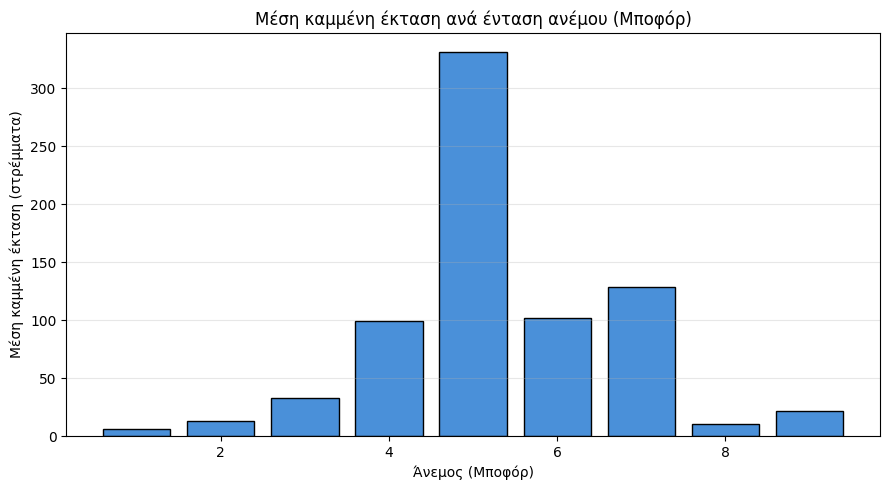

In [39]:
import matplotlib.pyplot as plt

wind = dfjoin.groupby('Άνεμος_Μποφόρ')['Καμμένη_Έκταση'].mean()

plt.figure(figsize=(9, 5))
plt.bar(wind.index, wind.values, color='#4A90D9', edgecolor='black')
plt.title('Μέση καμμένη έκταση ανά ένταση ανέμου (Μποφόρ)')
plt.xlabel('Άνεμος (Μποφόρ)')
plt.ylabel('Μέση καμμένη έκταση (στρέμματα)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


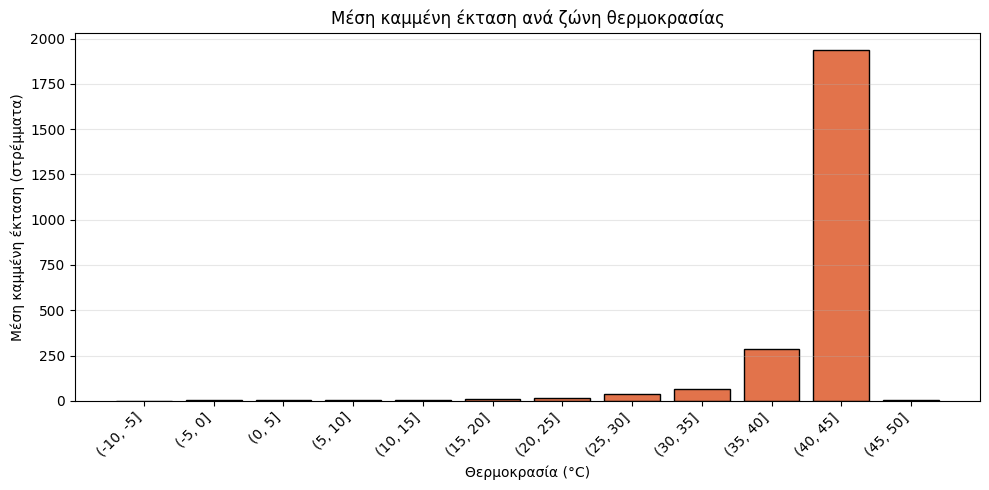

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# Ομαδοποιούμε τη θερμοκρασία σε ζώνες των 5°C
bins = range(-10, 51, 5)
dfjoin['Ζώνη_Θερμοκρασίας'] = pd.cut(dfjoin['Θερμοκρασία_C'], bins=bins)
temp = dfjoin.groupby('Ζώνη_Θερμοκρασίας', observed=True)['Καμμένη_Έκταση'].mean()

plt.figure(figsize=(10, 5))
plt.bar([str(i) for i in temp.index], temp.values, color='#E2734B', edgecolor='black')
plt.title('Μέση καμμένη έκταση ανά ζώνη θερμοκρασίας')
plt.xlabel('Θερμοκρασία (°C)')
plt.ylabel('Μέση καμμένη έκταση (στρέμματα)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

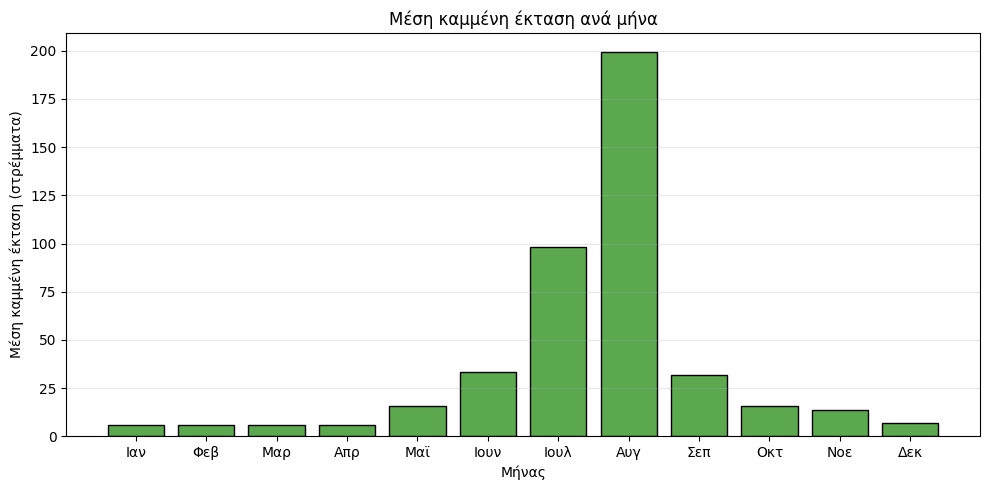

In [41]:
import matplotlib.pyplot as plt

months = ['Ιαν','Φεβ','Μαρ','Απρ','Μαϊ','Ιουν','Ιουλ','Αυγ','Σεπ','Οκτ','Νοε','Δεκ']
month = dfjoin.groupby('Μήνας')['Καμμένη_Έκταση'].mean()

plt.figure(figsize=(10, 5))
plt.bar([months[int(m)-1] for m in month.index], month.values, color='#5BA84F', edgecolor='black')
plt.title('Μέση καμμένη έκταση ανά μήνα')
plt.xlabel('Μήνας')
plt.ylabel('Μέση καμμένη έκταση (στρέμματα)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

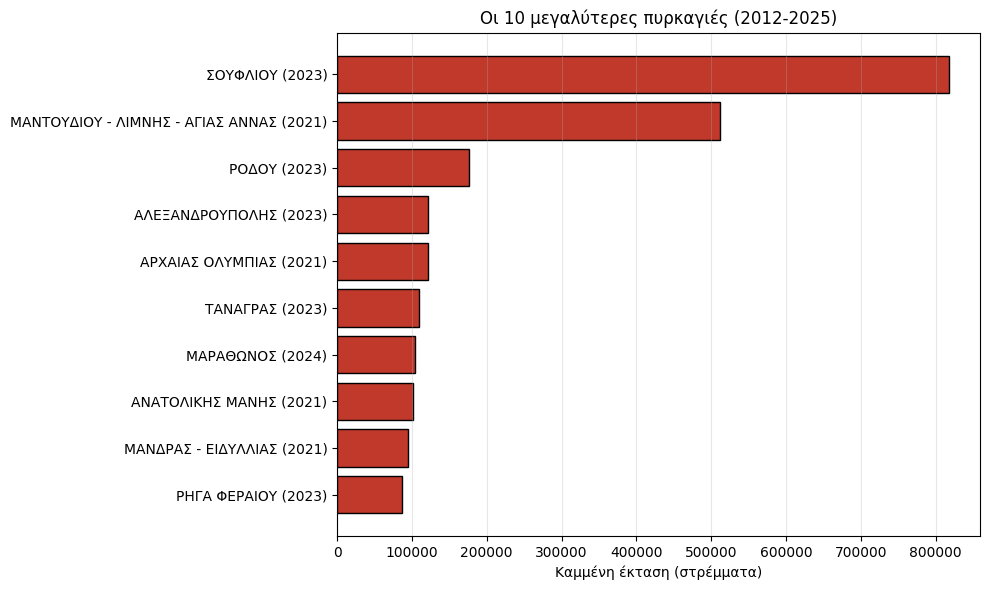

In [42]:
import matplotlib.pyplot as plt

top10 = dfjoin.nlargest(10, 'Καμμένη_Έκταση').copy()
top10['ετικέτα'] = top10['Δήμος_Κλεισθένη'] + ' (' + top10['ΕΤΟΣ'].astype(str) + ')'

plt.figure(figsize=(10, 6))
plt.barh(top10['ετικέτα'][::-1], top10['Καμμένη_Έκταση'][::-1], color='#C0392B', edgecolor='black')
plt.title('Οι 10 μεγαλύτερες πυρκαγιές (2012-2025)')
plt.xlabel('Καμμένη έκταση (στρέμματα)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

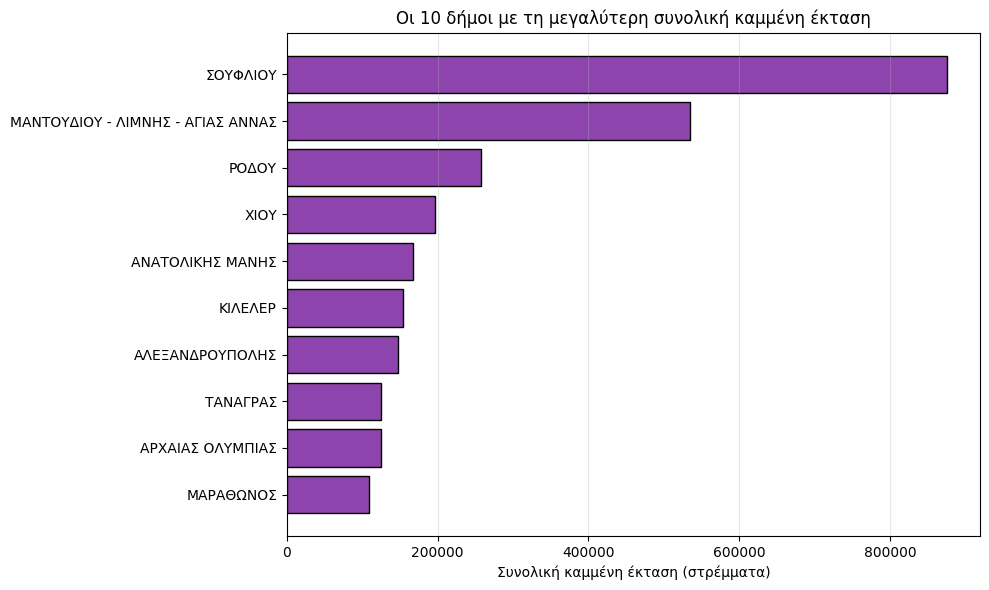

In [43]:
import matplotlib.pyplot as plt

top_dimoi = dfjoin.groupby('Δήμος_Κλεισθένη')['Καμμένη_Έκταση'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
plt.barh(top_dimoi.index[::-1], top_dimoi.values[::-1], color='#8E44AD', edgecolor='black')
plt.title('Οι 10 δήμοι με τη μεγαλύτερη συνολική καμμένη έκταση')
plt.xlabel('Συνολική καμμένη έκταση (στρέμματα)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

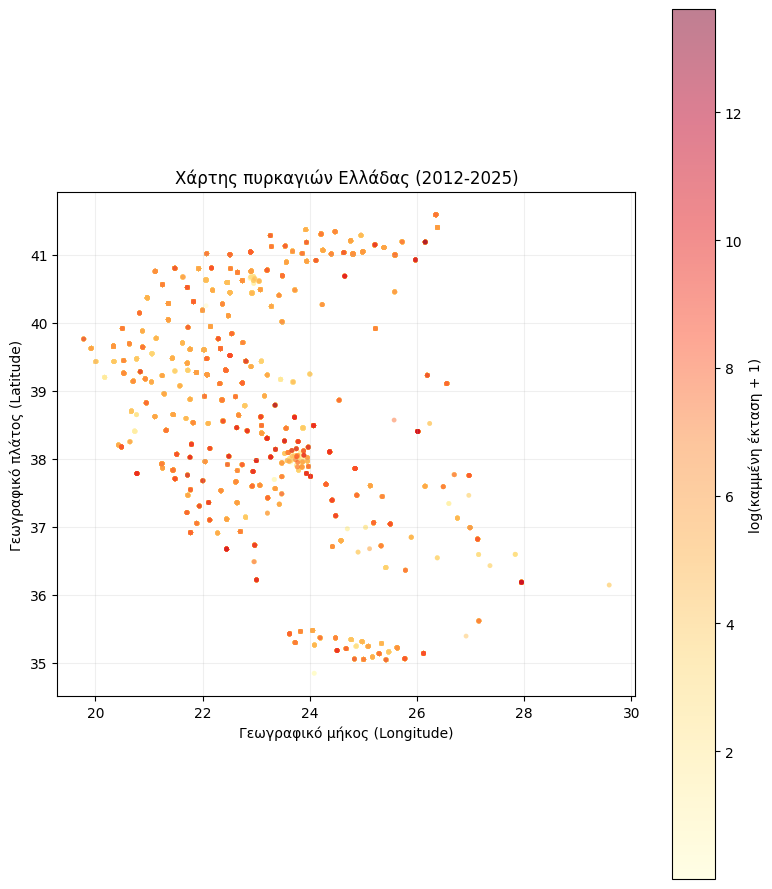

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

d = dfjoin.dropna(subset=['Latitude', 'Longitude']).sort_values('Καμμένη_Έκταση')

plt.figure(figsize=(8, 9))
sc = plt.scatter(d['Longitude'], d['Latitude'],
                 c=np.log1p(d['Καμμένη_Έκταση']), cmap='YlOrRd',
                 s=12, alpha=0.5, edgecolors='none')
plt.colorbar(sc, label='log(καμμένη έκταση + 1)')
plt.title('Χάρτης πυρκαγιών Ελλάδας (2012-2025)')
plt.xlabel('Γεωγραφικό μήκος (Longitude)')
plt.ylabel('Γεωγραφικό πλάτος (Latitude)')
plt.gca().set_aspect(1 / np.cos(np.radians(38)))   
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

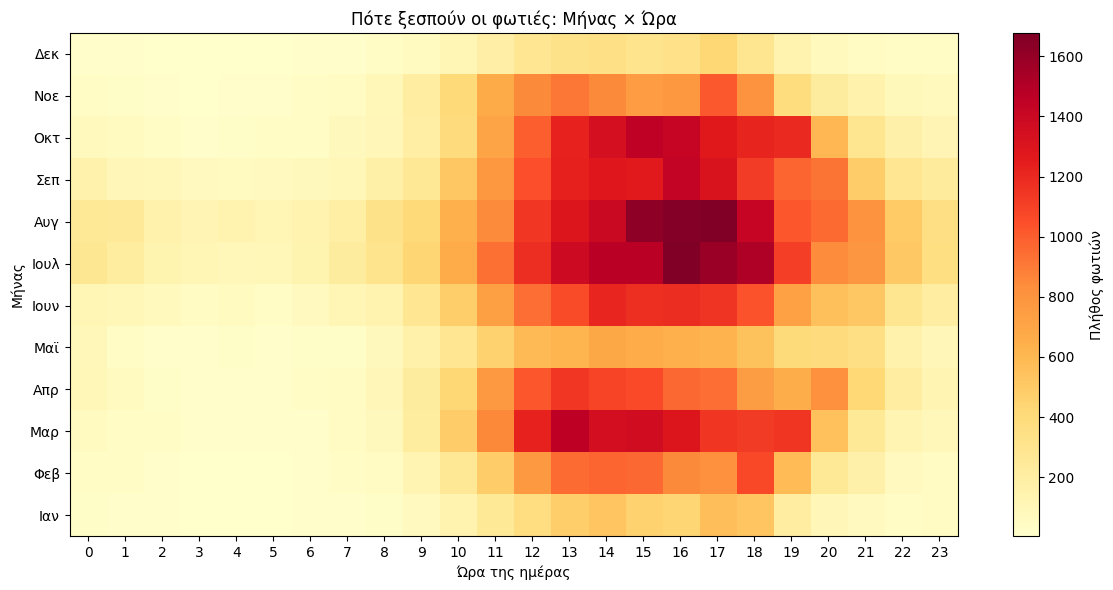

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

piv = pd.crosstab(dfjoin['Μήνας'], dfjoin['Ώρα'])
months = ['Ιαν','Φεβ','Μαρ','Απρ','Μαϊ','Ιουν','Ιουλ','Αυγ','Σεπ','Οκτ','Νοε','Δεκ']

plt.figure(figsize=(12, 6))
plt.imshow(piv.values, aspect='auto', cmap='YlOrRd', origin='lower')
plt.colorbar(label='Πλήθος φωτιών')
plt.title('Πότε ξεσπούν οι φωτιές: Μήνας × Ώρα')
plt.xlabel('Ώρα της ημέρας')
plt.ylabel('Μήνας')
plt.xticks(range(24), range(24))
plt.yticks(range(12), months)
plt.tight_layout()
plt.show()

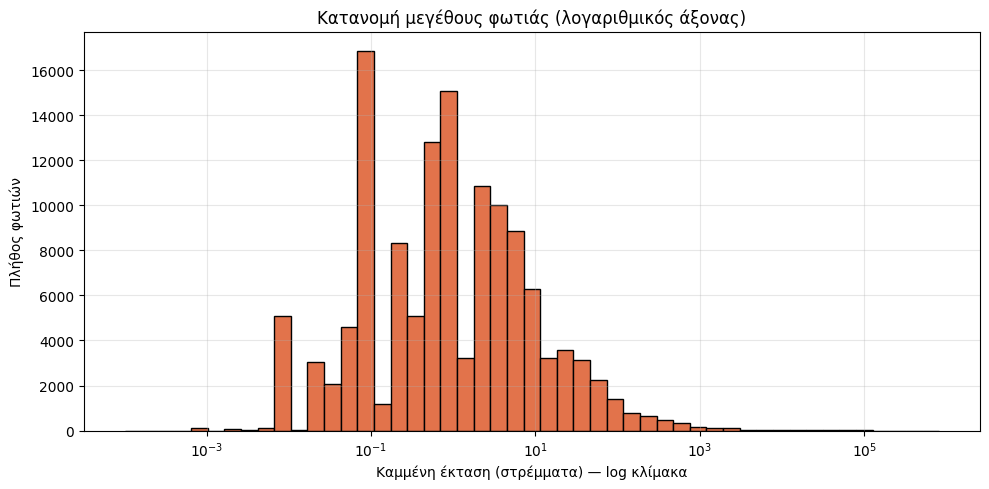

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Μόνο φωτιές με έκταση > 0 (ο λογάριθμος δεν ορίζεται στο 0)
areas = dfjoin.loc[dfjoin['Καμμένη_Έκταση'] > 0, 'Καμμένη_Έκταση']

plt.figure(figsize=(10, 5))
bins = np.logspace(np.log10(areas.min()), np.log10(areas.max()), 50)
plt.hist(areas, bins=bins, color='#E2734B', edgecolor='black')
plt.xscale('log')
plt.title('Κατανομή μεγέθους φωτιάς (λογαριθμικός άξονας)')
plt.xlabel('Καμμένη έκταση (στρέμματα) — log κλίμακα')
plt.ylabel('Πλήθος φωτιών')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


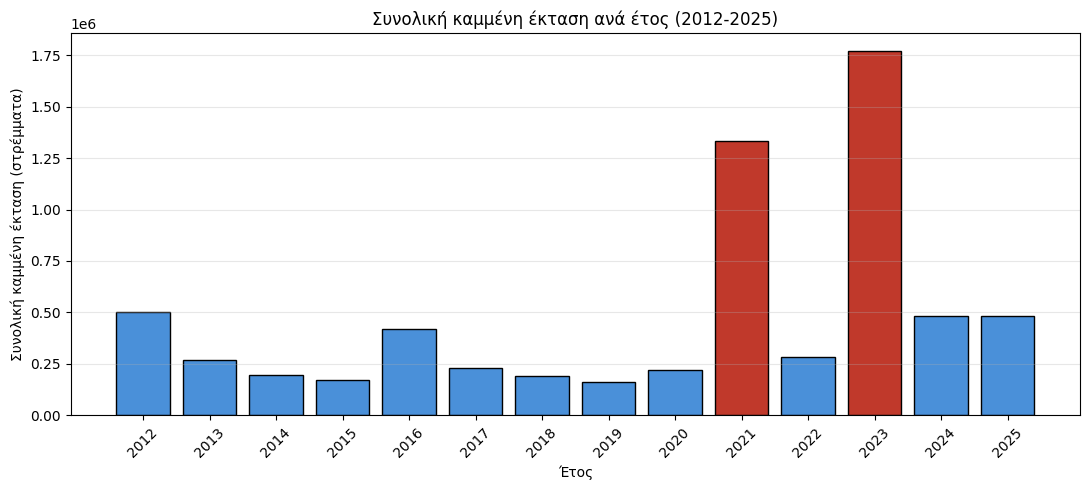

In [ ]:
import matplotlib.pyplot as plt

yearly = dfjoin.groupby('ΕΤΟΣ')['Καμμένη_Έκταση'].sum()

plt.figure(figsize=(11, 5))
colors = ['#C0392B' if v > 1_000_000 else '#4A90D9' for v in yearly.values]
plt.bar(yearly.index, yearly.values, color=colors, edgecolor='black')
plt.title('Συνολική καμμένη έκταση ανά έτος (2012-2025)')
plt.xlabel('Έτος')
plt.ylabel('Συνολική καμμένη έκταση (στρέμματα)')
plt.xticks(yearly.index, rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


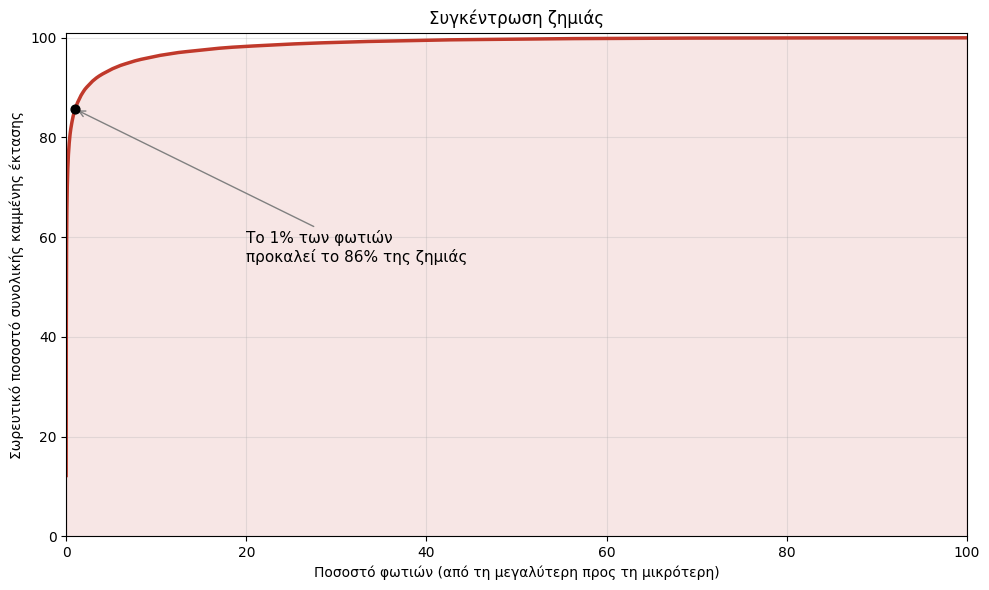

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

a = np.sort(dfjoin[dfjoin['Καμμένη_Έκταση'] > 0]['Καμμένη_Έκταση'].values)[::-1]
cum_area = np.cumsum(a) / a.sum() * 100
pct_fires = np.arange(1, len(a) + 1) / len(a) * 100

plt.figure(figsize=(10, 6))
plt.plot(pct_fires, cum_area, lw=2.5, color='#C0392B')
plt.fill_between(pct_fires, cum_area, alpha=0.12, color='#C0392B')

# Σημείο-κλειδί: top 1%
k = int(len(a) * 0.01)
plt.scatter([1], [cum_area[k-1]], color='black', zorder=5, s=40)
plt.annotate(f'Το 1% των φωτιών\nπροκαλεί το {cum_area[k-1]:.0f}% της ζημιάς',
             xy=(1, cum_area[k-1]), xytext=(20, 55),
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=11)

plt.xlabel('Ποσοστό φωτιών (από τη μεγαλύτερη προς τη μικρότερη)')
plt.ylabel('Σωρευτικό ποσοστό συνολικής καμμένης έκτασης')
plt.title('Συγκέντρωση ζημιάς')
plt.grid(alpha=0.3)
plt.xlim(0, 100); plt.ylim(0, 101)
plt.tight_layout()
plt.show()

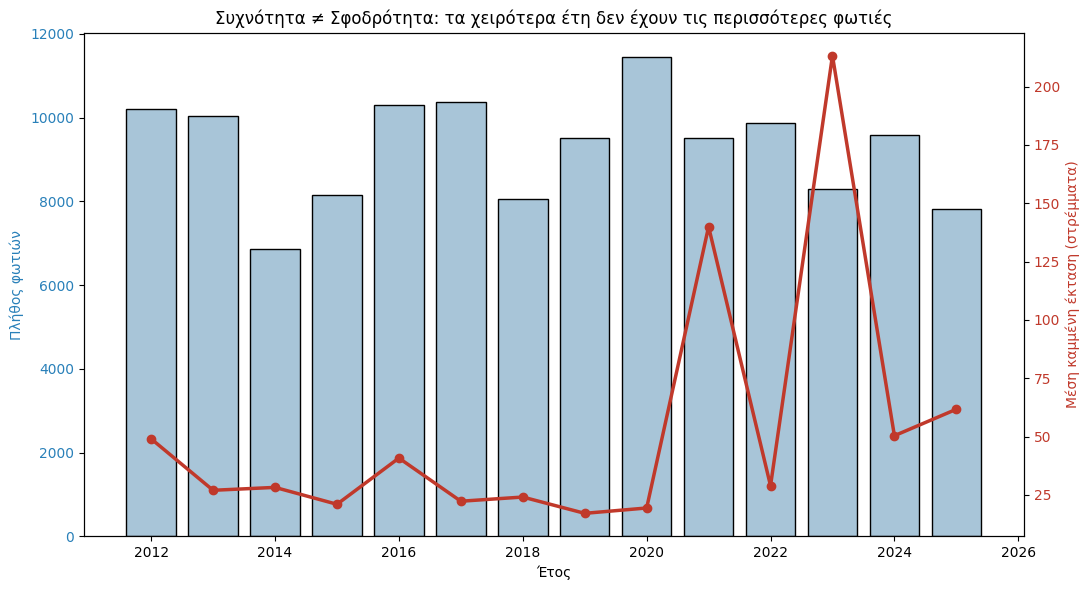

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

d = dfjoin[dfjoin['Καμμένη_Έκταση'] > 0]
g = d.groupby('ΕΤΟΣ').agg(count=('Καμμένη_Έκταση', 'size'),
                          mean=('Καμμένη_Έκταση', 'mean'))

fig, ax1 = plt.subplots(figsize=(11, 6))

# Μπάρες: πλήθος φωτιών (συχνότητα)
ax1.bar(g.index, g['count'], color='#A8C5D8', edgecolor='black', label='Πλήθος φωτιών')
ax1.set_xlabel('Έτος')
ax1.set_ylabel('Πλήθος φωτιών', color='#2980B9')
ax1.tick_params(axis='y', labelcolor='#2980B9')

# Γραμμή: μέση έκταση (σφοδρότητα)
ax2 = ax1.twinx()
ax2.plot(g.index, g['mean'], color='#C0392B', marker='o', lw=2.5, label='Μέση έκταση/φωτιά')
ax2.set_ylabel('Μέση καμμένη έκταση (στρέμματα)', color='#C0392B')
ax2.tick_params(axis='y', labelcolor='#C0392B')

plt.title('Συχνότητα ≠ Σφοδρότητα: τα χειρότερα έτη δεν έχουν τις περισσότερες φωτιές')
fig.tight_layout()
plt.show()

In [51]:
import pandas as pd
import numpy as np

mega = dfjoin[dfjoin['Καμμένη_Έκταση'] > 50000]
rest = dfjoin[(dfjoin['Καμμένη_Έκταση'] > 0) & (dfjoin['Καμμένη_Έκταση'] <= 50000)]

print("=" * 60)
print("ΑΝΑΛΥΣΗ ΜΕΓΑΛΩΝ ΠΥΡΚΑΓΙΩΝ (>50.000 στρέμματα)")
print("=" * 60)
print(f"\nΠλήθος: {len(mega)} φωτιές από {len(dfjoin[dfjoin['Καμμένη_Έκταση']>0]):,} "
      f"({len(mega)/len(dfjoin[dfjoin['Καμμένη_Έκταση']>0])*100:.3f}%)\n")

# Οι 10 μεγαλύτερες
cols = ['ΕΤΟΣ', 'Μήνας', 'Περιφέρεια', 'Θερμοκρασία_C', 'Υγρασία_%',
        'Μέρες_χωρίς_βροχή', 'Καμμένη_Έκταση']
print("Οι 10 μεγαλύτερες πυρκαγιές:")
print(dfjoin.nlargest(10, 'Καμμένη_Έκταση')[cols].to_string(index=False))

# Σύγκριση συνθηκών
print("\n--- Μέσες συνθήκες: μεγαπυρκαγιές vs υπόλοιπες ---")
for c in ['Θερμοκρασία_C', 'Υγρασία_%', 'Μέρες_χωρίς_βροχή']:
    print(f"  {c:18}: {mega[c].mean():6.1f}  vs  {rest[c].mean():6.1f}")

ΑΝΑΛΥΣΗ ΜΕΓΑΛΩΝ ΠΥΡΚΑΓΙΩΝ (>50.000 στρέμματα)

Πλήθος: 18 φωτιές από 130,093 (0.014%)

Οι 10 μεγαλύτερες πυρκαγιές:
 ΕΤΟΣ  Μήνας                       Περιφέρεια  Θερμοκρασία_C  Υγρασία_%  Μέρες_χωρίς_βροχή  Καμμένη_Έκταση
 2023      8 ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ ΚΑΙ ΘΡΑΚΗΣ           35.5       30.0               15.0       818348.00
 2021      8                  ΣΤΕΡΕΑΣ ΕΛΛΑΔΑΣ           40.7       45.0               15.0       511854.14
 2023      7                   ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ           39.9       32.0               30.0       176398.00
 2023      8 ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ ΚΑΙ ΘΡΑΚΗΣ           34.5       44.0               13.0       122144.00
 2021      8                  ΔΥΤΙΚΗΣ ΕΛΛΑΔΑΣ           38.2       20.0               13.0       121000.00
 2023      7                  ΣΤΕΡΕΑΣ ΕΛΛΑΔΑΣ            NaN       41.0               17.0       110000.00
 2024      8                          ΑΤΤΙΚΗΣ           31.8       47.0                1.0       104138.00
 2021      8                


Πρώτη προσέγγιση: πρόβλεψη της  καμμένης έκτασης σε λογαριθμική κλίμακα.

Προεπεξεργασία και Διαχωρισμός Train/Test

Τέσσερις κρίσιμες αποφάσεις πριν την εκπαίδευση:

1. Λογαριθμικός στόχος: log1p(έκταση) — λόγω της ακραίας ασυμμετρίας της κατανομής.
2. One-hot encoding 
3. Χρονολογικός διαχωρισμός: trainset 2012–2024, testset 2025. 
4. StandardScaler προσαρμοσμένη μόνο στο train — το test κανονικοποιείται με τις παραμέτρους του train.

In [52]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

dfjoin = pd.read_csv("dffinal.csv")

area_cols = ['Δάση', 'Δασική Έκταση', 'Άλση', 'Χορτ/κές Εκτάσεις',
             'Καλάμια - Βάλτοι', 'Γεωργικές Εκτάσεις',
             'Υπολλείματα Καλλιεργειών', 'Σκουπιδότοποι']
dfjoin['Καμμένη_Έκταση'] = dfjoin[area_cols].sum(axis=1)
dfjoin['Καμμένη_Έκταση_log'] = np.log1p(dfjoin['Καμμένη_Έκταση'])

df_model = dfjoin[dfjoin['Καμμένη_Έκταση'] > 0].dropna(subset=['Θερμοκρασία_C', 'Περιφέρεια', 'Υγρασία_%']).copy()

features = [
    'Περιφέρεια', 'Latitude', 'Longitude', 'ΕΤΟΣ', 'Μήνας', 'Ώρα',
    'Ημέρα_Εβδομάδας', 'Θερμοκρασία_C', 'Άνεμος_Μποφόρ', 'Διεύθυνση_Ανέμου',
    'Υγρασία_%', 'Βροχή_mm', 'Βροχή_7ημ', 'Βροχή_30ημ', 'Μέρες_χωρίς_βροχή' 
]
df_model = df_model[features + ['Καμμένη_Έκταση_log']].copy()

df_model = pd.get_dummies(df_model,
    columns=['Μήνας', 'Ώρα', 'Ημέρα_Εβδομάδας', 'Περιφέρεια', 'Διεύθυνση_Ανέμου'],
    drop_first=True)
bool_cols = df_model.select_dtypes(bool).columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

X = df_model.drop(columns=['Καμμένη_Έκταση_log'])
y = df_model['Καμμένη_Έκταση_log']

#split
train_mask = df_model['ΕΤΟΣ'] < 2025
test_mask  = df_model['ΕΤΟΣ'] == 2025
X_train, X_test = X[train_mask].copy(), X[test_mask].copy()
y_train, y_test = y[train_mask].copy(), y[test_mask].copy()

# ΠΡΟΣΘΗΚΗ ΤΩΝ ΝΕΩΝ ΜΕΤΑΒΛΗΤΩΝ ΚΑΙ ΣΤΟ SCALING!
num_cols = [
    'Latitude', 'Longitude', 'ΕΤΟΣ', 'Θερμοκρασία_C', 'Άνεμος_Μποφόρ',
    'Υγρασία_%', 'Βροχή_mm', 'Βροχή_7ημ', 'Βροχή_30ημ', 'Μέρες_χωρίς_βροχή' # <--- Προστέθηκαν εδώ
]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("εχω: X_train, X_test, y_train, y_test με ΟΛΑ τα νέα δεδομένα καιρού!")

Train: (110328, 70) | Test: (7222, 70)
εχω: X_train, X_test, y_train, y_test με ΟΛΑ τα νέα δεδομένα καιρού!


Συνάρτηση αξιολόγησης και REC curve

Ορίζουμε ενιαία συνάρτηση evaluate που υπολογίζει R², RMSE, MAE και παράγει διαγνωστικά
γραφήματα για κάθε μοντέλο. Περιλαμβάνει τη REC curve (Regression Error Characteristic) —
δείχνει τι ποσοστό των προβλέψεων πέφτει μέσα σε δεδομένη ανοχή σφάλματος (σε στρέμματα).

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#ανοχή εώς 50 στρέμματα 
tol_range = list(range(0, 51))   

def rec(pred_log, true_log, tols):
    """% προβλέψεων μέσα σε ανοχή 'tol' στρεμμάτων (πραγματική κλίμακα)."""
    err = np.abs(np.expm1(pred_log) - np.expm1(true_log))
    return [100 * np.mean(err <= t) for t in tols]

rec_results = {}      
metric_results = {}   

def evaluate(name, y_true_log, pred_log):
    rmse = np.sqrt(mean_squared_error(y_true_log, pred_log))
    mae_log = mean_absolute_error(y_true_log, pred_log)
    pred_r, true_r = np.expm1(pred_log), np.expm1(y_true_log)
    mae_str = mean_absolute_error(true_r, pred_r)
    r2 = r2_score(y_true_log, pred_log)

    print(f"\n=== {name} ===")
    print(f"  R² (log): {r2*100:.2f}%  |  RMSE (log): {rmse:.3f}  |  MAE (log): {mae_log:.3f}  |  MAE: {mae_str:.1f} στρέμματα")

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].scatter(true_r, pred_r - true_r, alpha=0.3, s=10)
    ax[0].set_xlabel("Πραγματική έκταση (στρέμματα)"); ax[0].set_ylabel("Σφάλμα")
    ax[0].set_title(f"{name}: Πραγματικό vs Σφάλμα"); ax[0].grid(True, alpha=0.3)
    ax[1].hist(pred_r - true_r, bins=50, color='#E2734B', edgecolor='black')
    ax[1].set_xlabel("Σφάλμα (στρέμματα)"); ax[1].set_ylabel("Πλήθος")
    ax[1].set_title(f"{name}: Κατανομή σφαλμάτων"); ax[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    rec_results[name] = rec(pred_log, y_true_log, tol_range)
    metric_results[name] = {'R² (log) %': round(r2*100, 2), 'RMSE (log)': round(rmse, 3), 'MAE (στρ)': round(mae_str, 1)}

Σύγκριση επιμέρους μοντέλων

Αξιολογούμε κάθε base learner ξεχωριστά. Tο Gradient Boosting μόνο του
είναι ελαφρώς καλύτερο από όλο το stacking, ένδειξη ότι όταν ένα μοντέλο
κυριαρχεί, το ensemble δεν προσθέτει αξία. 

Παρόλο που το stacking δεν βοηθά το αφήνουμε γιατί η διαφορά είναι ελάχιστη.



In [54]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, StackingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

base_learners = [
    ('ridge', Ridge(alpha=1.0)),                             
    ('gb', HistGradientBoostingRegressor(                     
        max_iter=300, learning_rate=0.05, max_depth=6, random_state=42
    )),
    ('rf', RandomForestRegressor(                            
        n_estimators=200, max_depth=20, random_state=42, n_jobs=-1
    )),
    ('mlp', MLPRegressor(                                     
        hidden_layer_sizes=(64, 32, 16), activation='relu', solver='adam',
        early_stopping=True, validation_fraction=0.2, max_iter=500, random_state=42
    )),
]

# stacking
stack = StackingRegressor(
    estimators=base_learners,
    final_estimator=Ridge(alpha=1.0),
    cv=5,              
    n_jobs=-1
)

print("Εκπαίδευση stacking (Ridge + GB + RF + MLP)")
stack.fit(X_train, y_train)          

pred_log = stack.predict(X_test)


def report(name, y_true_log, p_log):
    r2      = r2_score(y_true_log, p_log)
    mae_log = mean_absolute_error(y_true_log, p_log)
    mae_str = mean_absolute_error(np.expm1(y_true_log), np.expm1(p_log))
    print(f"\n{name}")
    print(f"  R² (log-κλίμακα):  {r2*100:.2f}%")
    print(f"  MAE (log):         {mae_log:.3f}")
    print(f"  MAE σε στρέμματα:  {mae_str:.1f}")

report(" STACKING (Ridge + GB + RF + MLP)", y_test, pred_log)

print("\n Σύγκριση με τα επιμέρους")
for name, model in base_learners:
    model.fit(X_train, y_train)
    report(name.upper(), y_test, model.predict(X_test))


⏳ Εκπαίδευση stacking (Ridge + GB + RF + MLP)...

 STACKING (Ridge + GB + RF + MLP)
  R² (log-κλίμακα):  15.01%   ← κύριος δείκτης
  MAE (log):         0.926
  MAE σε στρέμματα:  66.3

--- Σύγκριση με τα επιμέρους ---

RIDGE
  R² (log-κλίμακα):  10.64%   ← κύριος δείκτης
  MAE (log):         0.918
  MAE σε στρέμματα:  66.2

GB
  R² (log-κλίμακα):  15.07%   ← κύριος δείκτης
  MAE (log):         0.922
  MAE σε στρέμματα:  66.3

RF
  R² (log-κλίμακα):  9.92%   ← κύριος δείκτης
  MAE (log):         0.966
  MAE σε στρέμματα:  66.6

MLP
  R² (log-κλίμακα):  11.86%   ← κύριος δείκτης
  MAE (log):         0.942
  MAE σε στρέμματα:  66.4


ΑΞΙΟΛΟΓΗΣΗ ΜΕΜΟΝΩΜΕΝΩΝ ΜΟΝΤΕΛΩΝ

⏳ Εκπαίδευση του RIDGE...

=== RIDGE ===
  R² (log): 10.64%  |  RMSE (log): 1.302  |  MAE (log): 0.918  |  MAE: 66.2 στρέμματα


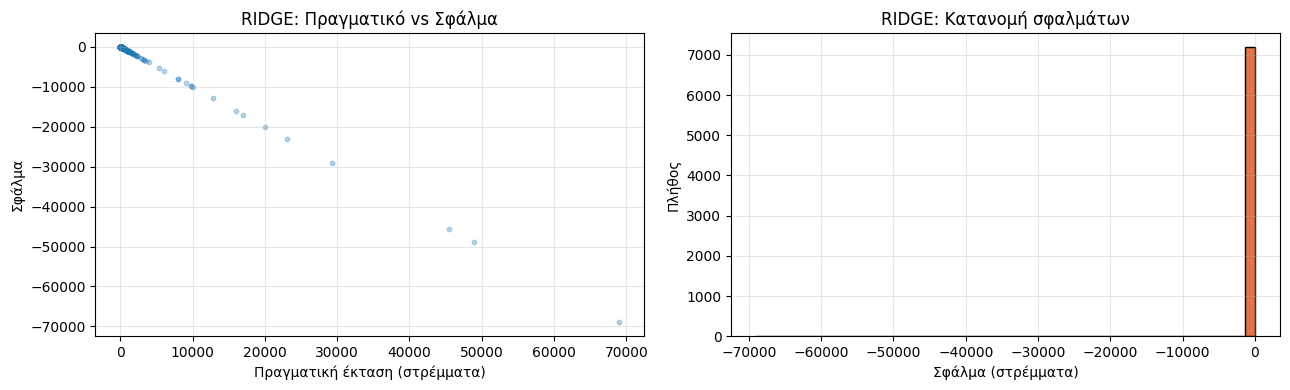


⏳ Εκπαίδευση του GB...

=== GB ===
  R² (log): 15.07%  |  RMSE (log): 1.269  |  MAE (log): 0.922  |  MAE: 66.3 στρέμματα


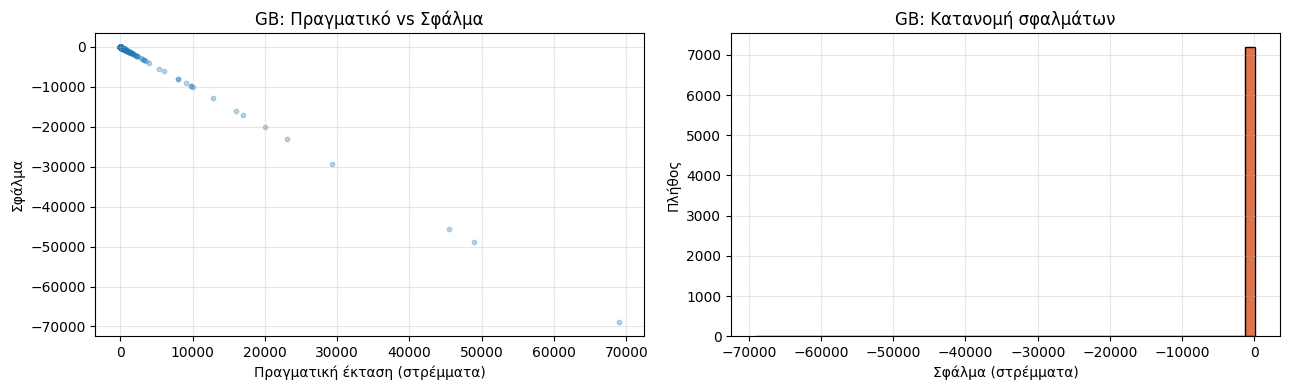


⏳ Εκπαίδευση του RF...

=== RF ===
  R² (log): 9.92%  |  RMSE (log): 1.307  |  MAE (log): 0.966  |  MAE: 66.6 στρέμματα


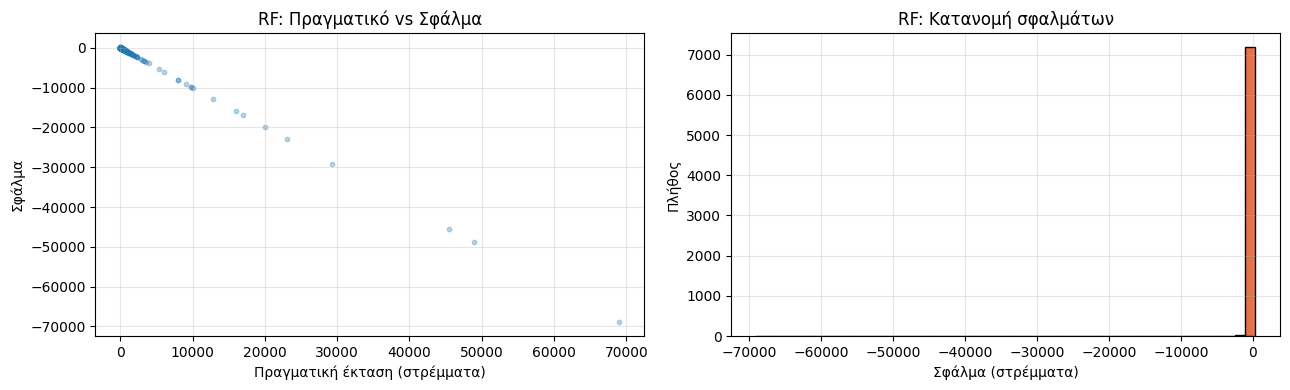


⏳ Εκπαίδευση του MLP...

=== MLP ===
  R² (log): 11.86%  |  RMSE (log): 1.293  |  MAE (log): 0.942  |  MAE: 66.4 στρέμματα


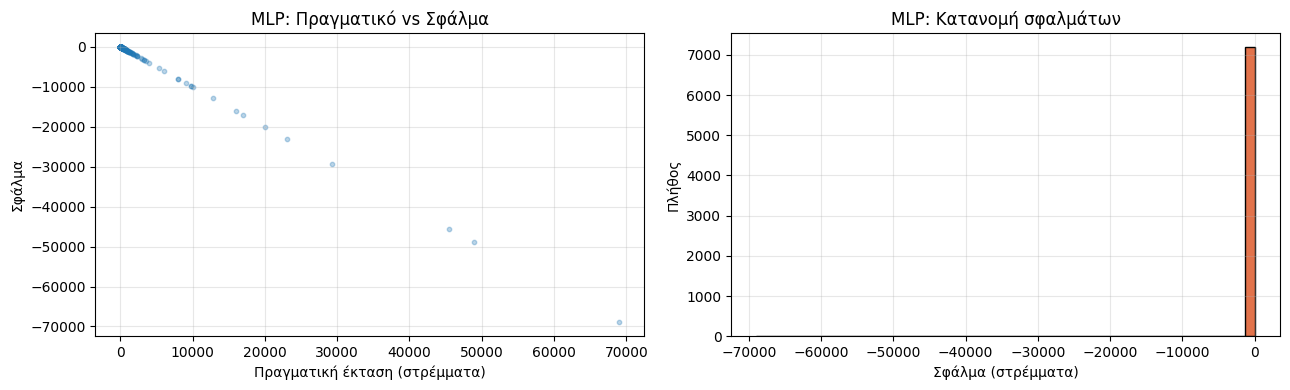


 Η αξιολόγηση όλων των μεμονωμένων μοντέλων ολοκληρώθηκε!


In [ ]:
print("ΑΞΙΟΛΟΓΗΣΗ ΜΕΜΟΝΩΜΕΝΩΝ ΜΟΝΤΕΛΩΝ")

for name, model in base_learners:
    print(f"\n Εκπαίδευση του {name.upper()}...")
    
    #  Εκπαίδευση
    model.fit(X_train, y_train)
    
    #  Πρόβλεψη 
    pred_log = model.predict(X_test)
    
    evaluate(name.upper(), y_test, pred_log)

print("\n Η αξιολόγηση όλων των μεμονωμένων μοντέλων ολοκληρώθηκε")

Ποιοι παράγοντες καθορίζουν το μέγεθος της πυρκαγιάς;

In [55]:
import numpy as np
from sklearn.metrics import mean_squared_error

def report_rmse(name, y_true_log, p_log):
    rmse_ln = np.sqrt(mean_squared_error(y_true_log, p_log))
    rmse_log10 = rmse_ln / np.log(10)
    rmse_str = np.sqrt(mean_squared_error(np.expm1(y_true_log), np.expm1(p_log)))
    print(f"{name}")
    print(f"  RMSE (ln):     {rmse_ln:.3f}")
    print(f"  RMSE (log10):  {rmse_log10:.3f}   ← για σύγκριση με Cortez/geeky-bit")
    print(f"  RMSE (στρέμ.): {rmse_str:,.1f}")
    print()

print("=" * 50)
print("RMSE ΑΝΑ ΜΟΝΤΕΛΟ")
print("=" * 50)
report_rmse(" STACKING", y_test, pred_log)

for name, model in base_learners:
    report_rmse(name.upper(), y_test, model.predict(X_test))

print("=" * 50)
print("ΣΥΓΚΡΙΣΗ ΜΕ ΑΝΑΦΟΡΑ (RMSE σε log10)")
print("=" * 50)
print("  Εργασία αναφοράς (geeky-bit / Cortez):")
print("    SVR: 0.671 | Decision Tree: 0.624 | Random Forest: 0.615 | Deep NN: 0.610")


RMSE ΑΝΑ ΜΟΝΤΕΛΟ
 STACKING
  RMSE (ln):     1.270
  RMSE (log10):  0.551   ← για σύγκριση με Cortez/geeky-bit
  RMSE (στρέμ.): 1,311.2

RIDGE
  RMSE (ln):     1.302
  RMSE (log10):  0.565   ← για σύγκριση με Cortez/geeky-bit
  RMSE (στρέμ.): 1,311.5

GB
  RMSE (ln):     1.269
  RMSE (log10):  0.551   ← για σύγκριση με Cortez/geeky-bit
  RMSE (στρέμ.): 1,311.2

RF
  RMSE (ln):     1.307
  RMSE (log10):  0.568   ← για σύγκριση με Cortez/geeky-bit
  RMSE (στρέμ.): 1,311.1

MLP
  RMSE (ln):     1.293
  RMSE (log10):  0.561   ← για σύγκριση με Cortez/geeky-bit
  RMSE (στρέμ.): 1,311.2

ΣΥΓΚΡΙΣΗ ΜΕ ΑΝΑΦΟΡΑ (RMSE σε log10)
  Εργασία αναφοράς (geeky-bit / Cortez):
    SVR: 0.671 | Decision Tree: 0.624 | Random Forest: 0.615 | Deep NN: 0.610


ΤΙ ΠΡΟΚΑΛΕΙ ΤΙΣ ΦΩΤΙΕΣ?


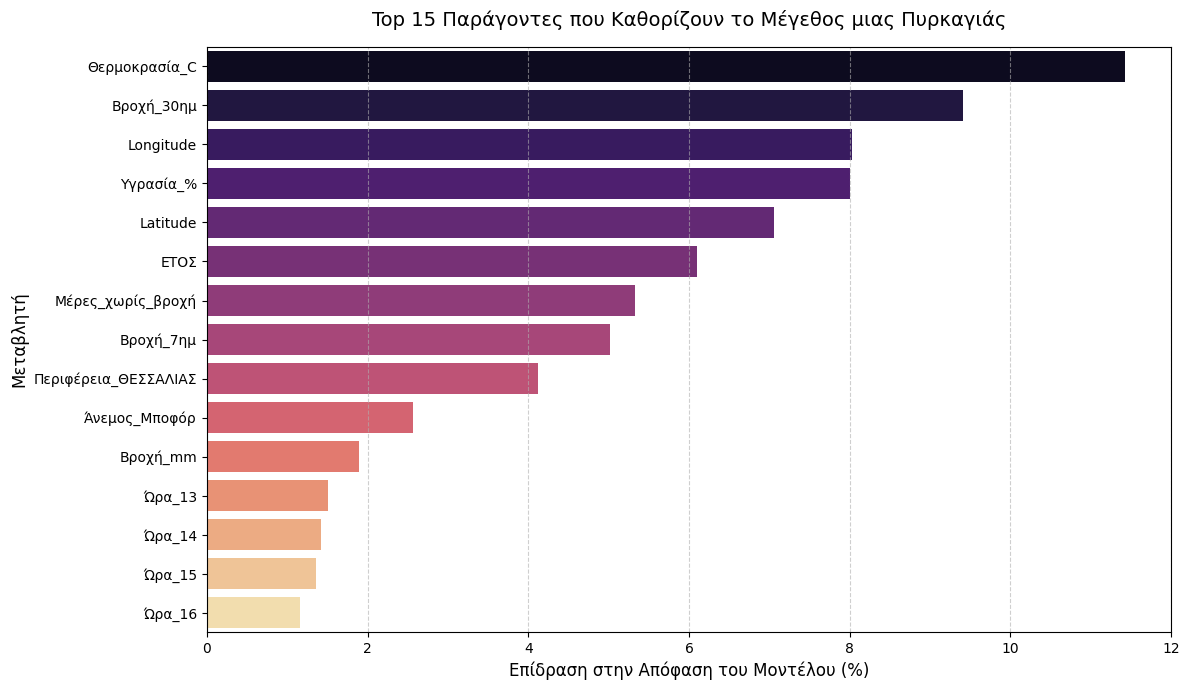

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("ΤΙ ΠΡΟΚΑΛΕΙ ΤΙΣ ΦΩΤΙΕΣ?")

rf_model = stack.named_estimators_['rf']

importance_df = pd.DataFrame({
    'Χαρακτηριστικό': X_train.columns,
    'Βαρύτητα (%)': rf_model.feature_importances_ * 100
}).sort_values(by='Βαρύτητα (%)', ascending=False)

top_15 = importance_df.head(15)

# Γράφημα
plt.figure(figsize=(12, 7))
sns.barplot(x='Βαρύτητα (%)', y='Χαρακτηριστικό', data=top_15,
            hue='Χαρακτηριστικό', palette='magma', legend=False)
plt.title('Top 15 Παράγοντες που Καθορίζουν το Μέγεθος μιας Πυρκαγιάς', fontsize=14, pad=15)
plt.xlabel('Επίδραση στην Απόφαση του Μοντέλου (%)', fontsize=12)
plt.ylabel('Μεταβλητή', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



Οπτική αξιολόγηση: πρόβλεψη και πραγματικότητα

Το scatter plot συγκρίνει προβλεπόμενη και πραγματική έκταση. Αποκαλύπτει το βασικό όριο
του μοντέλου: για μεγάλες φωτιές τα σημεία πέφτουν κάτω από τη διαγώνιο — το μοντέλο
υποεκτιμά συστηματικά τις μεγάλες πυρκαγιές, αφού η συντριπτική πλειονότητα
των φωτιών είναι μικρές. 

SCATTER PLOT


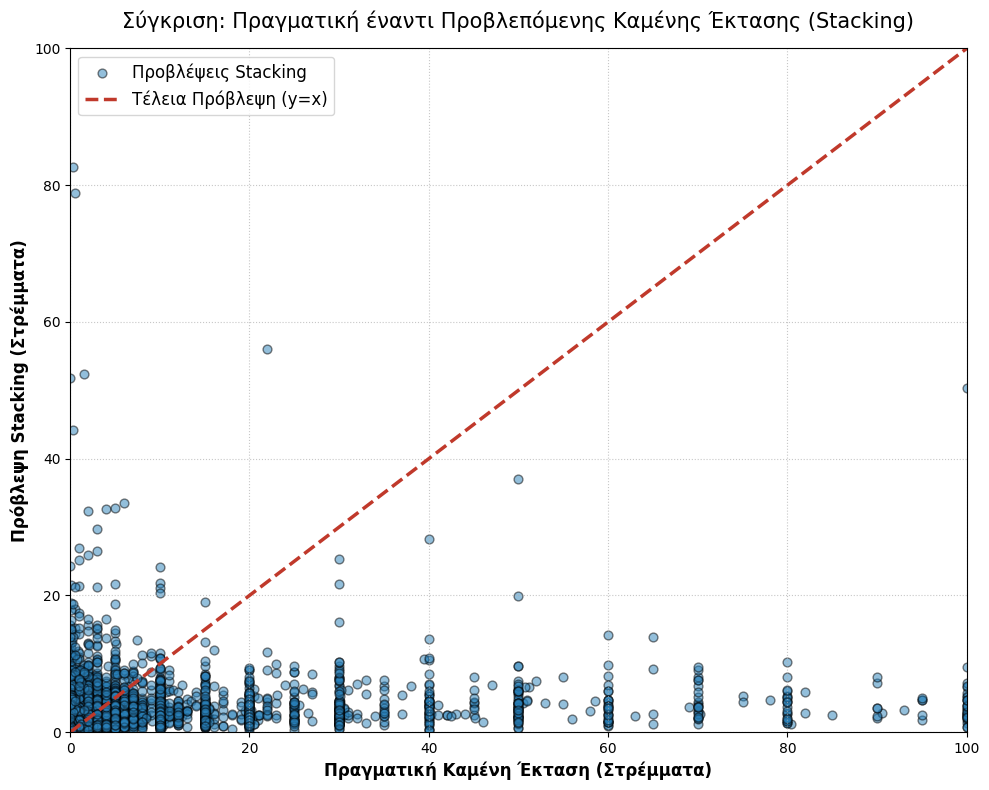

- Κάθε τελεία είναι μια μεμονωμένη πυρκαγιά του Test Set (2025).
- Όσο πιο κοντά βρίσκεται μια τελεία στην κόκκινη διακεκομμένη γραμμή, τόσο πιο ακριβής ήταν η πρόβλεψη του Stacking.
- Τελείες ΠΑΝΩ από την κόκκινη γραμμή δείχνουν ότι το μοντέλο 'υπερεκτίμησε' τον κίνδυνο (προέβλεψε περισσότερα στρέμματα από όσα κάηκαν, ίσως λόγω άμεσης επέμβασης της Πυροσβεστικής).
- Τελείες ΚΑΤΩ από την κόκκινη γραμμή δείχνουν υποεκτίμηση του μεγέθους.


In [57]:
import matplotlib.pyplot as plt
import numpy as np

print("SCATTER PLOT")

stacking_preds_log = stack.predict(X_test)

predicted_acres = np.expm1(stacking_preds_log)
actual_acres = np.expm1(y_test)

plt.figure(figsize=(10, 8))

plt.scatter(actual_acres, predicted_acres, alpha=0.5, color='#2980B9', edgecolor='k', s=40, label='Προβλέψεις Stacking')

max_limit = 100 
plt.plot([0, max_limit], [0, max_limit], color='#C0392B', linestyle='--', linewidth=2.5, label='Τέλεια Πρόβλεψη (y=x)')

plt.xlim(0, max_limit)
plt.ylim(0, max_limit)

plt.title('Σύγκριση: Πραγματική έναντι Προβλεπόμενης Καμένης Έκτασης (Stacking)', fontsize=15, pad=15)
plt.xlabel('Πραγματική Καμένη Έκταση (Στρέμματα)', fontsize=12, fontweight='bold')
plt.ylabel('Πρόβλεψη Stacking (Στρέμματα)', fontsize=12, fontweight='bold')
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

print("- Κάθε τελεία είναι μια μεμονωμένη πυρκαγιά του Test Set (2025).")
print("- Όσο πιο κοντά βρίσκεται μια τελεία στην κόκκινη διακεκομμένη γραμμή, τόσο πιο ακριβής ήταν η πρόβλεψη του Stacking.")
print("- Τελείες ΠΑΝΩ από την κόκκινη γραμμή δείχνουν ότι το μοντέλο 'υπερεκτίμησε' τον κίνδυνο (προέβλεψε περισσότερα στρέμματα από όσα κάηκαν, ίσως λόγω άμεσης επέμβασης της Πυροσβεστικής).")
print("- Τελείες ΚΑΤΩ από την κόκκινη γραμμή δείχνουν υποεκτίμηση του μεγέθους.")

In [58]:
from sklearn.metrics import r2_score
print(f"R² train: {r2_score(y_train, stack.predict(X_train))*100:.1f}%")
print(f"R² test:  {r2_score(y_test,  stack.predict(X_test))*100:.1f}%")

R² train: 38.8%
R² test:  15.0%


classification: Πρόβλεψη Κατηγορίας Μεγέθους



Το scatter plot της παλινδρόμησης έδειξε ότι το μοντέλο υποεκτιμά συστηματικά
τις μεγάλες φωτιές προβλέποντας μικρές τιμές, επειδή η συντριπτική πλειοψηφία των φωτιών
είναι μικρές. 

Αναδιατυπώνουμε λοιπόν το πρόβλημα ως classification και αντί για την ακριβή έκταση προβλέπουμε πόσο σοβαρή θα είναι αυτή η φωτιά.

Κάνουμε classification για 2,3 και 5 κλάσεις

Διαχείριση ανισορροπίας: καθώς μόνο 13% των φωτιών είναι μεγάλες, χρησιμοποιούμε
class_weight='balanced ώστε το μοντέλο να μην αγνοεί τη σπάνια κλάση.

Επιλογή μετρικών: η accuracy είναι παραπλανητική σε ανισόρροπα
προβλήματα ένα μοντέλο με πυρκαγιές όλες μικρές θα είχε 87% accuracy πιάνοντας 0 μεγάλες φωτιές. Γι'
αυτό αναφέρουμε AUC, balanced accuracy, recall και F1 — μετρικές που αξιολογούν σωστά την
ικανότητα εντοπισμού της πιο σπάνιας κλάσης.



5 κλάσεις
Accuracy:          0.475
Balanced accuracy: 0.336
Macro-F1:          0.220
Εντός ±1 κλάσης:   0.699 


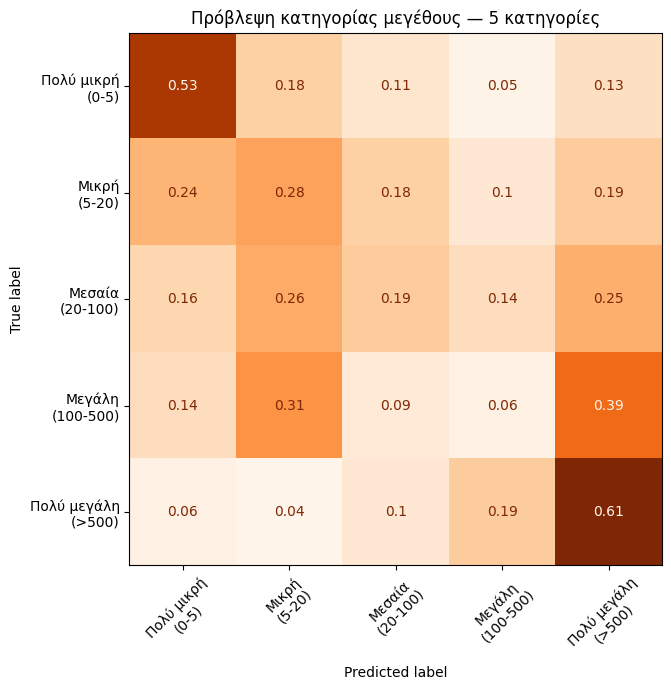

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

bins = [0, 5, 20, 100, 500, np.inf]
labels = ['Πολύ μικρή\n(0-5)', 'Μικρή\n(5-20)', 'Μεσαία\n(20-100)',
          'Μεγάλη\n(100-500)', 'Πολύ μεγάλη\n(>500)']

y_train_mc = pd.cut(np.expm1(y_train), bins=bins, labels=labels)
y_test_mc  = pd.cut(np.expm1(y_test),  bins=bins, labels=labels)

clf = HistGradientBoostingClassifier(max_iter=250, learning_rate=0.05, max_depth=6,
                                     class_weight='balanced', random_state=42)
clf.fit(X_train, y_train_mc)
pred = clf.predict(X_test)

idx = {l: i for i, l in enumerate(labels)}
ti = np.array([idx[x] for x in y_test_mc]); pi = np.array([idx[x] for x in pred])
print("5 κλάσεις")
print(f"Accuracy:          {accuracy_score(y_test_mc, pred):.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test_mc, pred):.3f}")
print(f"Macro-F1:          {f1_score(y_test_mc, pred, average='macro'):.3f}")
print(f"Εντός ±1 κλάσης:   {np.mean(np.abs(ti - pi) <= 1):.3f} ")

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(confusion_matrix(y_test_mc, pred, labels=labels, normalize='true').round(2),
                       display_labels=labels).plot(ax=ax, cmap='Oranges', colorbar=False, xticks_rotation=45)
ax.set_title('Πρόβλεψη κατηγορίας μεγέθους — 5 κατηγορίες')
plt.tight_layout()
plt.show()

ε κλάσεις (Gradient Boosting)
Accuracy:          0.547
Balanced accuracy: 0.523
Macro-F1:          0.381
Εντός ±1 κλάσης:   0.844  


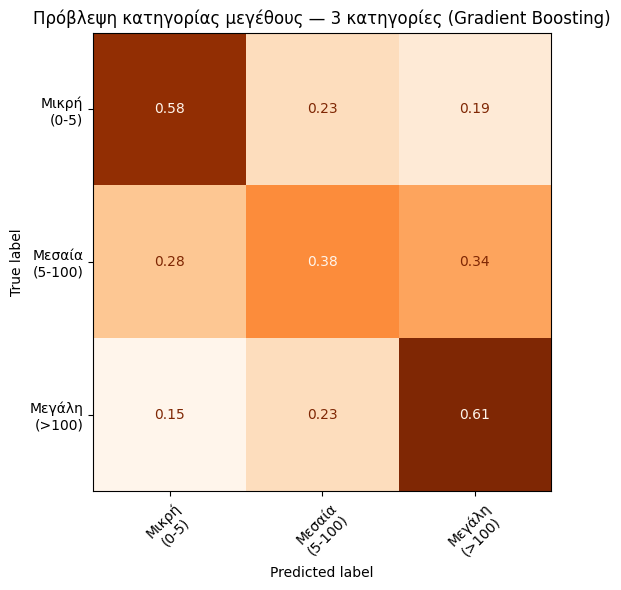

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

bins = [0, 5, 100, np.inf]
labels = ['Μικρή\n(0-5)', 'Μεσαία\n(5-100)', 'Μεγάλη\n(>100)']

y_train_mc = pd.cut(np.expm1(y_train), bins=bins, labels=labels)
y_test_mc  = pd.cut(np.expm1(y_test),  bins=bins, labels=labels)

clf = HistGradientBoostingClassifier(max_iter=250, learning_rate=0.05, max_depth=6,
                                     class_weight='balanced', random_state=42)
clf.fit(X_train, y_train_mc)
pred = clf.predict(X_test)

idx = {l: i for i, l in enumerate(labels)}
ti = np.array([idx[x] for x in y_test_mc]); pi = np.array([idx[x] for x in pred])
print("ε κλάσεις (Gradient Boosting)")
print(f"Accuracy:          {accuracy_score(y_test_mc, pred):.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test_mc, pred):.3f}")
print(f"Macro-F1:          {f1_score(y_test_mc, pred, average='macro'):.3f}")
print(f"Εντός ±1 κλάσης:   {np.mean(np.abs(ti - pi) <= 1):.3f}  ")

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test_mc, pred, labels=labels, normalize='true').round(2),
                       display_labels=labels).plot(ax=ax, cmap='Oranges', colorbar=False, xticks_rotation=45)
ax.set_title('Πρόβλεψη κατηγορίας μεγέθους — 3 κατηγορίες (Gradient Boosting)')
plt.tight_layout()
plt.show()

binary classification threshold 500

 ΑΝΙΧΝΕΥΤΗΣ ΚΑΤΑΣΤΡΟΦΙΚΩΝ ΦΩΤΙΩΝ (>500 στρ.) 
AUC:               0.881    κύριος δείκτης
Accuracy:          0.671   (παραπλανητική λόγω ανισορροπίας)
Balanced accuracy: 0.798
Recall (καταστρ.): 0.928    % καταστροφικών που πιάστηκαν
Precision:         0.026   (χαμηλό = ψευδείς συναγερμοί, αποδεκτό)
F1:                0.051


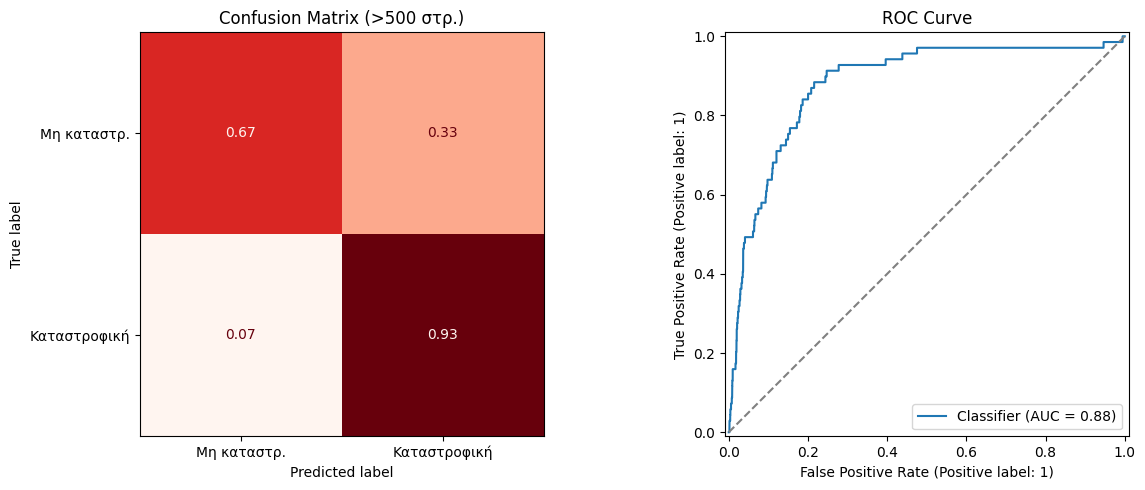

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, accuracy_score, balanced_accuracy_score,
                             recall_score, precision_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

THRESHOLD = 500
y_train_bin = (np.expm1(y_train) > THRESHOLD).astype(int)
y_test_bin  = (np.expm1(y_test)  > THRESHOLD).astype(int)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, y_train_bin)
pred  = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]

print(f" ΑΝΙΧΝΕΥΤΗΣ ΚΑΤΑΣΤΡΟΦΙΚΩΝ ΦΩΤΙΩΝ (>{THRESHOLD} στρ.) ")
print(f"AUC:               {roc_auc_score(y_test_bin, proba):.3f}    κύριος δείκτης")
print(f"Accuracy:          {accuracy_score(y_test_bin, pred):.3f}   (παραπλανητική λόγω ανισορροπίας)")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test_bin, pred):.3f}")
print(f"Recall (καταστρ.): {recall_score(y_test_bin, pred):.3f}    % καταστροφικών που πιάστηκαν")
print(f"Precision:         {precision_score(y_test_bin, pred):.3f}   (χαμηλό = ψευδείς συναγερμοί, αποδεκτό)")
print(f"F1:                {f1_score(y_test_bin, pred):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test_bin, pred, normalize='true').round(2),
                       display_labels=['Μη καταστρ.', 'Καταστροφική']).plot(ax=ax[0], cmap='Reds', colorbar=False)
ax[0].set_title(f'Confusion Matrix (>{THRESHOLD} στρ.)')
RocCurveDisplay.from_predictions(y_test_bin, proba, ax=ax[1])
ax[1].plot([0, 1], [0, 1], '--', color='gray')
ax[1].set_title('ROC Curve')
plt.tight_layout()
plt.show()

Overfitting regression